In [1]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
import re
import os
import time
from glob import glob
from tqdm import tqdm
from typing import Any

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Utility Functions

In [2]:
def load_pickle(filename:str) -> Any:
    '''Save the data in the pickle (pkl) format.'''
    with open(filename, 'rb') as handle:
        data = pkl.load(handle)
    return data

def save_pickle(filename: str, data: Any) -> None:
    '''Save the data in the pickle (pkl) format.'''
    with open(filename, 'wb') as handle:
        pkl.dump(data, handle, protocol=pkl.HIGHEST_PROTOCOL)

### Data Loading

In [3]:
def is_valid_date_folder(name):
    return name.isdigit() and len(name) == 8

def get_valid_day_folders(base_path):
    return sorted([f for f in os.listdir(base_path) if is_valid_date_folder(f)])

def load_and_clean_day_data(base_path, day):
    print(f"--- Loading {day} ---")
    day_path = os.path.join(base_path, day, 'chunks_parquet_levels')
    parquet_files = sorted(glob(os.path.join(day_path, '*.parquet')))

    if not parquet_files:
        print(f"[!] No parquet files found for {day}")
        return pd.DataFrame()

    start_time = time.time()
    dfs = [pd.read_parquet(f) for f in parquet_files]
    df_day = pd.concat(dfs, ignore_index=True)

    # Clean column names
    df_day.columns = [col.strip() for col in df_day.columns]

    # Parse 'time' to datetime
    df_day['time'] = pd.to_datetime(df_day['time'])

    # Add trading day as separate column
    df_day['date'] = pd.to_datetime(day)

    print(f"Loaded {len(df_day):,} rows for {day} in {time.time() - start_time:.2f}s")
    return df_day

def save_cleaned_day(base_path, output_path, day):
    df_day = load_and_clean_day_data(base_path, day)
    if not df_day.empty:
        df_day.to_parquet(os.path.join(output_path, f"{day}_cleaned.parquet"), index=False)
        print(f"Saved cleaned data for {day}")

In [4]:
base_path = '/mnt/user_disk/kfeghoul/storage_1_10T/Citibank/egbs_data_02_25'
valid_days = get_valid_day_folders(base_path)

In [5]:
valid_days

['20250212',
 '20250213',
 '20250214',
 '20250217',
 '20250218',
 '20250219',
 '20250220',
 '20250221',
 '20250224',
 '20250225']

In [6]:
days = valid_days[:1]

In [7]:
days

['20250212']

In [8]:
all_days_data = []

for day in tqdm(days):
    df = load_and_clean_day_data(base_path, day)
    if not df.empty:
        all_days_data.append(df)

  0%|          | 0/1 [00:00<?, ?it/s]

--- Loading 20250212 ---


100%|██████████| 1/1 [00:25<00:00, 25.66s/it]

Loaded 17,000,000 rows for 20250212 in 25.55s


In [9]:
# Concat all into one big DataFrame
df_all = pd.concat(all_days_data, ignore_index=True)
print(f"\nLoaded total of {len(df_all):,} rows across {len(valid_days)} days.")


Loaded total of 17,000,000 rows across 10 days.


In [10]:
# Save to a Parquet file
#df_all.to_parquet('data/egbs_full.parquet')

In [11]:
#df_all = pd.read_parquet('data/egbs_full.parquet')

In [12]:
df_all.head(10)

,time,sym,exch_time,exchange,first_sequence_number,last_sequence_number,first_sym_sequence,last_sym_sequence,first_time,first_exch_time,...,L9_ask_price,L9_ask_size,L9_ask_no,L10_bid_price,L10_bid_size,L10_bid_no,L10_ask_price,L10_ask_size,L10_ask_no,date
0,2025-02-12 00:15:01.019912585,FGBMH5,1739319301019908487,EUREX-EOBI,1,834,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
1,2025-02-12 00:15:01.019912585,FGBMM5,1739319301019908487,EUREX-EOBI,1,834,1,22,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-12
2,2025-02-12 00:15:01.019912585,FGBMU5,1739319301019908487,EUREX-EOBI,1,834,1,22,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-12
3,2025-02-12 00:15:01.019912585,FGBMH5,1739319301019908487,EUREX-EOBI,1,834,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
4,2025-02-12 00:15:01.019929684,FGBMM5,1739319301019926385,EUREX-EOBI,1,835,1,22,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-12
5,2025-02-12 00:15:01.019957460,FGBMH5,1739319301019954394,EUREX-EOBI,1,839,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
6,2025-02-12 00:15:01.019959576,FGBMH5,1739319301019956587,EUREX-EOBI,1,840,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
7,2025-02-12 00:15:01.019990496,FGBMH5,1739319301019987468,EUREX-EOBI,1,841,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
8,2025-02-12 00:15:01.020053461,FGBMH5,1739319301020050437,EUREX-EOBI,1,842,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12
9,2025-02-12 00:15:01.020062088,FGBMH5,1739319301020059117,EUREX-EOBI,1,843,1,22,0,0,...,117.61,908.0,19.0,117.43,903.0,18.0,117.62,973.0,18.0,2025-02-12


In [13]:
df_all.columns

Index(['time', 'sym', 'exch_time', 'exchange', 'first_sequence_number',
       'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
       'first_time', 'first_exch_time', 'event_id', 'L1_bid_price',
       'L1_bid_size', 'L1_bid_no', 'L1_ask_price', 'L1_ask_size', 'L1_ask_no',
       'L2_bid_price', 'L2_bid_size', 'L2_bid_no', 'L2_ask_price',
       'L2_ask_size', 'L2_ask_no', 'L3_bid_price', 'L3_bid_size', 'L3_bid_no',
       'L3_ask_price', 'L3_ask_size', 'L3_ask_no', 'L4_bid_price',
       'L4_bid_size', 'L4_bid_no', 'L4_ask_price', 'L4_ask_size', 'L4_ask_no',
       'L5_bid_price', 'L5_bid_size', 'L5_bid_no', 'L5_ask_price',
       'L5_ask_size', 'L5_ask_no', 'L6_bid_price', 'L6_bid_size', 'L6_bid_no',
       'L6_ask_price', 'L6_ask_size', 'L6_ask_no', 'L7_bid_price',
       'L7_bid_size', 'L7_bid_no', 'L7_ask_price', 'L7_ask_size', 'L7_ask_no',
       'L8_bid_price', 'L8_bid_size', 'L8_bid_no', 'L8_ask_price',
       'L8_ask_size', 'L8_ask_no', 'L9_bid_price', 'L9_b

### Data Cleaning

In [14]:
missing_rows = df_all.isnull().any(axis=1).sum()
total_rows = len(df_all)
print(f"Number of lines with at least one missing value: {missing_rows} on {total_rows} ({missing_rows / total_rows:.2%})")

Number of lines with at least one missing value: 5265 on 17000000 (0.03%)


In [15]:
df_clean = df_all.copy()
df_clean = df_clean.dropna()

missing_rows = df_clean.isnull().any(axis=1).sum()
total_rows = len(df_clean)
print(f"Number of lines with at least one missing value: {missing_rows} on {total_rows} ({missing_rows / total_rows:.2%})")

Number of lines with at least one missing value: 0 on 16994735 (0.00%)


### Calculate HFT Features

In [16]:
def compute_core_features(df):
    
    # Midprice
    df["mid_price"] = (df["L1_bid_price"] + df["L1_ask_price"]) / 2

    # Spread
    df["spread"] = df["L1_ask_price"] - df["L1_bid_price"]

    # Weighted MidPrice (WMP)
    df["weighted_mid_price"] = (df["L1_bid_price"] * df["L1_ask_size"] + df["L1_ask_price"] * df["L1_bid_size"]) / (
        df["L1_bid_size"] + df["L1_ask_size"]
    )

    # Order Book Imbalance (OBI) - niveau 1
    df["obi_L1"] = (df["L1_bid_size"] - df["L1_ask_size"]) / (df["L1_bid_size"] + df["L1_ask_size"])

    # Depth imbalance (L1 à L10)
    bid_cols = [f"L{i}_bid_size" for i in range(1, 11)]
    ask_cols = [f"L{i}_ask_size" for i in range(1, 11)]

    df["cum_bid_vol_10"] = df[bid_cols].sum(axis=1)
    df["cum_ask_vol_10"] = df[ask_cols].sum(axis=1)
    df["depth_imbalance_10"] = (df["cum_bid_vol_10"] - df["cum_ask_vol_10"]) / (
        df["cum_bid_vol_10"] + df["cum_ask_vol_10"]
    )

    # Liquidity metrics
    df["liquidity_impact_bid"] = df["L1_bid_price"] - df["L2_bid_price"]
    df["liquidity_impact_ask"] = df["L2_ask_price"] - df["L1_ask_price"]
    
    return df

In [17]:
df = compute_core_features(df_clean)

### Symbol Analysis

In [18]:
# Count the number of occurence of each symbol
sym_counts = df['sym'].value_counts()

In [19]:
sym_counts

sym
FGBLH5    4524324
FGBXH5    4146644
FGBMH5    2924122
FOATH5    2700417
FBTPH5    1624107
FGBSH5     643464
FBTSH5     384576
FBONH5      42905
FGBLM5       3937
CONFH5        239
Name: count, dtype: int64

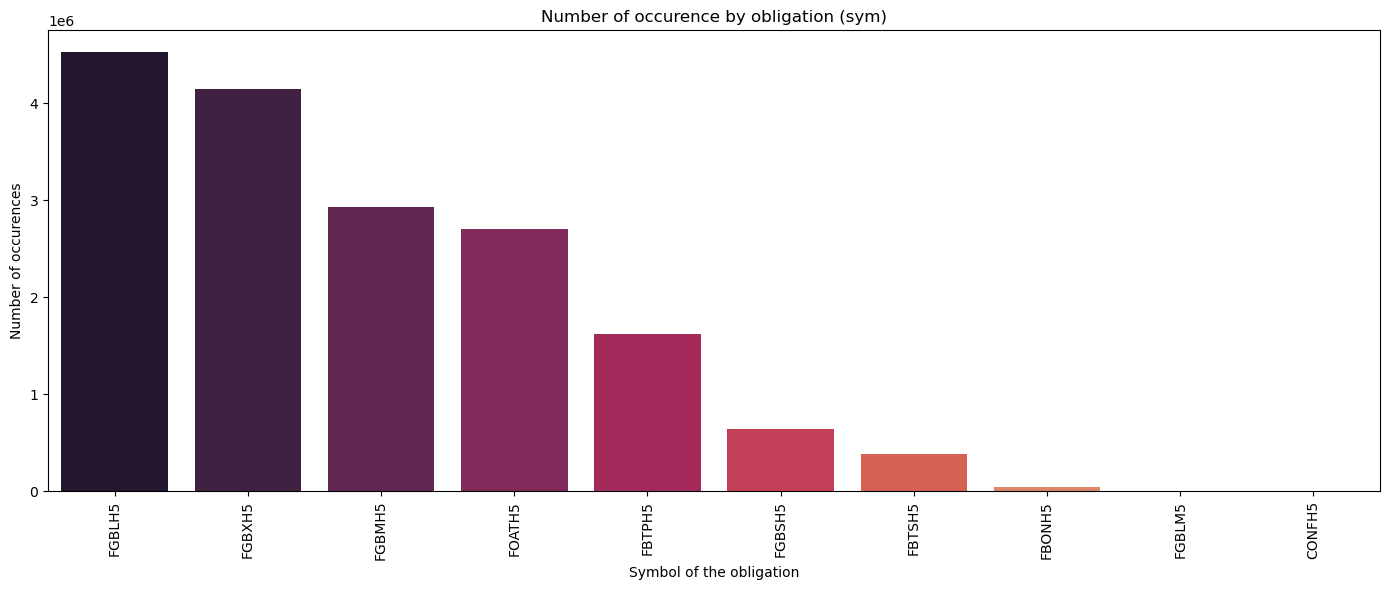

In [20]:
# Compter le nombre d'occurrences par symbole
sym_counts = df['sym'].value_counts().reset_index()
sym_counts.columns = ['sym', 'count']
sym_counts = sym_counts.sort_values('count', ascending=False)

palette = sns.color_palette("rocket", len(sym_counts))

plt.figure(figsize=(14, 6))
sns.barplot(
    data=sym_counts,
    x='sym',
    y='count',
    palette=palette,
    hue='sym',
    legend=False
)
plt.title("Number of occurence by obligation (sym)")
plt.xlabel("Symbol of the obligation")
plt.ylabel("Number of occurences")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
mask = (df['sym'] != 'FGBLM5') & (df['sym'] != 'CONFH5')
df = df.loc[mask]

In [22]:
# Regrouping by symbol
grouped = df.groupby('sym')

rows = []

for sym_name, group in grouped:
    group = group.sort_values('time')
    
    time_deltas = group['time'].diff().dropna()
    
    row = {
        'sym': sym_name,
        'min_time': group['time'].min(),
        'max_time': group['time'].max(),
        'num_quotes': len(group),
        'mean_freq_ms': time_deltas.mean().total_seconds() * 1000,
        'median_freq_ms': time_deltas.median().total_seconds() * 1000,
        'min_freq_ms': time_deltas.min().total_seconds() * 1000,
        'max_freq_ms': time_deltas.max().total_seconds() * 1000,
        'num_gaps_over_1s': (time_deltas > pd.Timedelta('1s')).sum()
    }
    
    rows.append(row)

stats_df = pd.DataFrame(rows)
stats_df.sort_values('num_quotes', ascending=False, inplace=True)


In [23]:
stats_df

,sym,min_time,max_time,num_quotes,mean_freq_ms,median_freq_ms,min_freq_ms,max_freq_ms,num_gaps_over_1s
3,FGBLH5,2025-02-12 00:16:36.973883263,2025-02-12 20:05:54.545141905,4524324,15.771,0.005,0.000,293378.170,12164
6,FGBXH5,2025-02-12 00:16:45.489831276,2025-02-12 20:05:49.111615665,4146644,17.205,0.005,0.000,332037.847,13672
4,FGBMH5,2025-02-12 00:15:01.019912585,2025-02-12 20:05:52.118625961,2924122,24.435,0.005,0.000,339230.142,14498
7,FOATH5,2025-02-12 00:15:01.084543637,2025-02-12 20:05:50.296152286,2700417,26.458,0.005,0.000,346115.643,11746
1,FBTPH5,2025-02-12 07:01:02.110689066,2025-02-12 18:00:00.220827028,1624107,24.344,0.008,0.000,310624.031,8061
5,FGBSH5,2025-02-12 00:15:01.020498603,2025-02-12 20:05:45.293423995,643464,111.030,0.020,0.000,269974.156,15921
2,FBTSH5,2025-02-12 07:01:02.078216455,2025-02-12 18:00:00.208176247,384576,102.809,0.034,0.000,330130.487,10574
0,FBONH5,2025-02-12 07:01:02.075108021,2025-02-12 18:00:00.009844735,42905,921.544,30.289,0.001,337148.683,7387


## Volume Analysis

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

from typing import *

sns.set(style="whitegrid")

In [25]:
# This creates a dictionary of DataFrames, where keys are symbols.
symbols_data_map = {sym: group.copy() for sym, group in df.groupby('sym')}

In [26]:
for key in symbols_data_map.keys():
    print(f"Shape of {key}: {symbols_data_map[key].shape}")


Shape of FBONH5: (42905, 81)
Shape of FBTPH5: (1624107, 81)
Shape of FBTSH5: (384576, 81)
Shape of FGBLH5: (4524324, 81)
Shape of FGBMH5: (2924122, 81)
Shape of FGBSH5: (643464, 81)
Shape of FGBXH5: (4146644, 81)
Shape of FOATH5: (2700417, 81)


In [27]:
example_symbol = 'FBTSH5' #'FGBLH5' 
df_symbol = df[df['sym'] == example_symbol].copy()
df_symbol = df_symbol.sort_values('time').reset_index(drop=True)

df_symbol['activity_volume'] = df_symbol['L1_bid_size'] + df_symbol['L1_ask_size']
df_symbol['activity_volume'] = df_symbol['activity_volume'].fillna(0)

df_symbol['activity_volume_ma'] = df_symbol['activity_volume'].rolling(window=10000).mean()


df_symbol['cumulative_activity_volume'] = df_symbol['activity_volume'].cumsum()

In [28]:
print(f"Shape of df_symbol_specific: {df_symbol.shape}")
total_proxy_volume = df_symbol['cumulative_activity_volume'].max()
print(f"Max cumulative activity volume: {total_proxy_volume:,.0f}")

nb_bar = 10000

bar_size = total_proxy_volume / nb_bar
print(f"Volume threshold: {bar_size:,.0f}")


Shape of df_symbol_specific: (384576, 84)
Max cumulative activity volume: 1,192,769,411
Volume threshold: 119,277


### Volume exchange across time

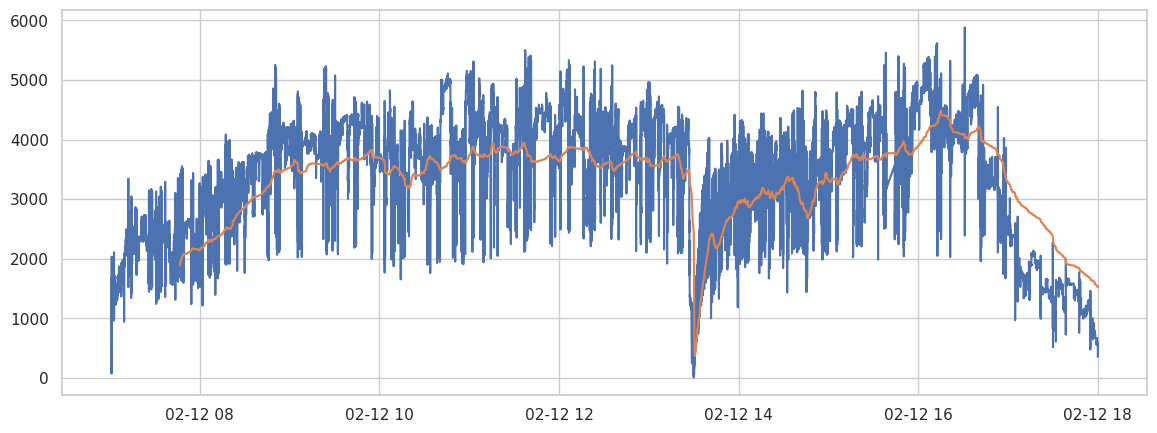

In [29]:
ax, fig = plt.subplots(figsize=(14, 5))
plt.plot(df_symbol['time'], df_symbol['activity_volume'])
plt.plot(df_symbol['time'], df_symbol['activity_volume_ma'])
plt.show()

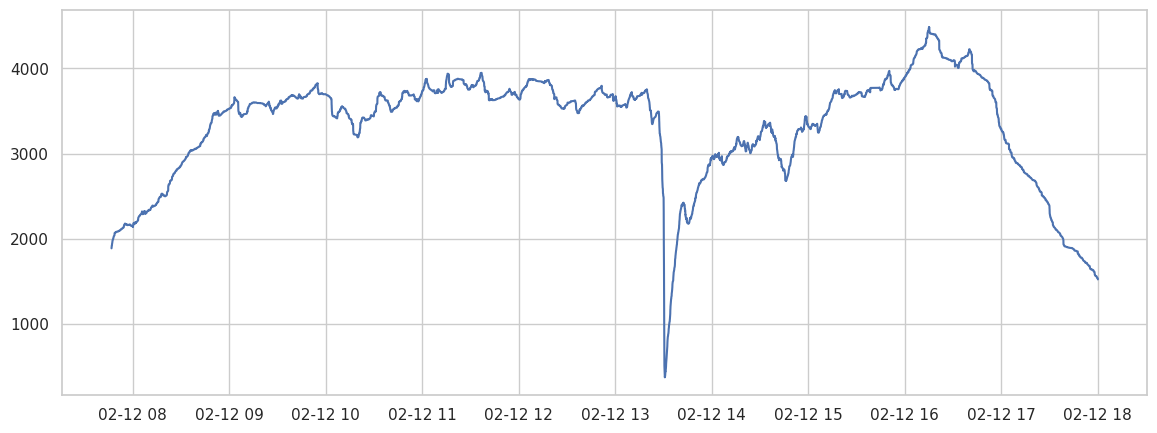

In [30]:
ax, fig = plt.subplots(figsize=(14, 5))
plt.plot(df_symbol['time'], df_symbol['activity_volume_ma'])
plt.show()

### Cumulative Volume exchange across time

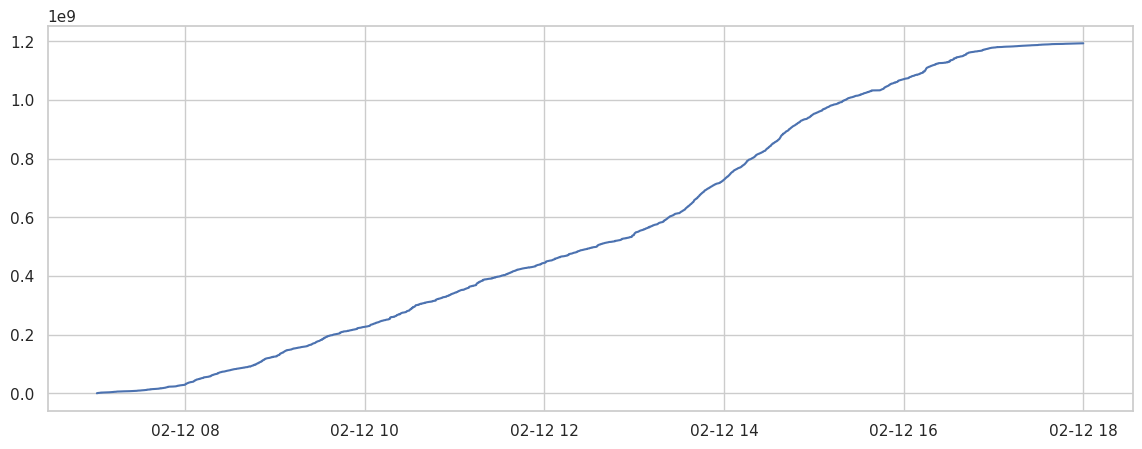

In [31]:
ax, fig = plt.subplots(figsize=(14, 5))
plt.plot(df_symbol['time'], df_symbol['cumulative_activity_volume'])
plt.show()

### Volume Delta

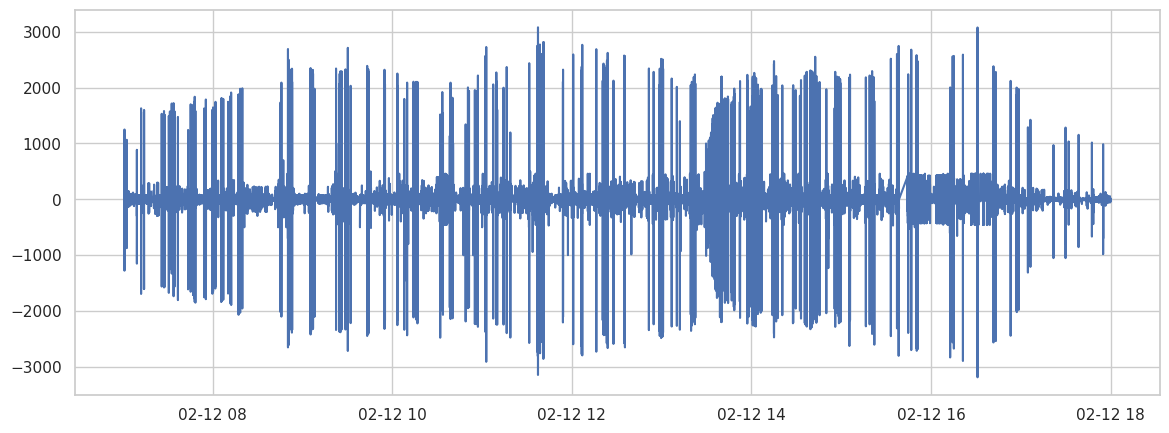

In [32]:
df_symbol['volume_delta'] = df_symbol['activity_volume'].diff()

ax, fig = plt.subplots(figsize=(14, 5))
plt.plot(df_symbol['time'], df_symbol['volume_delta'])
plt.show()

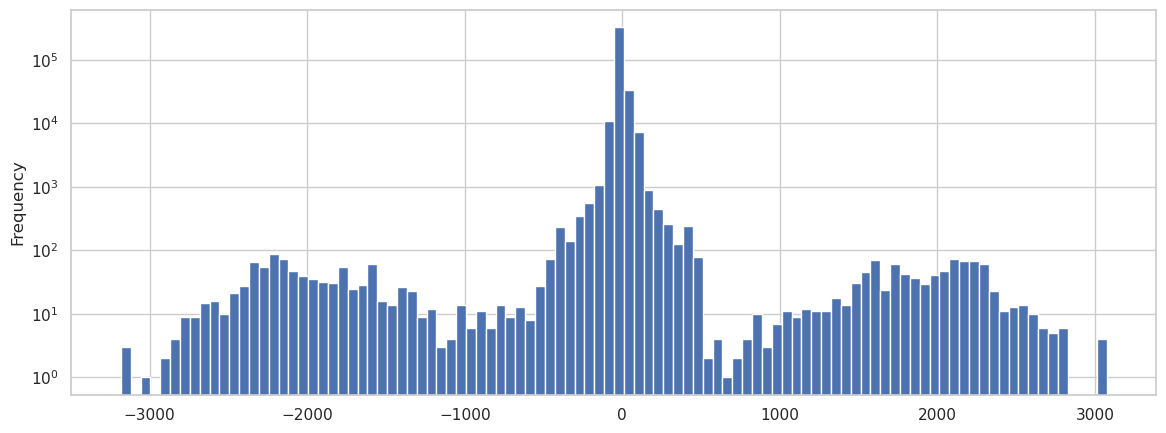

In [33]:
ax, fig = plt.subplots(figsize=(14, 5))
df_symbol['volume_delta'].plot(kind='hist', bins=100, logy=True)
plt.show()

In [34]:
def create_volume_bars(
    symbol_df_with_activity: pd.DataFrame,
    nb_bars: int,
    activity_col_name: str = 'activity_volume',
    wmp_col_name: str = 'weighted_mid_price',
    time_col_name: str = 'time'
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generates volume bars and also returns full snapshot data with bar_id assignment.

    Args:
        symbol_df_with_activity (pd.DataFrame): DataFrame for a single symbol with activity.
        volume_threshold (float): Volume threshold to define each bar.
        activity_col_name (str): Column holding volume/activity per snapshot.
        wmp_col_name (str): Column with weighted mid-price.
        time_col_name (str): Datetime column for time ordering.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]:
            - volume_bars_df: Aggregated stats per volume bar.
            - snapshots_with_bars: Original snapshot data with assigned bar_id.
    """
    if symbol_df_with_activity.empty or not nb_bars > 0:
        return pd.DataFrame(), pd.DataFrame()

    required_cols = [time_col_name, wmp_col_name, activity_col_name]
    if not all(col in symbol_df_with_activity.columns for col in required_cols):
        print(f"Missing required columns: {required_cols}")
        return pd.DataFrame(), pd.DataFrame()

    # Ensure sorted by time
    data = symbol_df_with_activity.sort_values(time_col_name).reset_index(drop=True)

    volume_threshold = data['cumulative_activity_volume'].max() // nb_bars
    print(f"Volume threshold: {volume_threshold}")
    
    data['bar_id'] = (data['cumulative_activity_volume'] // volume_threshold).astype(int)

    # Handle edge case: very first bar under threshold
    if data.loc[0, 'cumulative_activity_volume'] < volume_threshold:
        data.loc[data['bar_id'] == data.loc[0, 'bar_id'], 'bar_id'] = 0

    # Exclude partial last bar
    max_possible_bar_id = int(data['cumulative_activity_volume'].max() // volume_threshold) - 1
    if max_possible_bar_id < 0:
        return pd.DataFrame(), pd.DataFrame()

    data_full_bars = data[data['bar_id'] <= max_possible_bar_id].copy()

    if data_full_bars.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Aggregate bar-level statistics
    def aggregate_bar(bar_group):
        return pd.Series({
            'bar_start_time': bar_group[time_col_name].iloc[0],
            'bar_end_time': bar_group[time_col_name].iloc[-1],
            'num_snapshots_in_bar': len(bar_group),
            'actual_volume_in_bar': bar_group[activity_col_name].sum(),
            'mean_wmp': bar_group[wmp_col_name].mean(),
            'first_wmp': bar_group[wmp_col_name].iloc[0],
            'last_wmp': bar_group[wmp_col_name].iloc[-1],
            'min_wmp': bar_group[wmp_col_name].min(),
            'max_wmp': bar_group[wmp_col_name].max()
        })

    volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)
    volume_bars_df['bar_duration_seconds'] = (
        volume_bars_df['bar_end_time'] - volume_bars_df['bar_start_time']
    ).dt.total_seconds()

    # Final cleanup and return
    return volume_bars_df.reset_index(), data_full_bars.reset_index(drop=True)

In [35]:
bars_df, snapshots_with_bars = create_volume_bars(
    df_symbol,
    nb_bars=nb_bar,
    activity_col_name='activity_volume',
    wmp_col_name='weighted_mid_price',
    time_col_name='time'
)

Volume threshold: 119276.0


/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


In [36]:
bars_df

,bar_id,bar_start_time,bar_end_time,num_snapshots_in_bar,actual_volume_in_bar,mean_wmp,first_wmp,last_wmp,min_wmp,max_wmp,bar_duration_seconds
0,0,2025-02-12 07:01:02.078216455,2025-02-12 07:01:02.078855648,116,118803.0,107.428918,107.432080,107.421074,107.421074,107.432080,0.000639
1,1,2025-02-12 07:01:02.078860335,2025-02-12 07:01:03.094139158,180,119028.0,107.427405,107.421074,107.427388,107.421046,107.430148,1.015279
2,2,2025-02-12 07:01:03.094143599,2025-02-12 07:01:06.000346824,226,119657.0,107.429232,107.427388,107.429246,107.427388,107.429617,2.906203
3,3,2025-02-12 07:01:06.000351049,2025-02-12 07:01:10.813024125,203,119028.0,107.429134,107.429246,107.425886,107.425465,107.430177,4.812673
4,4,2025-02-12 07:01:10.813062325,2025-02-12 07:01:32.031397186,119,119501.0,107.431342,107.426414,107.433646,107.425971,107.433721,21.218335
...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2025-02-12 17:55:05.505515113,2025-02-12 17:56:34.756681874,139,119529.0,107.393992,107.393484,107.393333,107.393024,107.395154,89.251167
9996,9996,2025-02-12 17:56:34.756686098,2025-02-12 17:57:41.776121780,137,119148.0,107.395221,107.393333,107.396848,107.393186,107.396848,67.019436
9997,9997,2025-02-12 17:57:41.776127606,2025-02-12 17:58:00.177969053,160,119370.0,107.395888,107.396848,107.396025,107.395358,107.396848,18.401841
9998,9998,2025-02-12 17:58:00.240106061,2025-02-12 17:59:00.000371858,171,119620.0,107.396067,107.396025,107.395993,107.395736,107.396358,59.760266


### Bar Duration

In [37]:
bars_df['bar_duration_seconds'].describe()

count    10000.000000
mean         3.849051
std          7.493919
min          0.000094
25%          0.242845
50%          1.639684
75%          4.606609
max        330.724256
Name: bar_duration_seconds, dtype: float64

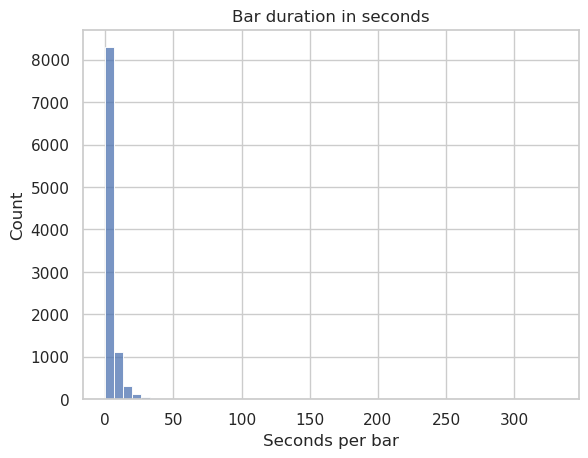

In [38]:
sns.histplot(data=bars_df, x='bar_duration_seconds', bins=50, kde=False)
plt.title("Bar duration in seconds")
plt.xlabel("Seconds per bar")
plt.ylabel("Count")
plt.show()

<Axes: title={'center': 'Bar Duration Over Time'}, xlabel='bar_id'>

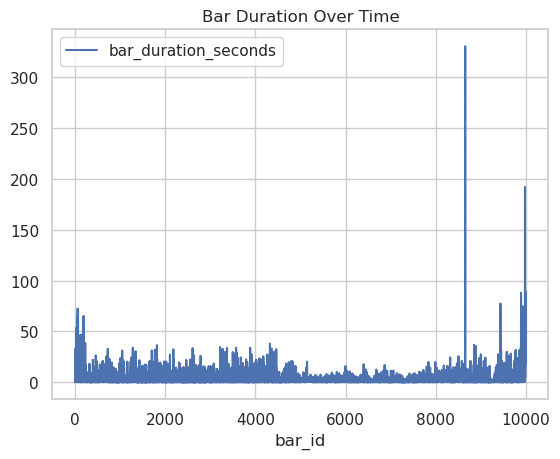

In [39]:
bars_df[['bar_id', 'bar_duration_seconds']].plot(x='bar_id', y='bar_duration_seconds', kind='line', title='Bar Duration Over Time')

### Number Snapshots in Bar

In [40]:
bars_df['num_snapshots_in_bar'].describe()

count    10000.00000
mean        38.45520
std         27.02688
min         22.00000
25%         30.00000
50%         34.00000
75%         42.00000
max       1611.00000
Name: num_snapshots_in_bar, dtype: float64

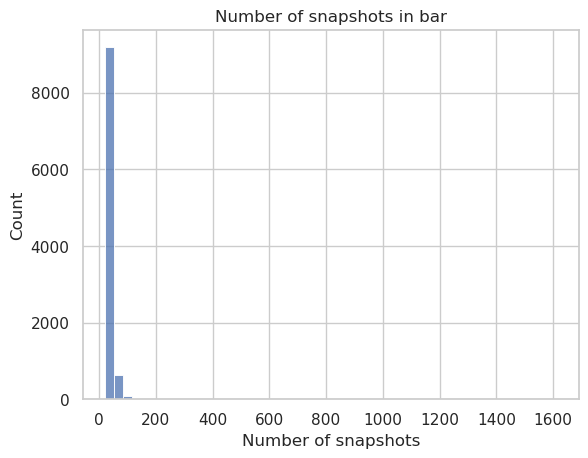

In [41]:
sns.histplot(data=bars_df, x='num_snapshots_in_bar', bins=50, kde=False)
plt.title("Number of snapshots in bar")
plt.xlabel("Number of snapshots")
plt.ylabel("Count")
plt.show()

### WMP Mean

In [42]:
bars_df['mean_wmp'].describe()

count    10000.000000
mean       107.385685
std          0.030275
min        107.314908
25%        107.361787
50%        107.376480
75%        107.414793
max        107.455045
Name: mean_wmp, dtype: float64

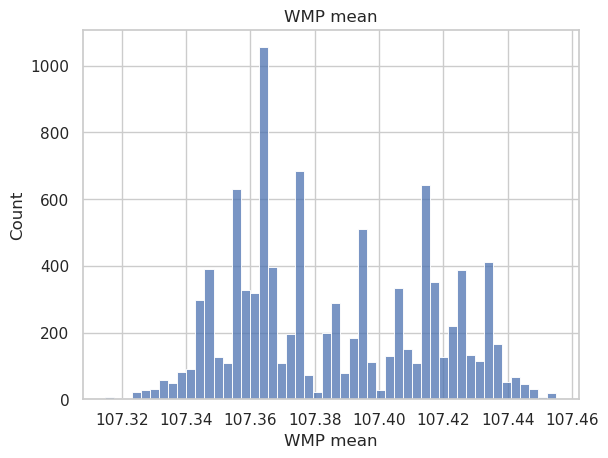

In [43]:
sns.histplot(data=bars_df, x='mean_wmp', bins=50, kde=False)
plt.title("WMP mean")
plt.xlabel("WMP mean")
plt.ylabel("Count")
plt.show()

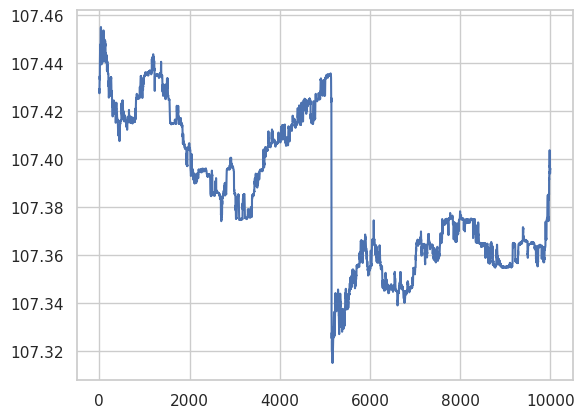

In [44]:
plt.plot(bars_df['bar_id'], bars_df['mean_wmp'])
plt.show()


### WMP return

In [45]:
bars_df['wmp_return'] = bars_df['last_wmp'] - bars_df['first_wmp']

In [46]:
bars_df['wmp_return'].describe()

count    10000.000000
mean        -0.000003
std          0.001178
min         -0.067728
25%         -0.000144
50%          0.000000
75%          0.000151
max          0.015321
Name: wmp_return, dtype: float64

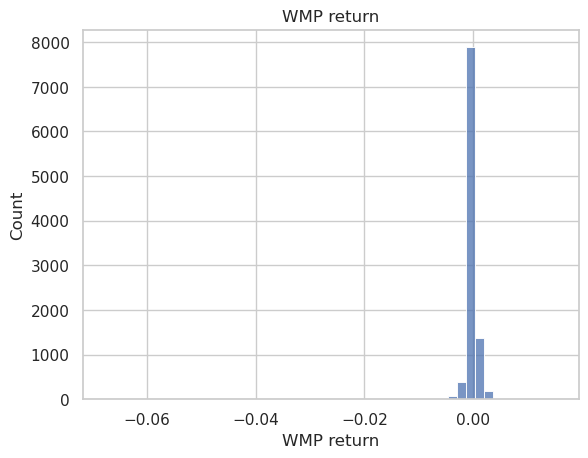

In [47]:
sns.histplot(data=bars_df, x='wmp_return', bins=50, kde=False)
plt.title("WMP return")
plt.xlabel("WMP return")
plt.ylabel("Count")
plt.show()

<Axes: title={'center': 'Smoothed WMP Return Over Bars'}>

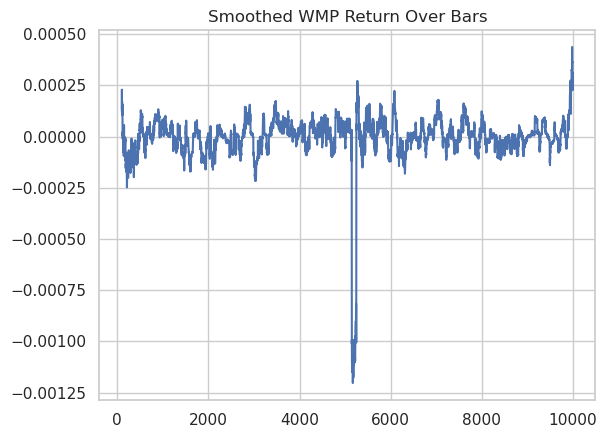

In [48]:
bars_df['wmp_return'].rolling(100).mean().plot(title="Smoothed WMP Return Over Bars")

In [49]:
max_nb_bars = 7500
min_avg_snapshots_per_bar = 150
nb_bars_by_symbol = {}

for key in symbols_data_map.keys():
    #print(f"Shape of {key}: {symbols_data_map[key].shape}")

    nb_snapshots = symbols_data_map[key].shape[0]
    nb_bars_for_quality = nb_snapshots // min_avg_snapshots_per_bar
    final_nb_bars = min(nb_bars_for_quality, max_nb_bars)
    nb_bars_by_symbol[key] = final_nb_bars
    print(f"Number of snapshots for {key}: {nb_snapshots}")
    print(f"Number of bars for {key}: {final_nb_bars}")

Number of snapshots for FBONH5: 42905
Number of bars for FBONH5: 286
Number of snapshots for FBTPH5: 1624107
Number of bars for FBTPH5: 7500
Number of snapshots for FBTSH5: 384576
Number of bars for FBTSH5: 2563
Number of snapshots for FGBLH5: 4524324
Number of bars for FGBLH5: 7500
Number of snapshots for FGBMH5: 2924122
Number of bars for FGBMH5: 7500
Number of snapshots for FGBSH5: 643464
Number of bars for FGBSH5: 4289
Number of snapshots for FGBXH5: 4146644
Number of bars for FGBXH5: 7500
Number of snapshots for FOATH5: 2700417
Number of bars for FOATH5: 7500


In [50]:
df.shape

(16990559, 81)

In [51]:
def process_symbol_data(df_symbol: pd.DataFrame, window_size: int = 10000) -> pd.DataFrame:
    """
    Processes the DataFrame for a single symbol to create activity volume features.

    Args:
        df_symbol (pd.DataFrame): DataFrame for a single symbol.
        window_size (int): The window size for the moving average of activity volume.

    Returns:
        pd.DataFrame: The modified DataFrame with new features added.
    """
    # Sort and reset index
    df_symbol = df_symbol.sort_values('time').reset_index(drop=True)
    
    # Create activity volume column
    df_symbol['activity_volume'] = df_symbol['L1_bid_size'] + df_symbol['L1_ask_size']
    df_symbol['activity_volume'] = df_symbol['activity_volume'].fillna(0)
    
    # Create moving average of activity volume
    df_symbol['activity_volume_ma'] = df_symbol['activity_volume'].rolling(window=window_size).mean()
    
    # Create cumulative activity volume
    df_symbol['cumulative_activity_volume'] = df_symbol['activity_volume'].cumsum()
    
    # Create volume delta column
    df_symbol['volume_delta'] = df_symbol['activity_volume'].diff()

    return df_symbol

In [52]:
symbols_data_map = {}

for sym, df_symbol in df.groupby('sym'):
    processed_df = process_symbol_data(df_symbol)
    symbols_data_map[sym] = processed_df
    print(f"Shape of {sym}: {processed_df.shape}")

Shape of FBONH5: (42905, 85)
Shape of FBTPH5: (1624107, 85)
Shape of FBTSH5: (384576, 85)
Shape of FGBLH5: (4524324, 85)
Shape of FGBMH5: (2924122, 85)
Shape of FGBSH5: (643464, 85)
Shape of FGBXH5: (4146644, 85)
Shape of FOATH5: (2700417, 85)


In [53]:
cumulative_volume_data = []

for sym in symbols_data_map.keys():
    cum_vol = int(symbols_data_map[sym]['cumulative_activity_volume'].max())
    avg_vol_per_snapshots = cum_vol / symbols_data_map[sym].shape[0]
    cumulative_volume_data.append((sym, cum_vol, avg_vol_per_snapshots)) 

In [54]:
#cumulative_volume_data.sort(key=lambda x: x[1], reverse=True)

/tmp/ipykernel_2294323/3609977525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Cumulative_Volume', x='Symbol', data=df_cumulative_volume, palette='viridis')


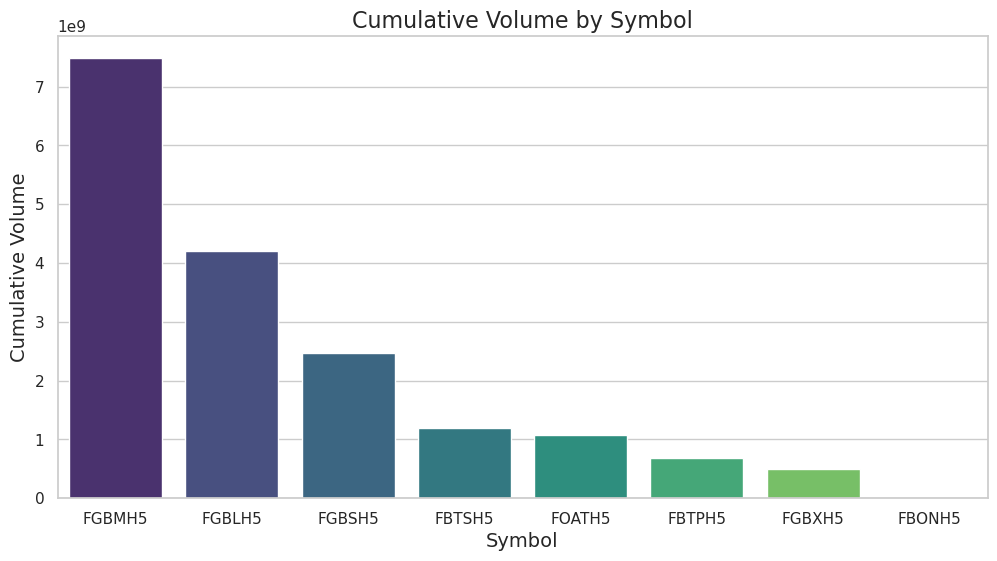

In [55]:
df_cumulative_volume = pd.DataFrame(cumulative_volume_data, columns=['Symbol', 'Cumulative_Volume', 'Avg_Volume_per_Snapshot'])

# Set the order of the bars based on cumulative volume
df_cumulative_volume = df_cumulative_volume.sort_values('Cumulative_Volume', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(y='Cumulative_Volume', x='Symbol', data=df_cumulative_volume, palette='viridis')

# Set title and labels
plt.title('Cumulative Volume by Symbol', fontsize=16)
plt.ylabel('Cumulative Volume', fontsize=14)
plt.xlabel('Symbol', fontsize=14)

# Show the plot
plt.show()

/tmp/ipykernel_2294323/182838994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Avg_Volume_per_Snapshot', x='Symbol', data=df_cumulative_volume, palette='viridis')


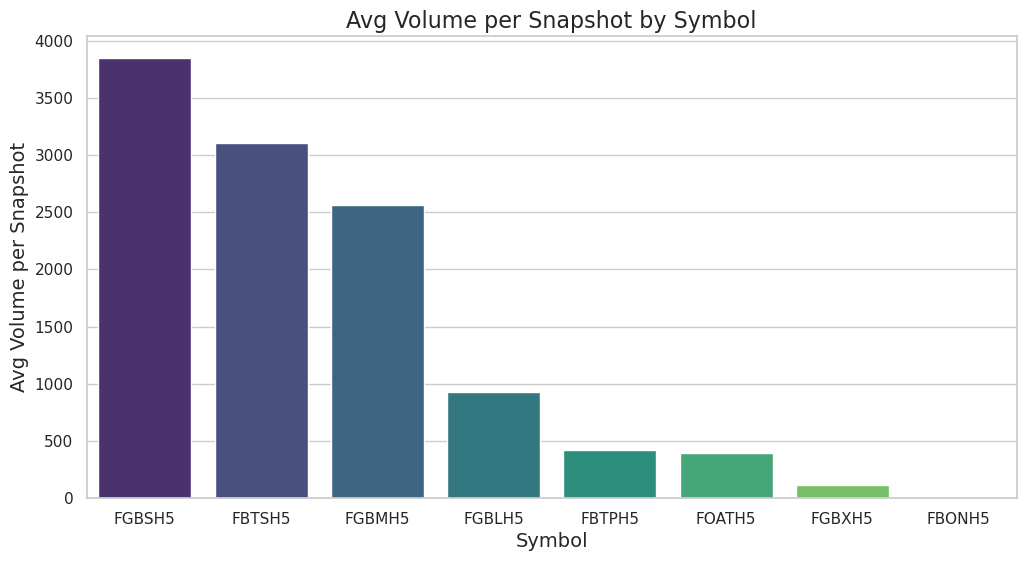

In [56]:
# Set the order of the bars based on cumulative volume
df_cumulative_volume = df_cumulative_volume.sort_values('Avg_Volume_per_Snapshot', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(y='Avg_Volume_per_Snapshot', x='Symbol', data=df_cumulative_volume, palette='viridis')

# Set title and labels
plt.title('Avg Volume per Snapshot by Symbol', fontsize=16)
plt.ylabel('Avg Volume per Snapshot', fontsize=14)
plt.xlabel('Symbol', fontsize=14)

# Show the plot
plt.show()

### Volume across time

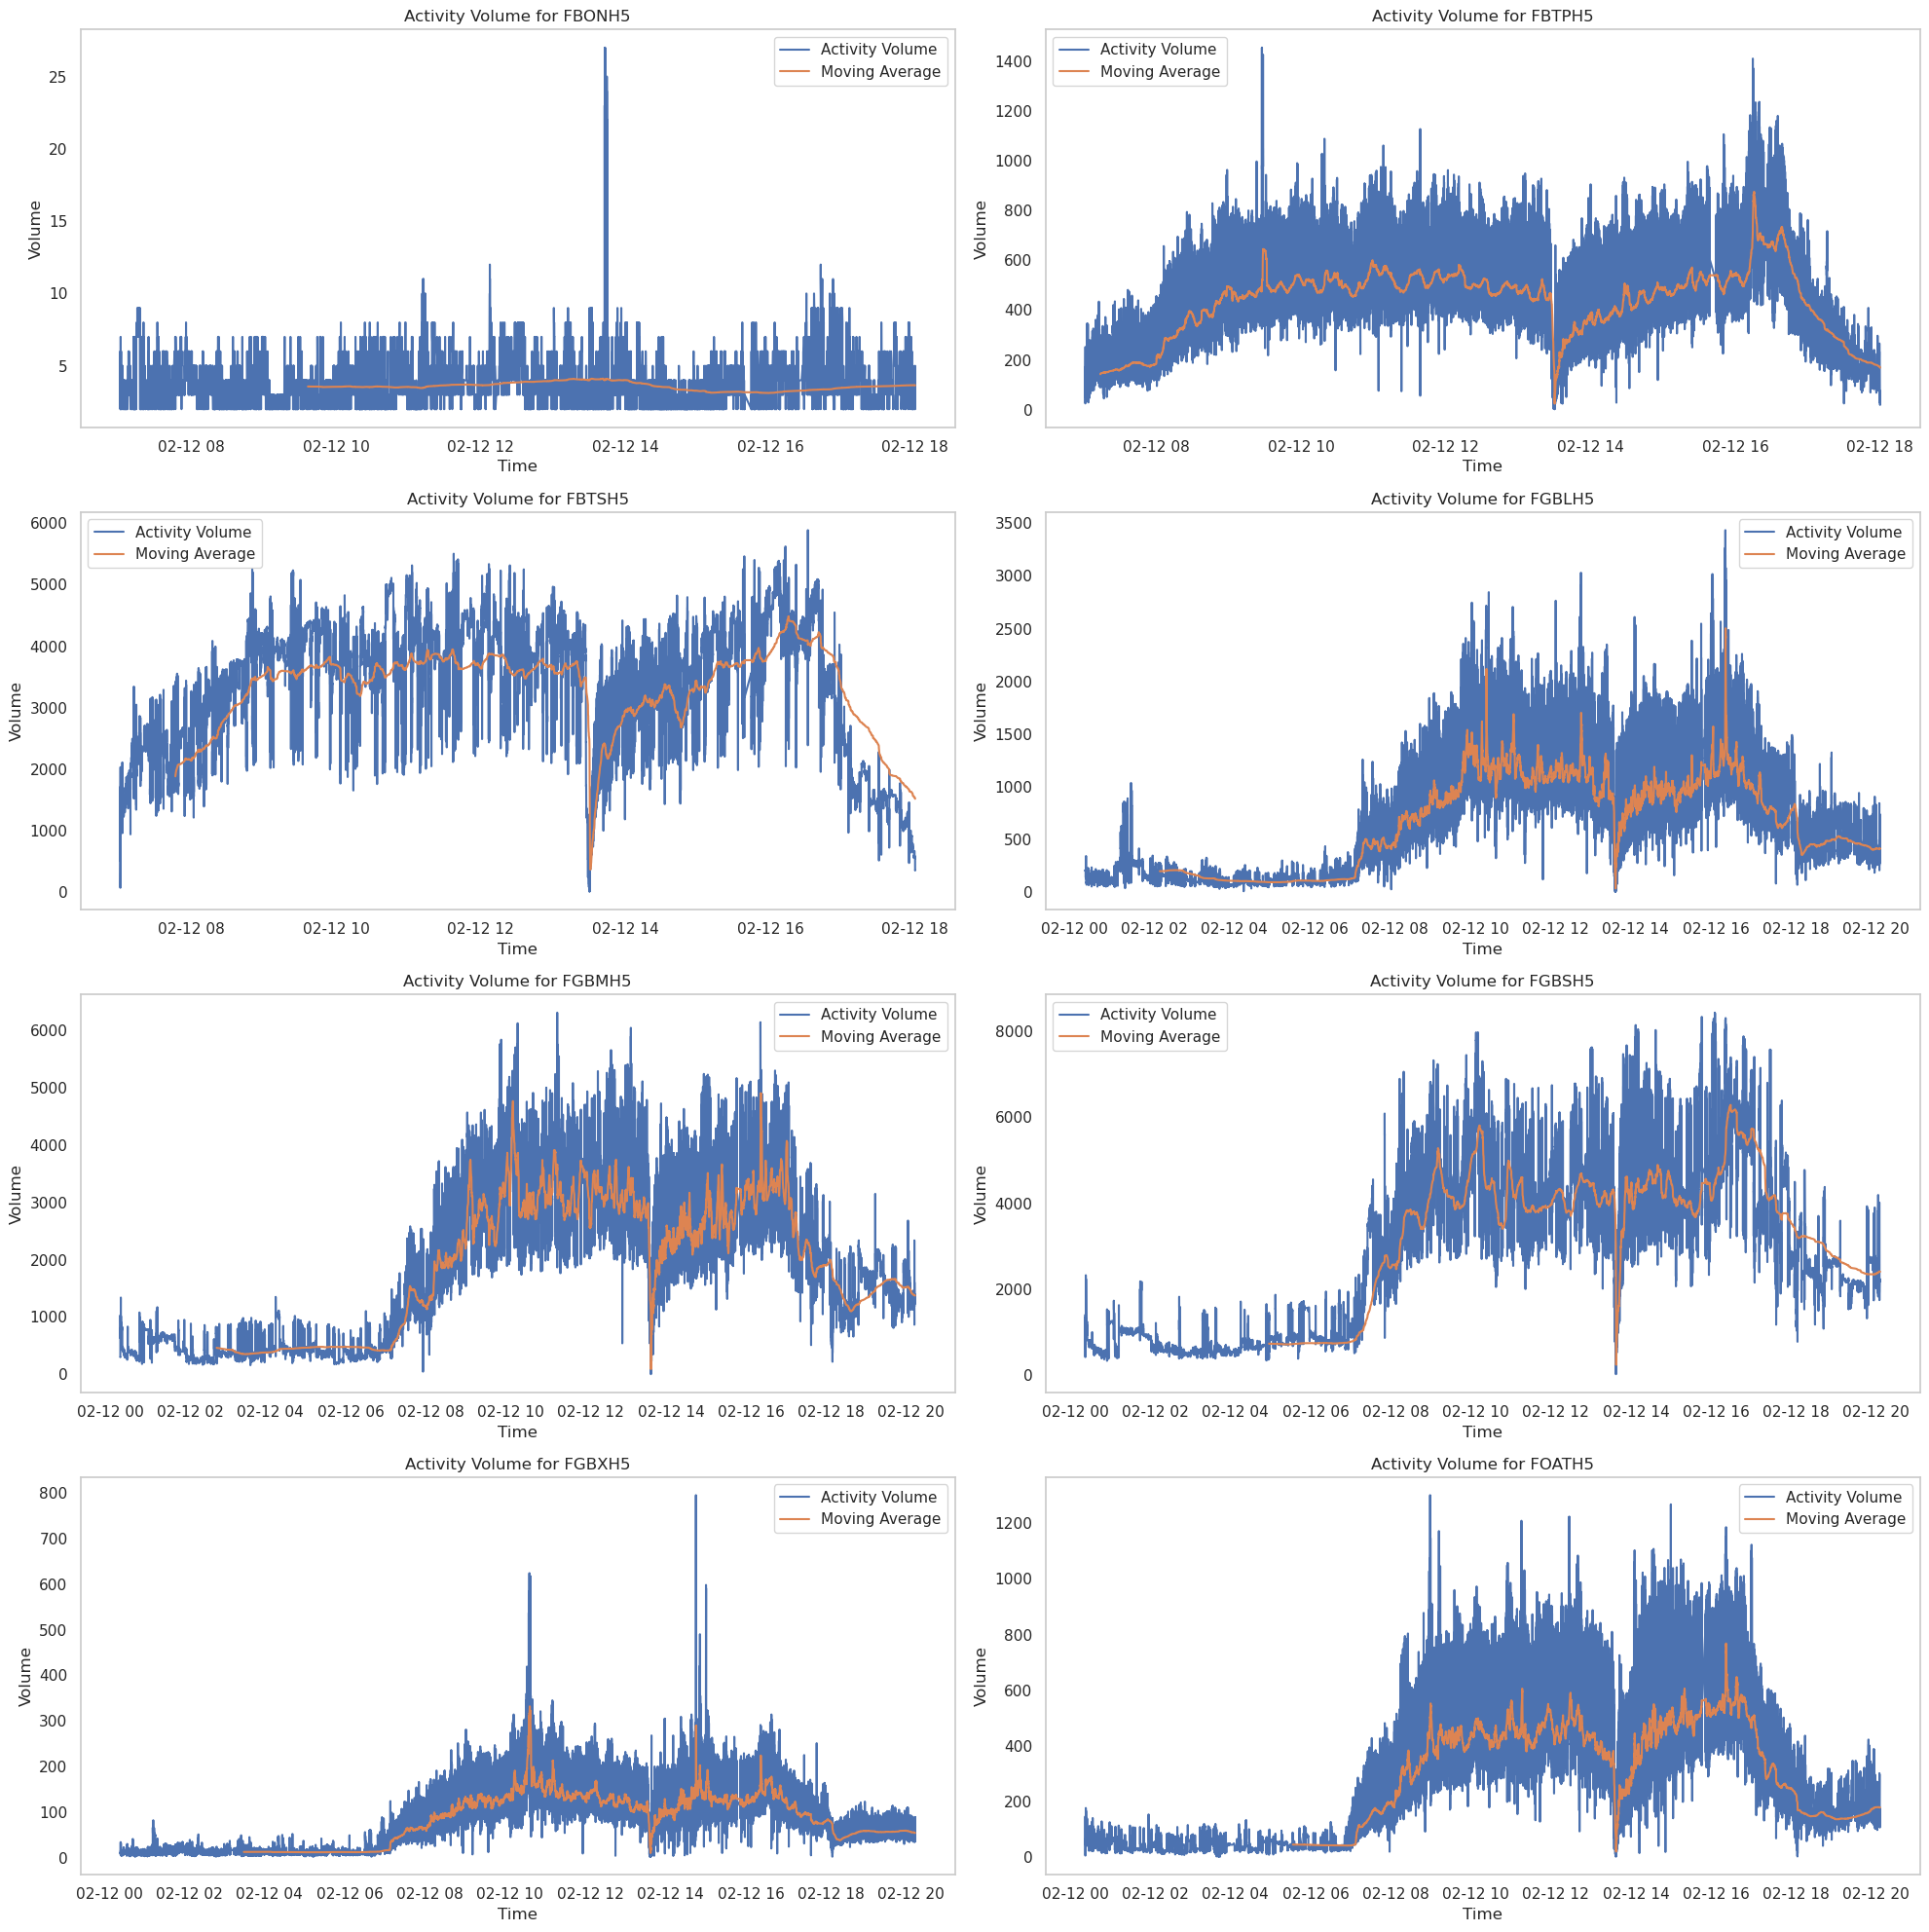

In [57]:
symbols = list(symbols_data_map.keys())
num_symbols = len(symbols)

# Determine the number of rows needed (2 symbols per row)
num_rows = (num_symbols + 1) // 2  # This ensures we round up for odd numbers

# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Iterate over symbols and plot
for i, sym in enumerate(symbols):
    df_symbol = symbols_data_map[sym]
    
    # Plot activity volume and moving average
    axes[i].plot(df_symbol['time'], df_symbol['activity_volume'], label='Activity Volume')
    axes[i].plot(df_symbol['time'], df_symbol['activity_volume_ma'], label='Moving Average')
    
    # Set title and labels
    axes[i].set_title(f'Activity Volume for {sym}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Volume')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

### Volume Delta

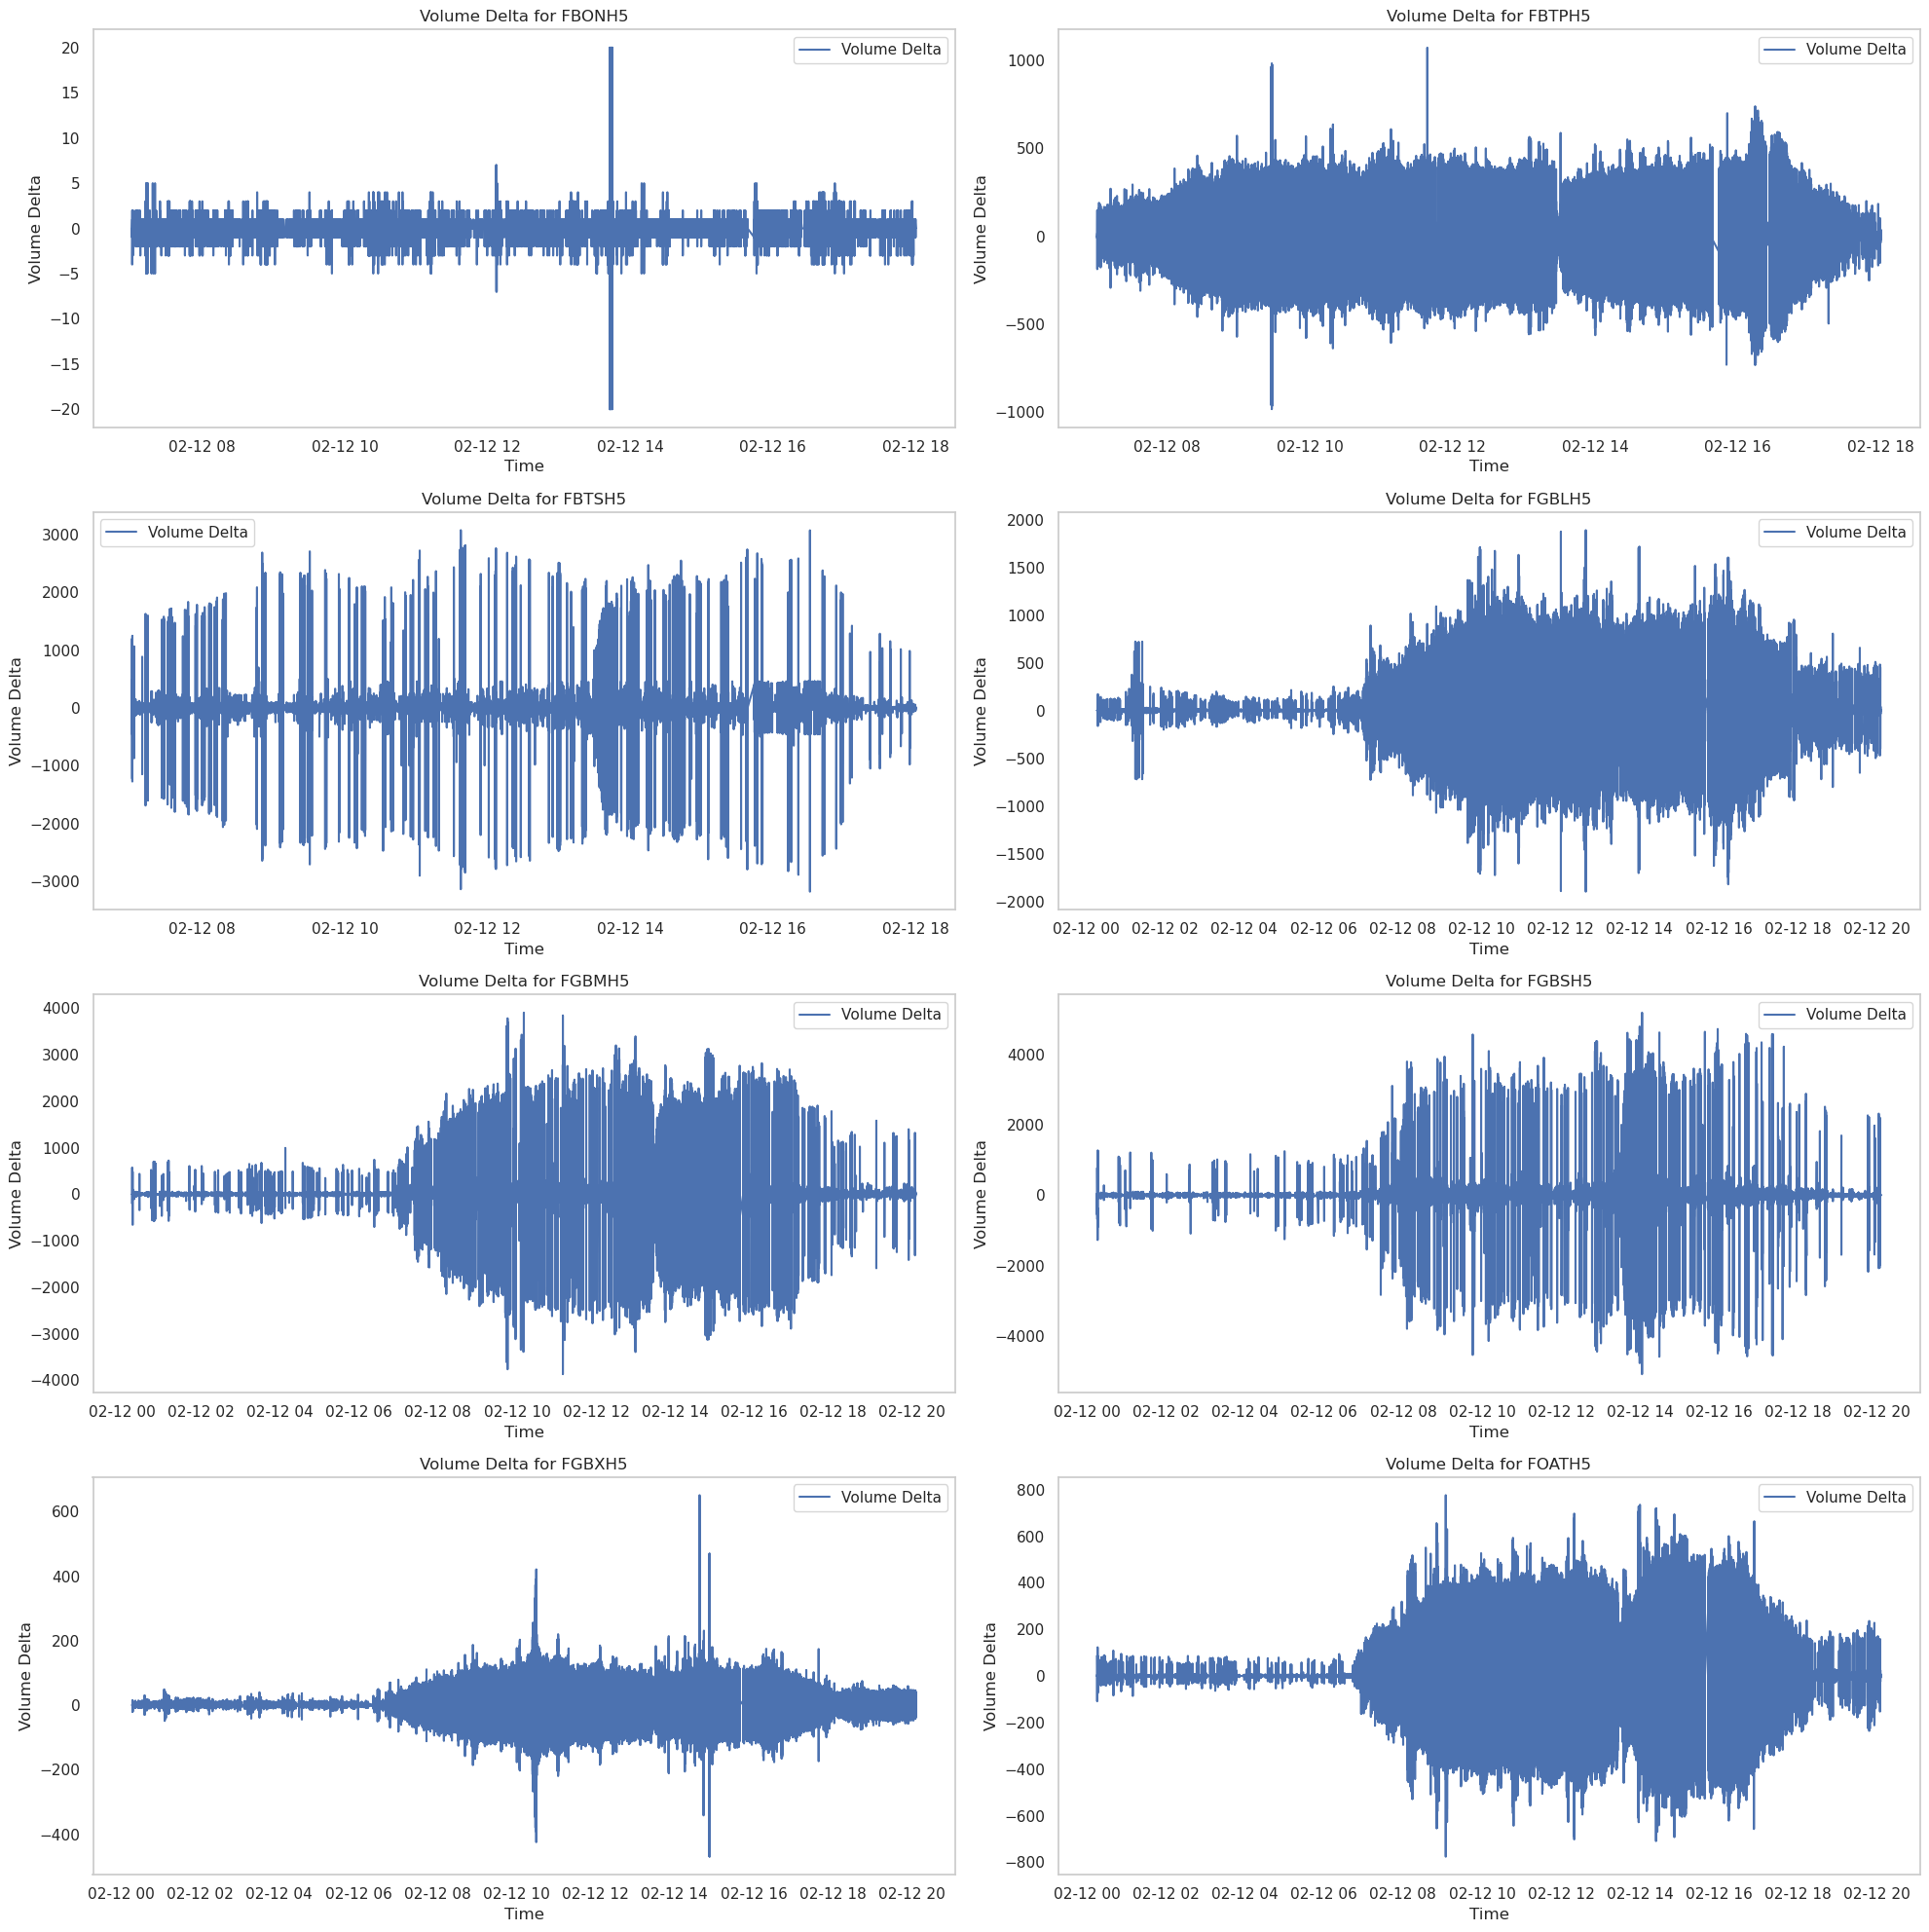

In [58]:
symbols = list(symbols_data_map.keys())
num_symbols = len(symbols)

# Determine the number of rows needed (2 symbols per row)
num_rows = (num_symbols + 1) // 2  # This ensures we round up for odd numbers

# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Iterate over symbols and plot
for i, sym in enumerate(symbols):
    df_symbol = symbols_data_map[sym]

    axes[i].plot(df_symbol['time'], df_symbol['volume_delta'], label='Volume Delta')
    
    # Set title and labels
    axes[i].set_title(f'Volume Delta for {sym}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Volume Delta')
    axes[i].legend()
    axes[i].grid()

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

### Volatility of Volume Changes

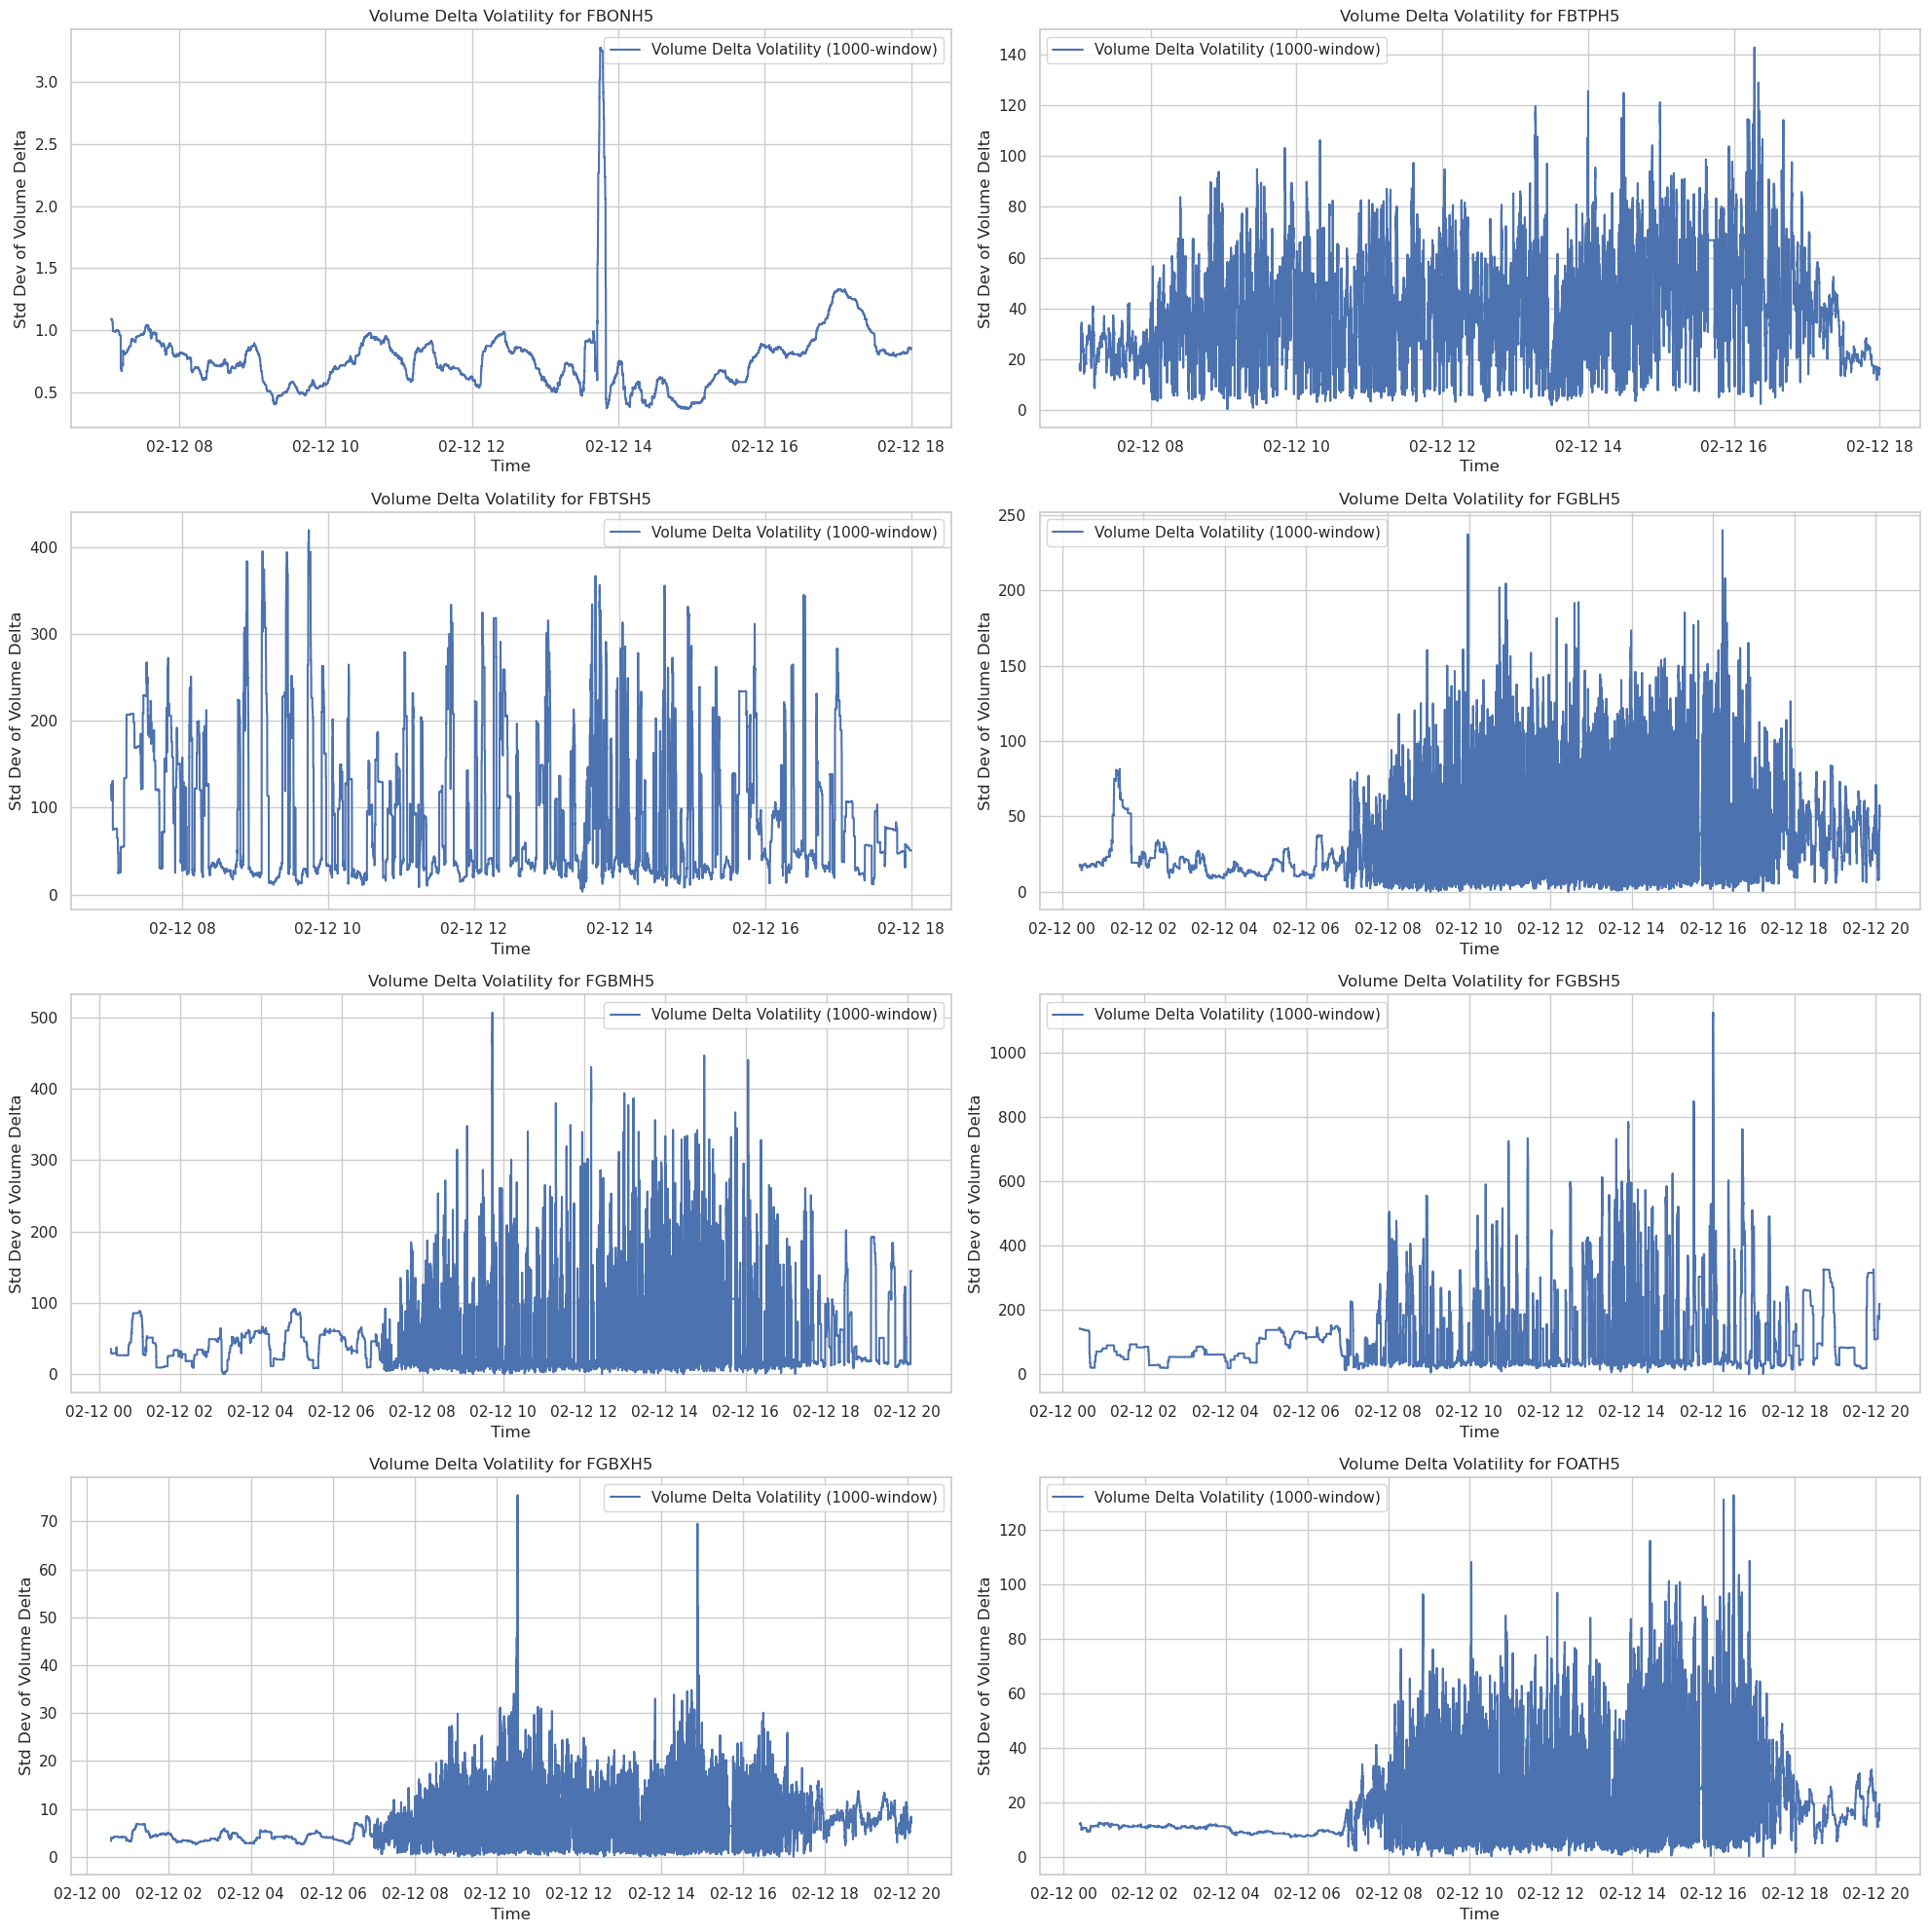

In [59]:
symbols = list(symbols_data_map.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, sym in enumerate(symbols):
    df_symbol = symbols_data_map[sym].copy() # Use .copy() to avoid SettingWithCopyWarning
    
    # Calculate rolling std of volume_delta with a 1000-snapshot window
    df_symbol['volume_delta_vol'] = df_symbol['volume_delta'].rolling(window=1000).std()

    axes[i].plot(df_symbol['time'], df_symbol['volume_delta_vol'], label='Volume Delta Volatility (1000-window)')
    
    axes[i].set_title(f'Volume Delta Volatility for {sym}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Std Dev of Volume Delta')
    axes[i].legend()
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Distribution of Raw activity_volume

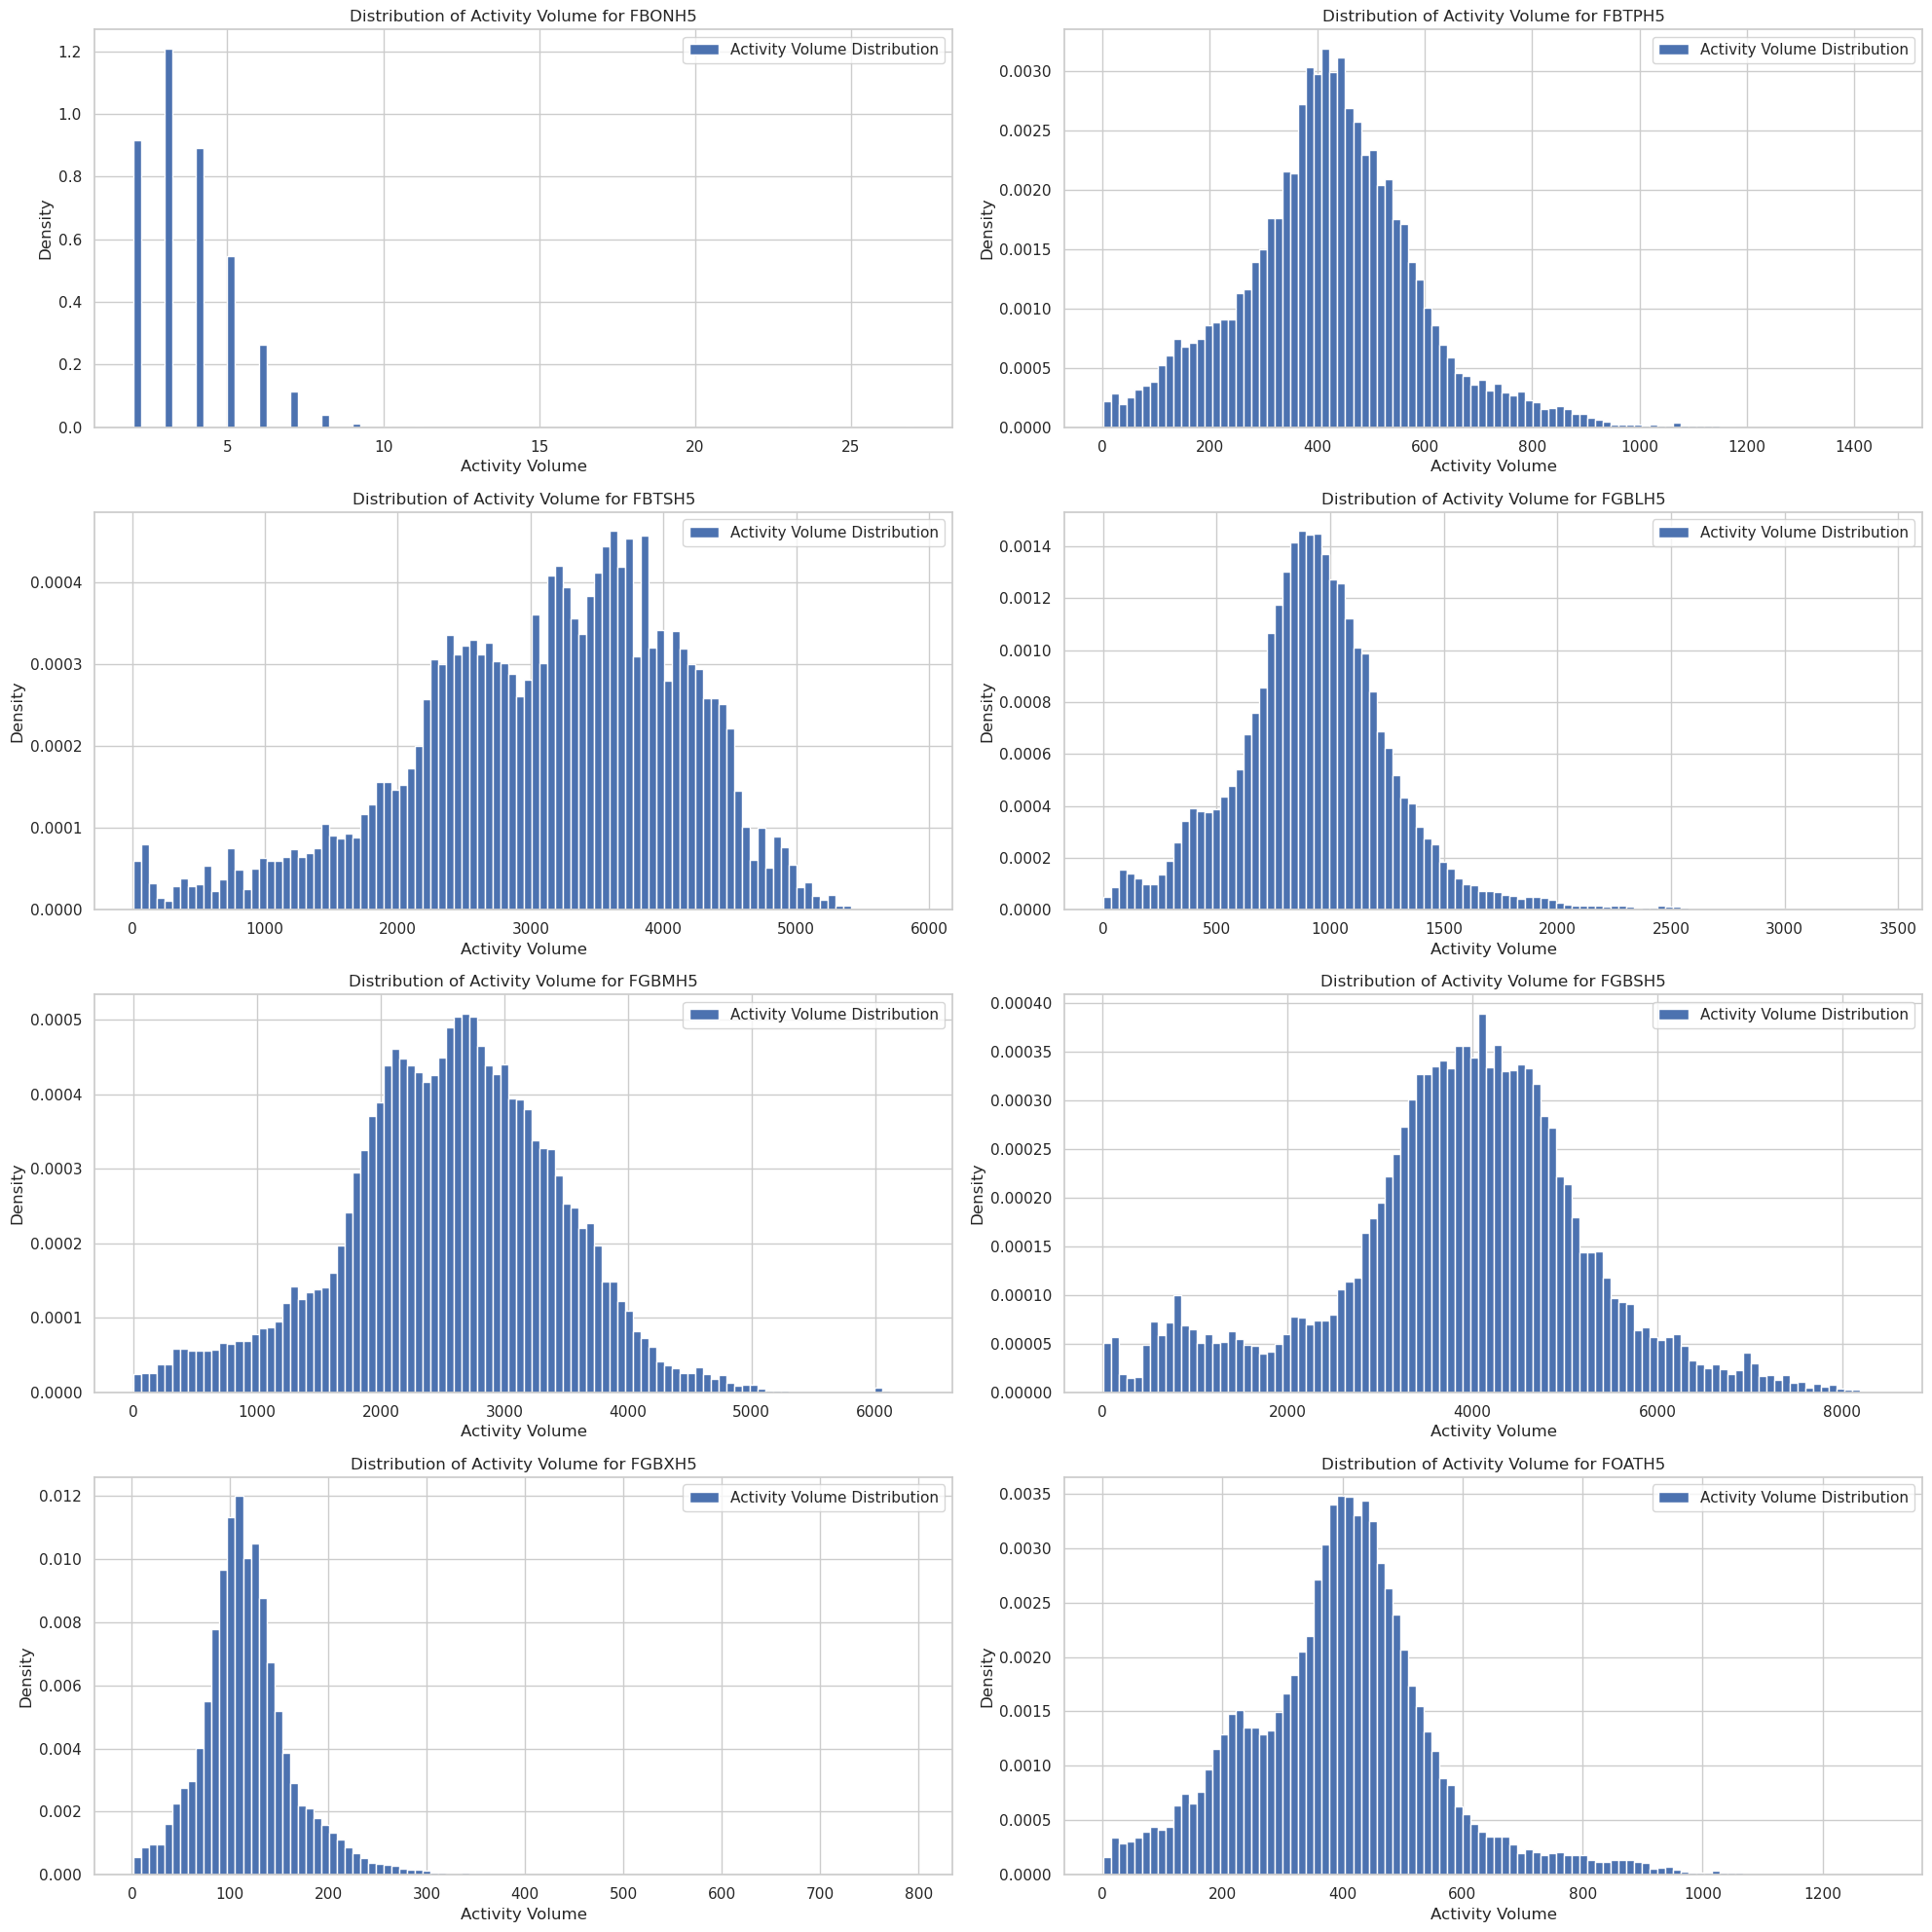

In [60]:
symbols = list(symbols_data_map.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, sym in enumerate(symbols):
    df_symbol = symbols_data_map[sym]
    
    axes[i].hist(df_symbol['activity_volume'].dropna(), bins=100, label='Activity Volume Distribution', density=True) # Using density=True for easier comparison
    # You might want to add a log scale to the y-axis if the distribution is heavily skewed:
    # axes[i].set_yscale('log')
    
    axes[i].set_title(f'Distribution of Activity Volume for {sym}')
    axes[i].set_xlabel('Activity Volume')
    axes[i].set_ylabel('Density') # Or 'Frequency' if density=False
    axes[i].legend()
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Comparing Moving Averages for activity_volume

/tmp/ipykernel_2294323/2605705863.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


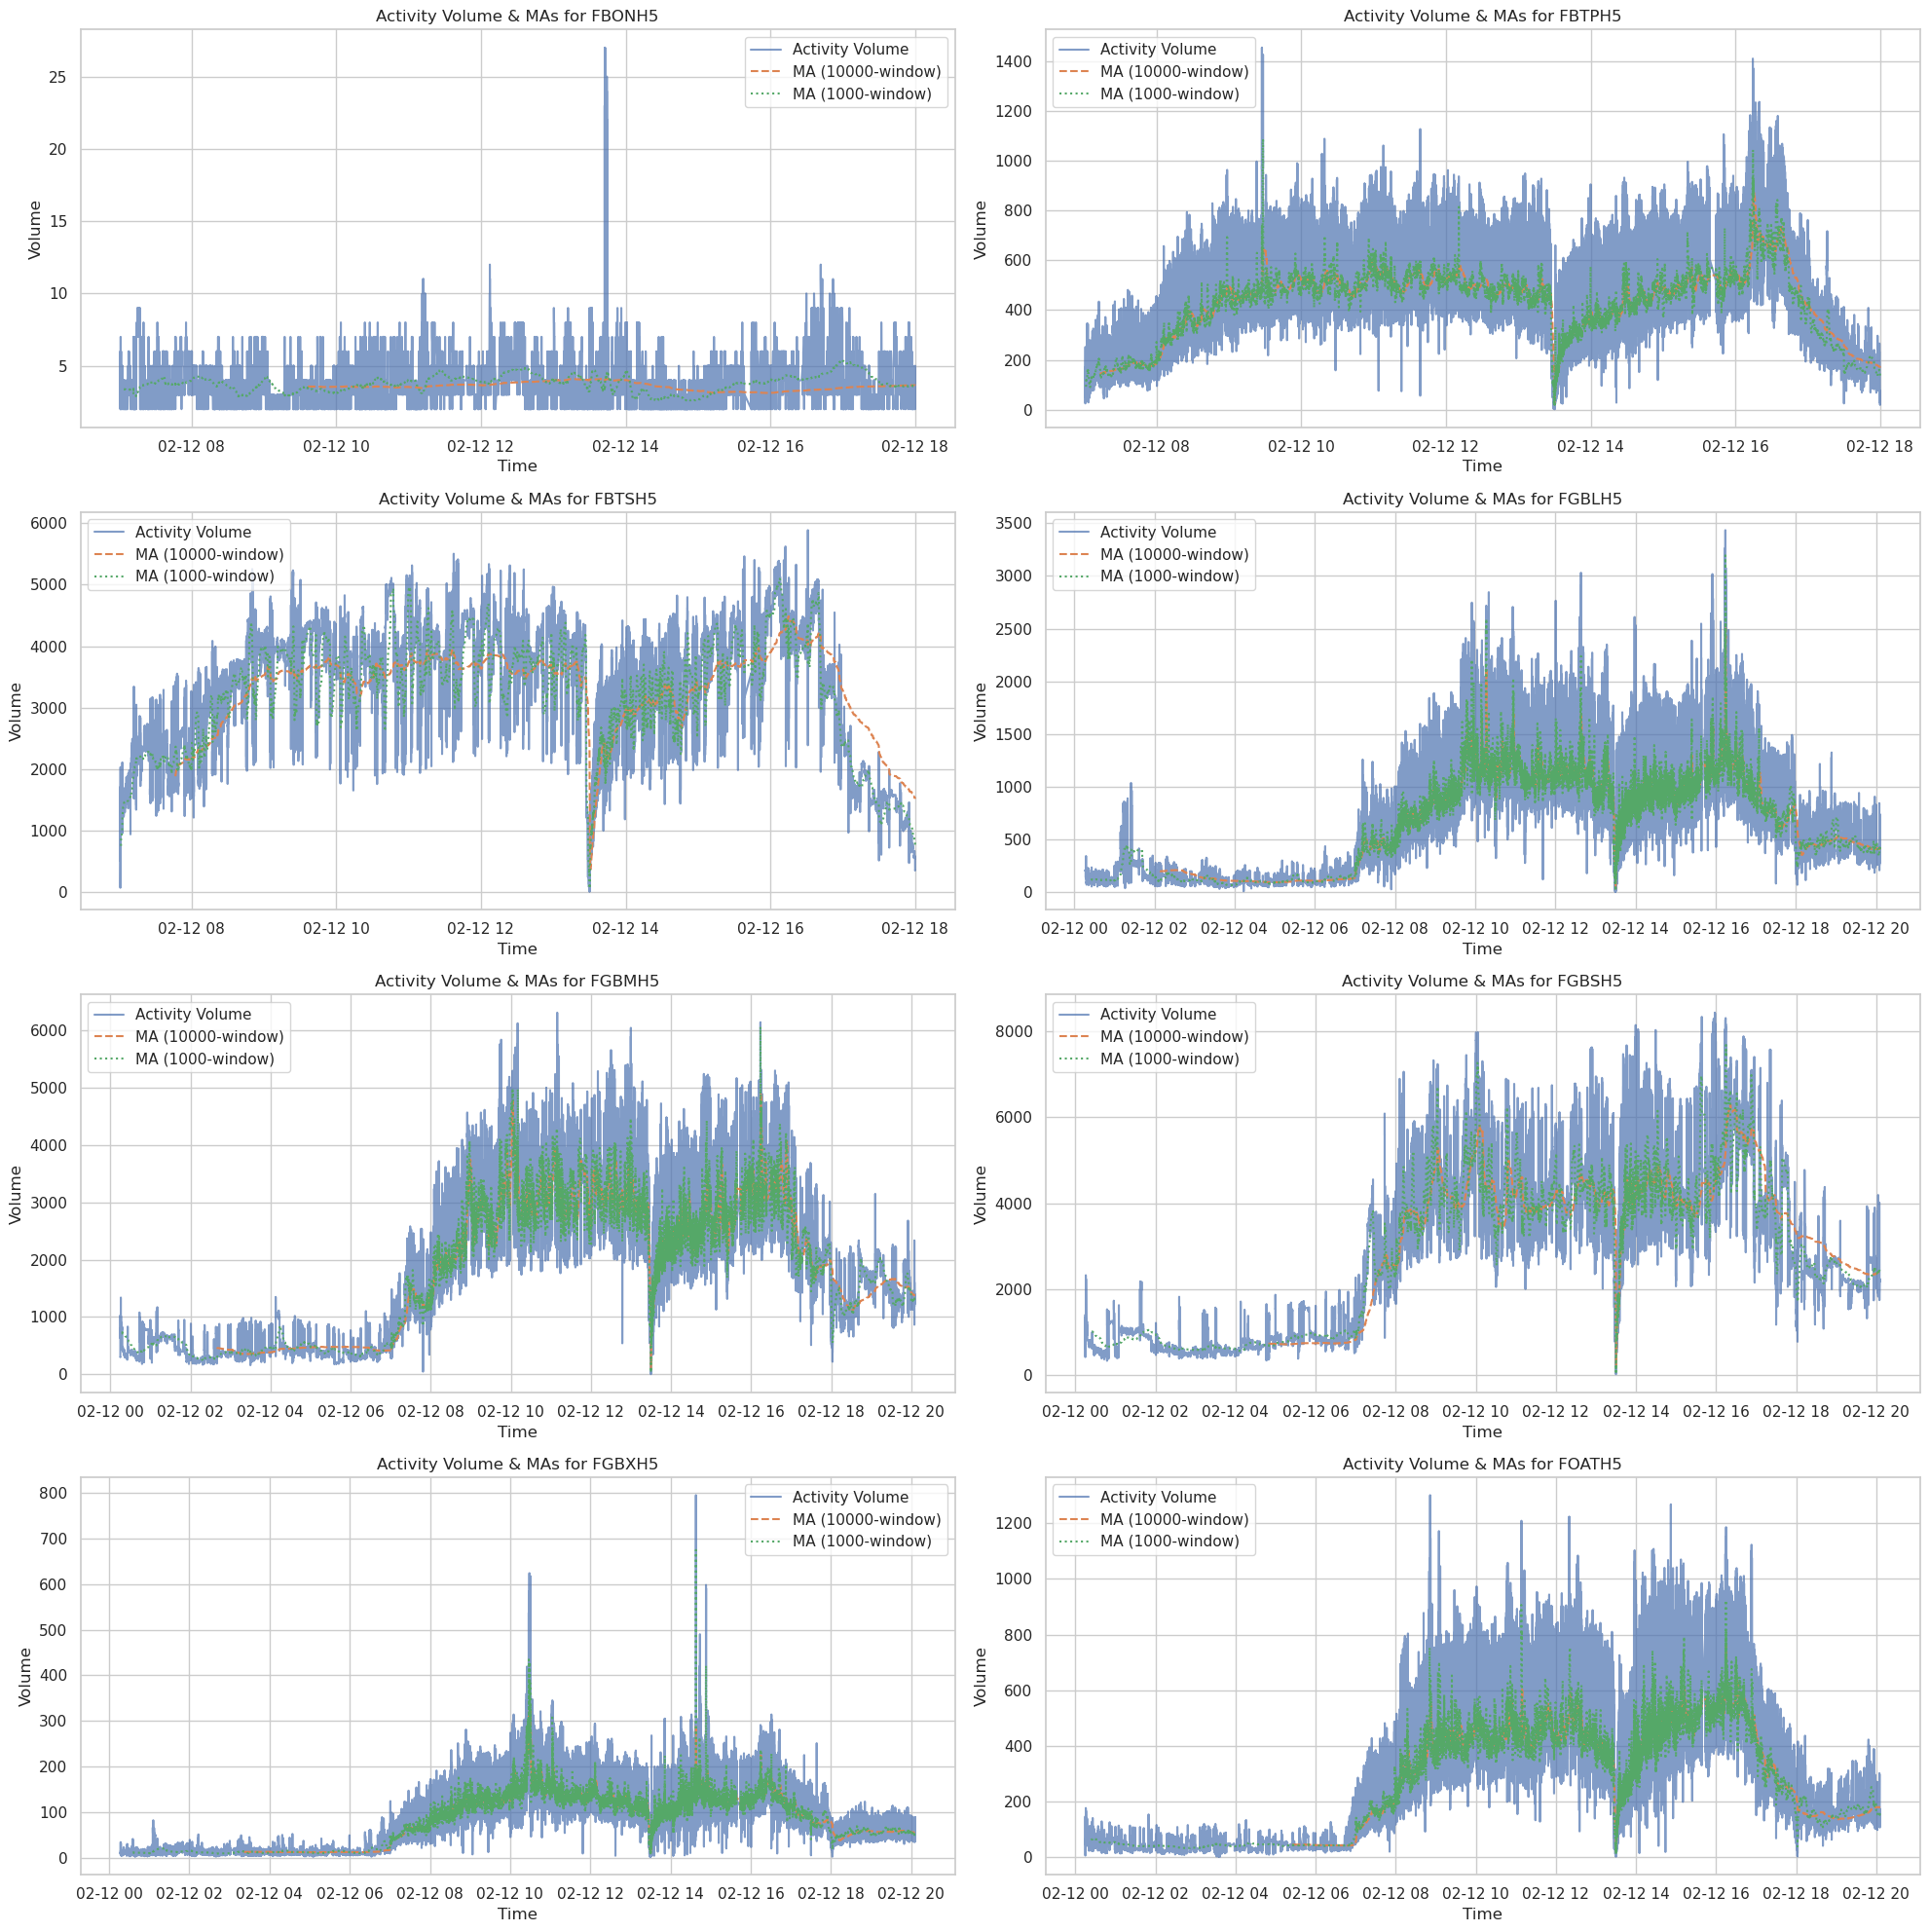

In [61]:
symbols = list(symbols_data_map.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(20, 5 * num_rows))
axes = axes.flatten()

for i, sym in enumerate(symbols):
    df_symbol = symbols_data_map[sym].copy() # Use .copy()
    
    # Calculate a shorter-term MA
    df_symbol['activity_volume_ma_short'] = df_symbol['activity_volume'].rolling(window=1000).mean()
    
    axes[i].plot(df_symbol['time'], df_symbol['activity_volume'], label='Activity Volume', alpha=0.7)
    axes[i].plot(df_symbol['time'], df_symbol['activity_volume_ma'], label='MA (10000-window)', linestyle='--') # Original long MA
    axes[i].plot(df_symbol['time'], df_symbol['activity_volume_ma_short'], label='MA (1000-window)', linestyle=':') # New short MA
    
    axes[i].set_title(f'Activity Volume & MAs for {sym}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Volume')
    axes[i].legend()
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2294323/1072121342.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Symbol', y='PercentageZeroDelta', data=df_zero_deltas, palette='coolwarm')


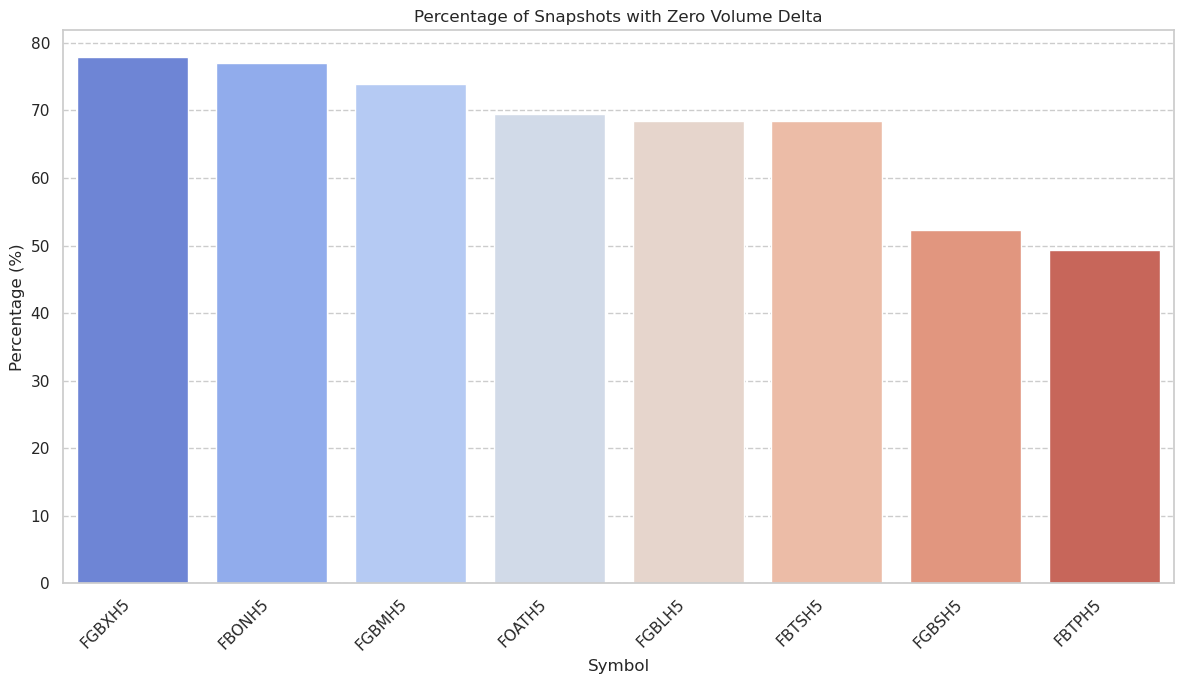

   Symbol  PercentageZeroDelta
6  FGBXH5            77.968468
0  FBONH5            77.058083
4  FGBMH5            73.983943
7  FOATH5            69.535360
3  FGBLH5            68.455479
2  FBTSH5            68.447247
5  FGBSH5            52.273557
1  FBTPH5            49.409768


In [62]:
zero_delta_percentages = {}
for sym, df_symbol in symbols_data_map.items():
    total_snapshots = len(df_symbol['volume_delta'].dropna()) 
    if total_snapshots > 0:
        zero_deltas = (df_symbol['volume_delta'].dropna() == 0).sum()
        zero_delta_percentages[sym] = (zero_deltas / total_snapshots) * 100
    else:
        zero_delta_percentages[sym] = 0 

# Create a DataFrame for plotting
df_zero_deltas = pd.DataFrame(list(zero_delta_percentages.items()), columns=['Symbol', 'PercentageZeroDelta'])
df_zero_deltas = df_zero_deltas.sort_values('PercentageZeroDelta', ascending=False)

# Plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Symbol', y='PercentageZeroDelta', data=df_zero_deltas, palette='coolwarm')
plt.title('Percentage of Snapshots with Zero Volume Delta')
plt.xlabel('Symbol')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print(df_zero_deltas)

## Volume Bars Analysis

In [63]:
def compute_nb_bars_for_all_symbols(
        symbols_data_map: Dict[str, pd.DataFrame], 
        min_avg_snapshots_per_bar: int = 150,
        max_nb_bars: int = 7500
    ) -> Dict[str, int]:
    """Create volume bars for all symbols based on the number of snapshots.

    This function calculates the number of volume bars for each symbol in the
    provided data map, ensuring that the number of bars does not exceed the
    specified maximum and is based on a minimum average number of snapshots per bar.

    Args:
        symbols_data_map (Dict[str, pd.DataFrame]): A dictionary mapping symbol names to their corresponding DataFrames.
        min_avg_snapshots_per_bar (int, optional): Minimum average snapshots required per bar. Defaults to 150.
        max_nb_bars (int, optional): Maximum number of bars allowed per symbol. Defaults to 7500.

    Returns:
        Dict[str, int]: A dictionary mapping each symbol to the calculated number of bars.
    """
    nb_bars_by_symbol = {} 
    for key, data in symbols_data_map.items():
        nb_snapshots = data.shape[0]
        nb_bars_for_quality = nb_snapshots // min_avg_snapshots_per_bar
        final_nb_bars = min(nb_bars_for_quality, max_nb_bars)
        nb_bars_by_symbol[key] = final_nb_bars
    return nb_bars_by_symbol


def create_volume_bars_for_all_symbols(
        symbols_data_map: Dict[str, pd.DataFrame], 
        nb_bars_by_symbol: Dict[str, int]
    ) -> Dict[str, pd.DataFrame]:
    """Create volume bars for all symbols based on the number of bars.

    This function creates volume bars for all symbols in the provided data map,
    using the number of bars specified for each symbol in the nb_bars_by_symbol
    dictionary.

    Args:
        symbols_data_map (Dict[str, pd.DataFrame]): A dictionary mapping symbol names to their corresponding DataFrames.    
        nb_bars_by_symbol (Dict[str, int]): A dictionary mapping each symbol to the calculated number of bars.

    Returns:
        Dict[str, pd.DataFrame]: A dictionary mapping each symbol to its volume bars DataFrame.
    """

    volume_bars_by_symbol = {}
    for key, data in symbols_data_map.items():
        print(f"Processing symbol: {key}")
        # Sort data by time
        data = data.sort_values('time').reset_index(drop=True)
        # Create activity volume column
        data['activity_volume'] = data['L1_bid_size'] + data['L1_ask_size']
        data['activity_volume'] = data['activity_volume'].fillna(0)
        # Create moving average of activity volume
        data['activity_volume_ma'] = data['activity_volume'].rolling(window=10000).mean()
        # Create cumulative activity volume
        data['cumulative_activity_volume'] = data['activity_volume'].cumsum()
        # Create volume delta column
        data['volume_delta'] = data['activity_volume'].diff()

        print(f"Shape of data: {data.shape}")

        total_proxy_volume = data['cumulative_activity_volume'].max()
        print(f"Max cumulative activity volume: {total_proxy_volume:,.0f}")

        nb_bars = nb_bars_by_symbol[key]
        print(f"Number of bars: {nb_bars}")

        volume_threshold = total_proxy_volume / nb_bars
        print(f"Volume threshold: {volume_threshold:,.0f}")

        volume_bars_df, snapshots_with_bars = create_volume_bars(
            data,
            nb_bars=nb_bars,
            activity_col_name='activity_volume',
            wmp_col_name='weighted_mid_price',
            time_col_name='time'
        )
        volume_bars_by_symbol[key] = volume_bars_df
    return volume_bars_by_symbol

In [64]:
nb_bars_by_symbol = compute_nb_bars_for_all_symbols(symbols_data_map, max_nb_bars=10000)
volume_bars_by_symbol = create_volume_bars_for_all_symbols(symbols_data_map, nb_bars_by_symbol)

Processing symbol: FBONH5
Shape of data: (42905, 85)
Max cumulative activity volume: 158,325
Number of bars: 286
Volume threshold: 554
Volume threshold: 553.0
Processing symbol: FBTPH5


/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


Shape of data: (1624107, 85)
Max cumulative activity volume: 687,790,472
Number of bars: 10000
Volume threshold: 68,779
Volume threshold: 68779.0


/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


Processing symbol: FBTSH5
Shape of data: (384576, 85)
Max cumulative activity volume: 1,192,769,411
Number of bars: 2563
Volume threshold: 465,380
Volume threshold: 465380.0


...

/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


Processing symbol: FGBXH5
Shape of data: (4146644, 85)
Max cumulative activity volume: 490,639,946
Number of bars: 10000
Volume threshold: 49,064
Volume threshold: 49063.0


/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


Processing symbol: FOATH5
Shape of data: (2700417, 85)
Max cumulative activity volume: 1,068,992,495
Number of bars: 10000
Volume threshold: 106,899
Volume threshold: 106899.0


/tmp/ipykernel_2294323/1300065096.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)


In [65]:
for symbol in volume_bars_by_symbol.keys():
    print(f"Shape of volume bars for {symbol}: {volume_bars_by_symbol[symbol].shape}")

Shape of volume bars for FBONH5: (286, 11)
Shape of volume bars for FBTPH5: (10000, 11)
Shape of volume bars for FBTSH5: (2563, 11)
Shape of volume bars for FGBLH5: (10000, 11)
Shape of volume bars for FGBMH5: (10000, 11)
Shape of volume bars for FGBSH5: (4289, 11)
Shape of volume bars for FGBXH5: (10000, 11)
Shape of volume bars for FOATH5: (10000, 11)


In [66]:
def get_descriptive_stats_for_column(
    volume_bars_by_symbol: dict[str, pd.DataFrame], 
    column_name: str
) -> pd.DataFrame | None:
    """
    Generates and returns a DataFrame of descriptive statistics for a specified column,
    compared across all symbols.

    Args:
        volume_bars_by_symbol (Dict[str, pd.DataFrame]): 
            A dictionary where keys are symbol strings and values are their 
            respective volume bars DataFrames.
        column_name (str): 
            The name of the column for which to generate descriptive statistics.
            If 'wmp_return', it will be calculated if not present.

    Returns:
        pd.DataFrame | None: 
            A DataFrame with symbols as rows and descriptive statistics 
            (count, mean, std, etc.) as columns for the specified column_name.
            Returns None if no statistics could be generated (e.g., column not found,
            empty data).
    """
    symbol_stats_list = []

    # Ensure pandas display options for better readability within this function's context if printing
    # pd.set_option('display.float_format', lambda x: '%.4f' % x)
    # pd.set_option('display.max_columns', None)
    # pd.set_option('display.width', 120)

    for sym, bars_df_original in volume_bars_by_symbol.items():
        if bars_df_original is None or bars_df_original.empty:
            print(f"DataFrame for symbol {sym} is empty or None. Skipping for column '{column_name}'.")
            continue

        bars_df = bars_df_original.copy() # Work on a copy

        # Special handling for 'wmp_return' if it needs to be calculated
        if column_name == 'wmp_return' and 'wmp_return' not in bars_df.columns:
            if 'last_wmp' in bars_df.columns and 'first_wmp' in bars_df.columns:
                bars_df['wmp_return'] = bars_df['last_wmp'] - bars_df['first_wmp']
            else:
                print(f"Cannot calculate 'wmp_return' for {sym} as 'last_wmp' or 'first_wmp' is missing. Skipping.")
                continue
        
        if column_name in bars_df.columns:
            stats_series = bars_df[column_name].describe()
            stats_series.name = sym  # Set the name of the Series to the symbol
            symbol_stats_list.append(stats_series)
        else:
            print(f"Column '{column_name}' not found in bars_df for symbol {sym}.")
            
    if not symbol_stats_list:
        print(f"No statistics generated for column '{column_name}' across any symbols.")
        return None
        
    # Combine all Series into a DataFrame. Each Series becomes a column.
    # Then transpose so symbols are rows and stats are columns.
    combined_df_for_column = pd.concat(symbol_stats_list, axis=1).T
    return combined_df_for_column

### Bar Duration

In [67]:
volume_bars_by_symbol['FGBLH5'][1000:1010]

,bar_id,bar_start_time,bar_end_time,num_snapshots_in_bar,actual_volume_in_bar,mean_wmp,first_wmp,last_wmp,min_wmp,max_wmp,bar_duration_seconds
1000,1000,2025-02-12 09:13:37.884228952,2025-02-12 09:13:37.944534309,491,420422.0,132.660970,132.659964,132.662428,132.659786,132.662576,0.060305
1001,1001,2025-02-12 09:13:37.944536089,2025-02-12 09:13:48.673085816,522,420632.0,132.662404,132.662428,132.662617,132.660811,132.662923,10.728550
1002,1002,2025-02-12 09:13:48.673093497,2025-02-12 09:14:04.992777429,503,421215.0,132.663172,132.662617,132.663418,132.662254,132.663978,16.319684
1003,1003,2025-02-12 09:14:04.992945335,2025-02-12 09:14:06.773086458,557,420973.0,132.662376,132.663187,132.661584,132.660987,132.663410,1.780141
1004,1004,2025-02-12 09:14:06.773091077,2025-02-12 09:14:06.933466888,551,420874.0,132.661566,132.661584,132.662806,132.659823,132.663084,0.160376
1005,1005,2025-02-12 09:14:06.933471702,2025-02-12 09:14:07.379071265,530,420492.0,132.660703,132.662806,132.658963,132.658613,132.662806,0.445600
1006,1006,2025-02-12 09:14:07.379079774,2025-02-12 09:14:08.580457456,484,420915.0,132.659878,132.658963,132.657861,132.657861,132.661838,1.201378
1007,1007,2025-02-12 09:14:08.580478817,2025-02-12 09:14:12.748668573,447,420235.0,132.657021,132.657853,132.655716,132.655594,132.658497,4.168190
1008,1008,2025-02-12 09:14:12.902612671,2025-02-12 09:14:30.000830776,479,421280.0,132.656032,132.655709,132.655418,132.655418,132.656596,17.098218
1009,1009,2025-02-12 09:14:30.000836111,2025-02-12 09:14:44.325608260,465,420926.0,132.654578,132.655418,132.654330,132.652664,132.655448,14.324772


In [68]:
volume_bars_by_symbol['FGBLH5'].sample(10)

,bar_id,bar_start_time,bar_end_time,num_snapshots_in_bar,actual_volume_in_bar,mean_wmp,first_wmp,last_wmp,min_wmp,max_wmp,bar_duration_seconds
1543,1543,2025-02-12 09:50:16.333396747,2025-02-12 09:50:18.668461449,358,421365.0,132.617626,132.614956,132.619990,132.614932,132.619990,2.335065
7486,7486,2025-02-12 14:45:32.912437275,2025-02-12 14:45:32.915526971,441,420993.0,132.247142,132.247993,132.247118,132.246481,132.247993,0.003090
6400,6400,2025-02-12 14:08:42.425472259,2025-02-12 14:08:42.664195358,463,420029.0,132.220777,132.223207,132.221422,132.218684,132.223207,0.238723
9244,9244,2025-02-12 16:21:17.343972004,2025-02-12 16:21:19.980085916,315,420210.0,132.191619,132.187557,132.193515,132.187557,132.193515,2.636114
5107,5107,2025-02-12 13:26:15.435384884,2025-02-12 13:26:17.411268889,545,420500.0,132.609492,132.609120,132.609859,132.608276,132.610301,1.975884
8238,8238,2025-02-12 15:27:34.387314051,2025-02-12 15:27:41.929319523,436,420363.0,132.149741,132.149441,132.150484,132.148545,132.151433,7.542005
6496,6496,2025-02-12 14:12:21.086637541,2025-02-12 14:12:21.207870379,346,421082.0,132.210234,132.210145,132.210145,132.209088,132.211213,0.121233
9203,9203,2025-02-12 16:18:45.800607673,2025-02-12 16:18:54.418315060,355,420524.0,132.166673,132.166177,132.166050,132.165570,132.167401,8.617707
113,113,2025-02-12 07:47:47.897058814,2025-02-12 07:48:04.462334476,881,420909.0,132.619824,132.619845,132.620623,132.616800,132.624224,16.565276
3969,3969,2025-02-12 12:15:46.389469183,2025-02-12 12:15:46.419541224,313,420558.0,132.514420,132.514458,132.514387,132.514333,132.514478,0.030072


In [69]:
stats_df = get_descriptive_stats_for_column(volume_bars_by_symbol, 'bar_duration_seconds')
stats_df

,count,mean,std,min,25%,50%,75%,max
FBONH5,286.0,137.137307,85.874426,1.042632,77.586651,127.124199,177.352704,554.817563
FBTPH5,10000.0,3.928149,7.671731,0.000291,0.509066,2.103071,4.788508,312.012444
FBTSH5,2563.0,15.308901,20.835158,0.002572,4.527139,9.778098,19.202291,334.578549
FGBLH5,10000.0,7.126121,69.895548,0.000961,0.397378,2.030553,5.379355,2890.239722
FGBMH5,10000.0,7.127940,62.094739,0.000901,0.244355,1.805304,5.381376,2411.429775
FGBSH5,4289.0,16.570776,91.688334,0.000550,1.319760,5.207404,13.301682,2165.556792
FGBXH5,10000.0,7.121823,101.347616,0.000338,0.289983,1.874483,5.284440,4950.249888
FOATH5,10000.0,7.129208,111.520152,0.000768,0.316792,2.006879,5.161443,6179.010708


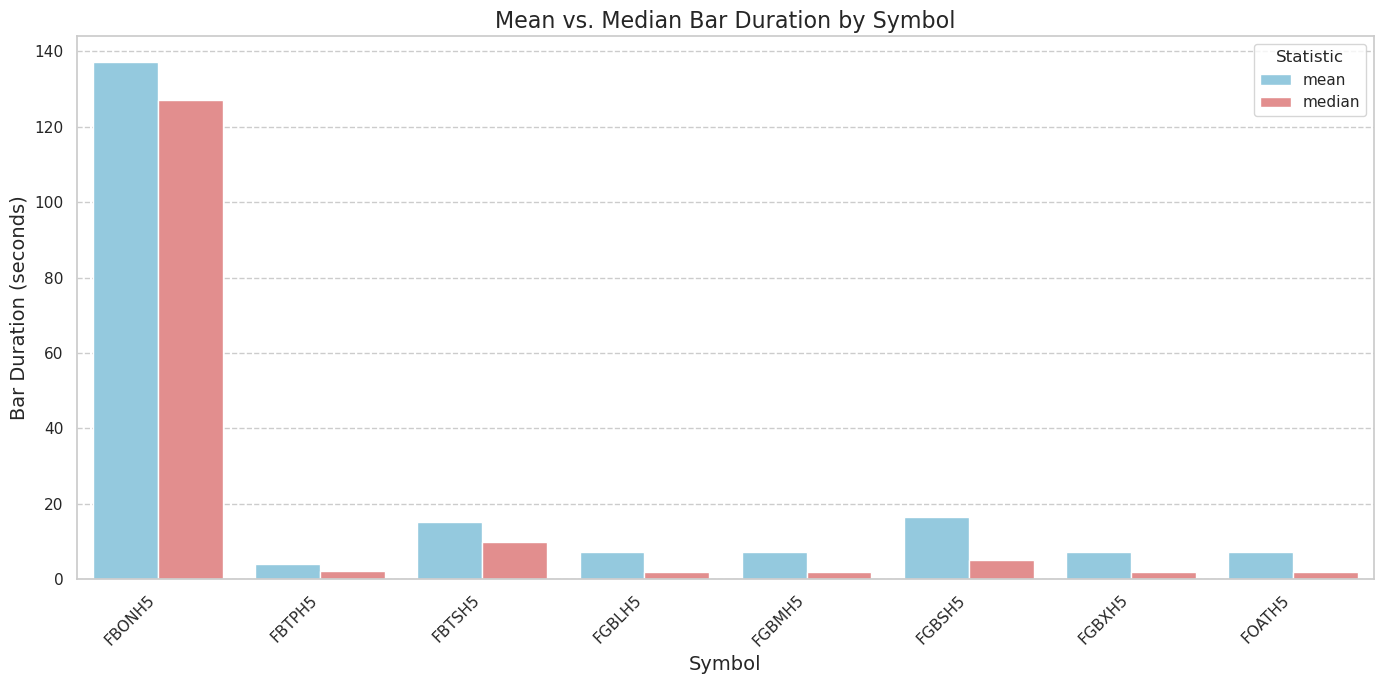

In [70]:
plot_data = stats_df[['mean', '50%']].copy()
plot_data.rename(columns={'50%': 'median'}, inplace=True)
plot_data = plot_data.reset_index().rename(columns={'index': 'Symbol'})

# Melt the DataFrame to have 'mean' and 'median' as categories for hue
plot_data_melted = plot_data.melt(id_vars='Symbol', 
                                    value_vars=['mean', 'median'], 
                                    var_name='Statistic', 
                                    value_name='Duration (s)')

plt.figure(figsize=(14, 7))
sns.barplot(x='Symbol', y='Duration (s)', hue='Statistic', data=plot_data_melted, palette={'mean': 'skyblue', 'median': 'lightcoral'})

plt.title('Mean vs. Median Bar Duration by Symbol', fontsize=16)
plt.xlabel('Symbol', fontsize=14)
plt.ylabel('Bar Duration (seconds)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Statistic')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

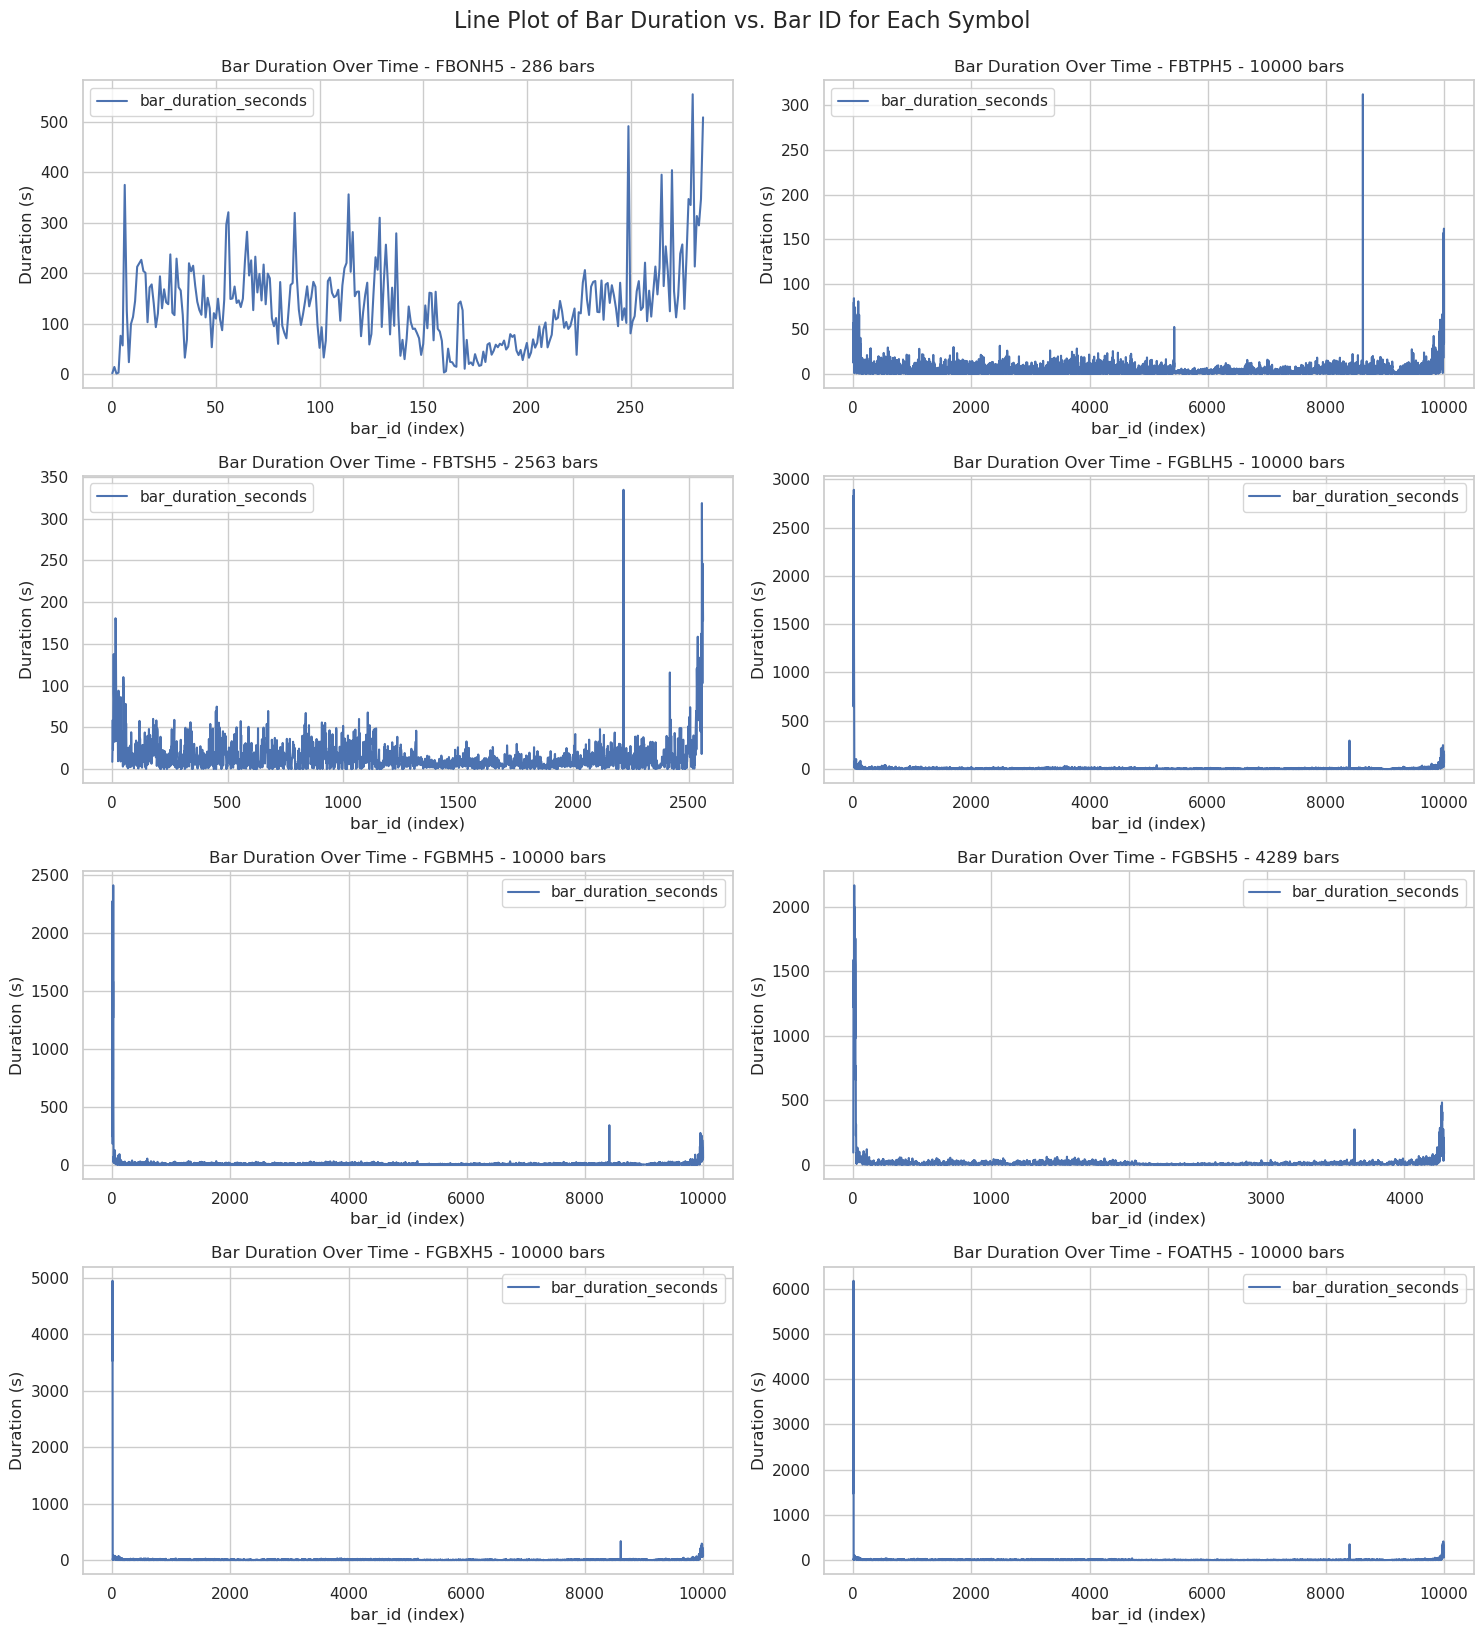

In [71]:
symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False) # Ensure axes is 2D
axes = axes.flatten()

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol[sym]
    if not bars_df.empty:
        axes[i].plot(bars_df.index, bars_df['bar_duration_seconds'], label='bar_duration_seconds') # Use index if bar_id is the index
        axes[i].set_title(f'Bar Duration Over Time - {sym} - {bars_df.shape[0]} bars')
        axes[i].set_xlabel('bar_id (index)')
        axes[i].set_ylabel('Duration (s)')
        axes[i].legend()
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No data for {sym}')
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Line Plot of Bar Duration vs. Bar ID for Each Symbol', y=1.02, fontsize=16)
plt.show()

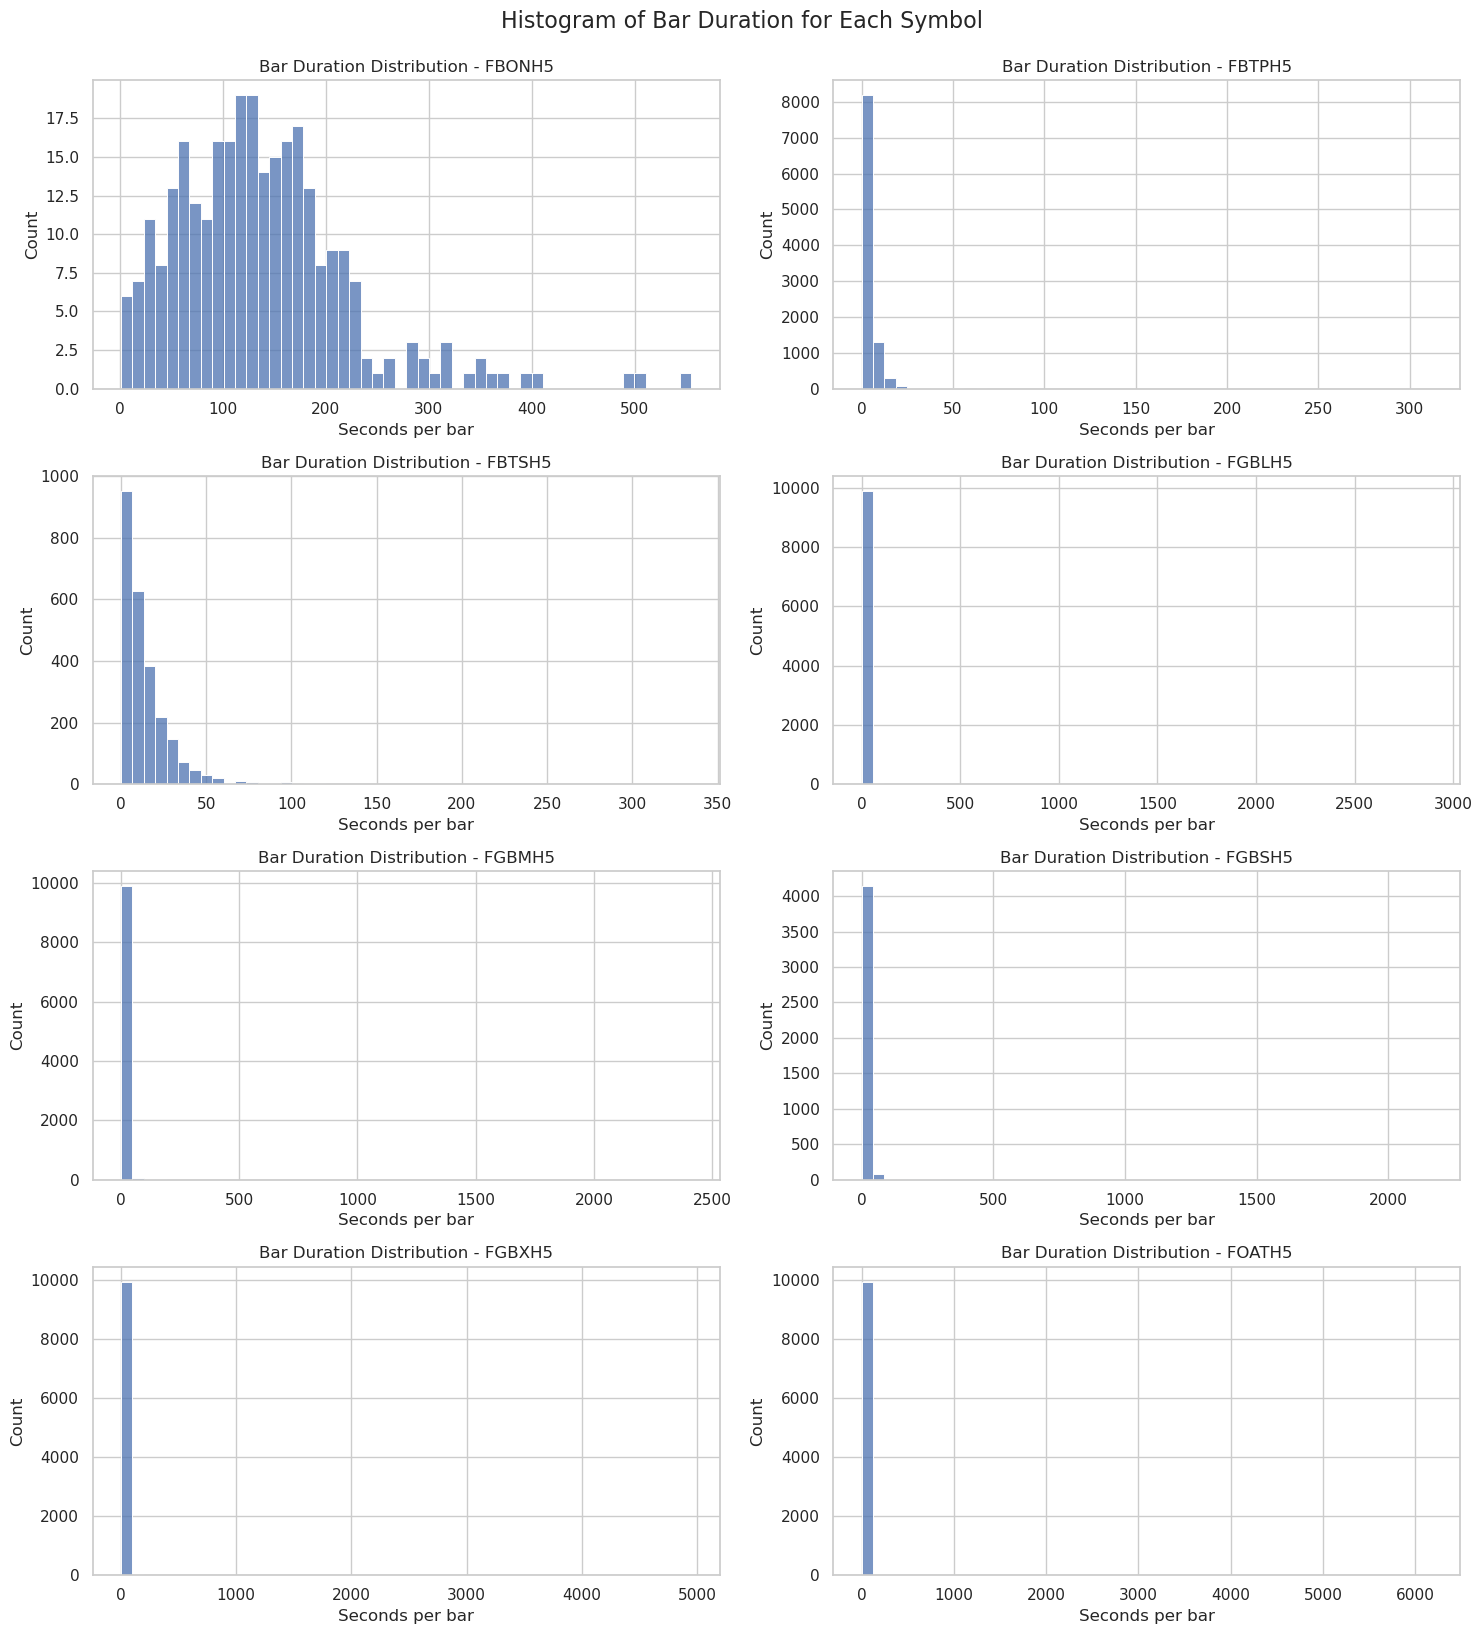

In [72]:
symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False)
axes = axes.flatten()

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol[sym]
    if not bars_df.empty:
        sns.histplot(data=bars_df, x='bar_duration_seconds', bins=50, kde=False, ax=axes[i])
        axes[i].set_title(f'Bar Duration Distribution - {sym}')
        axes[i].set_xlabel('Seconds per bar')
        axes[i].set_ylabel('Count')
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No data for {sym}')
        axes[i].axis('off')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram of Bar Duration for Each Symbol', y=1.02, fontsize=16)
plt.show()

### Number of Snapshots in Bar

In [73]:
stats_df = get_descriptive_stats_for_column(volume_bars_by_symbol, 'num_snapshots_in_bar')
stats_df

,count,mean,std,min,25%,50%,75%,max
FBONH5,286.0,149.762238,34.785954,52.0,125.25,145.0,177.75,241.0
FBTPH5,10000.0,162.409600,95.630799,58.0,127.00,145.0,170.00,4349.0
FBTSH5,2563.0,150.048381,101.433107,87.0,116.00,134.0,162.50,4140.0
FGBLH5,10000.0,452.431900,241.349068,124.0,354.00,412.0,491.00,10772.0
FGBMH5,10000.0,292.411500,161.407122,123.0,224.00,265.0,321.00,7486.0
FGBSH5,4289.0,150.026113,113.166878,71.0,118.00,136.0,157.00,5139.0
FGBXH5,10000.0,414.648600,199.607104,62.0,329.00,385.0,454.00,5102.0
FOATH5,10000.0,270.040100,156.749820,103.0,206.00,240.0,284.00,5507.0


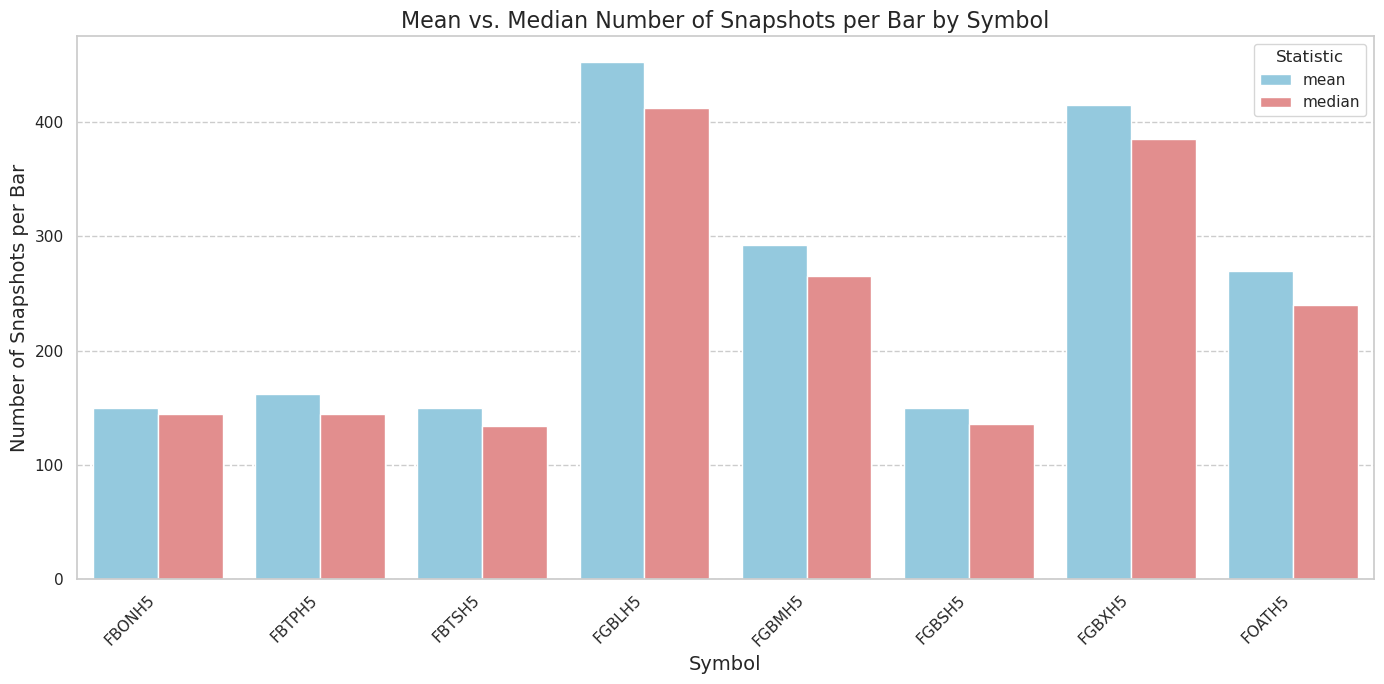

In [74]:
plot_data = stats_df[['mean', '50%']].copy()
plot_data.rename(columns={'50%': 'median'}, inplace=True)
plot_data = plot_data.reset_index().rename(columns={'index': 'Symbol'})

# Melt the DataFrame to have 'mean' and 'median' as categories for hue
plot_data_melted = plot_data.melt(id_vars='Symbol', 
                                    value_vars=['mean', 'median'], 
                                    var_name='Statistic', 
                                    value_name='Duration (s)')

plt.figure(figsize=(14, 7))
sns.barplot(x='Symbol', y='Duration (s)', hue='Statistic', data=plot_data_melted, palette={'mean': 'skyblue', 'median': 'lightcoral'})

plt.title('Mean vs. Median Number of Snapshots per Bar by Symbol', fontsize=16)
plt.xlabel('Symbol', fontsize=14)
plt.ylabel('Number of Snapshots per Bar', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Statistic')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

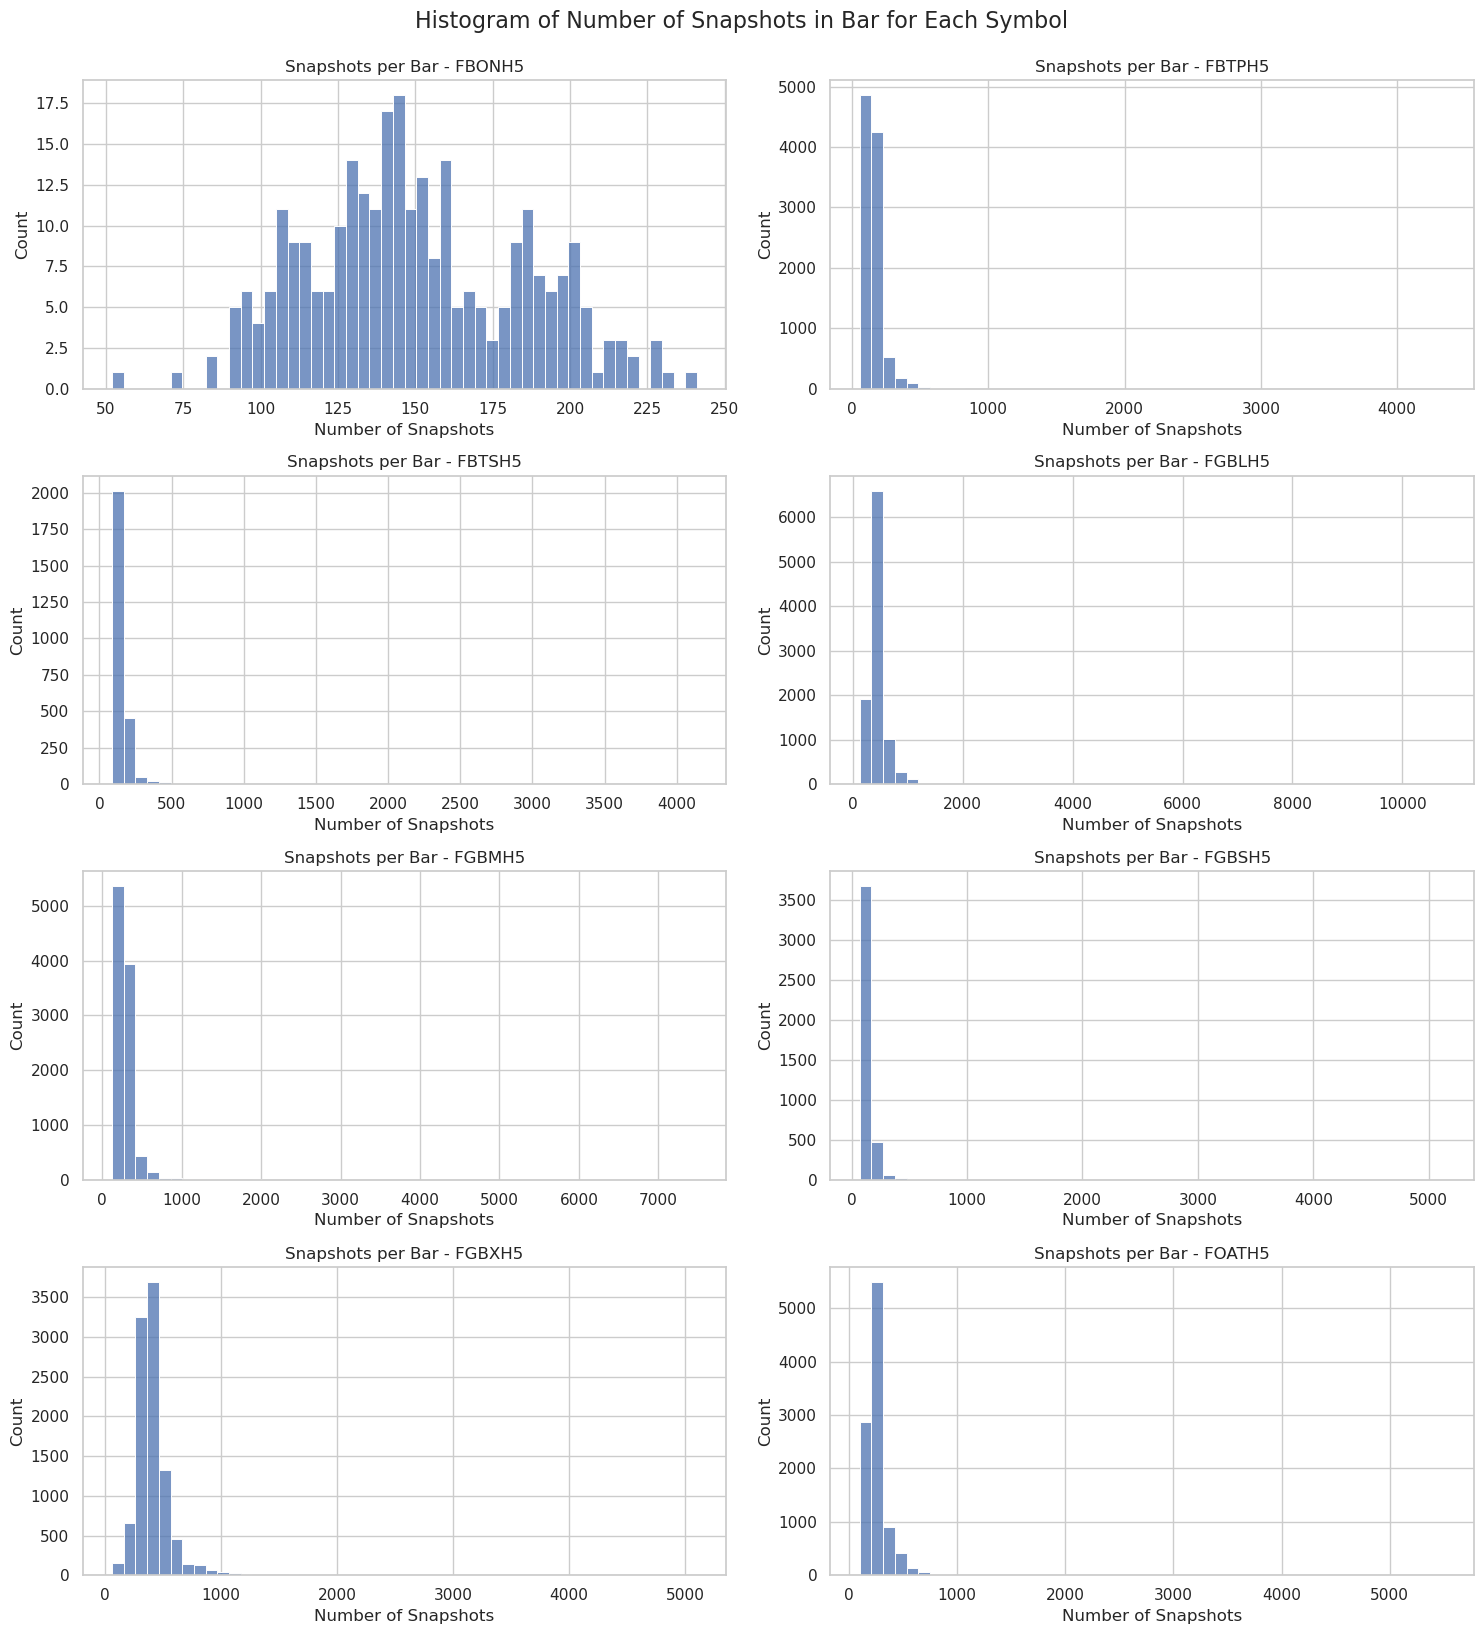

In [75]:
symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False)
axes = axes.flatten()

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol[sym]
    if not bars_df.empty:
        sns.histplot(data=bars_df, x='num_snapshots_in_bar', bins=50, kde=False, ax=axes[i])
        axes[i].set_title(f'Snapshots per Bar - {sym}')
        axes[i].set_xlabel('Number of Snapshots')
        axes[i].set_ylabel('Count')
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No data for {sym}')
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram of Number of Snapshots in Bar for Each Symbol', y=1.02, fontsize=16)
plt.show()

### WMP Mean

In [76]:
stats_df = get_descriptive_stats_for_column(volume_bars_by_symbol, 'mean_wmp')
stats_df

,count,mean,std,min,25%,50%,75%,max
FBONH5,286.0,124.323338,0.167934,124.068074,124.158073,124.375840,124.460089,125.348232
FBTPH5,10000.0,119.873118,0.150994,119.654862,119.714569,119.912644,120.024042,120.121189
FBTSH5,2563.0,107.385687,0.030270,107.316012,107.361614,107.376498,107.414795,107.454701
FGBLH5,10000.0,132.393224,0.177855,132.108463,132.223438,132.482936,132.550446,132.774754
FGBMH5,10000.0,117.337818,0.092552,117.199665,117.247317,117.368010,117.411358,117.551835
FGBSH5,4289.0,106.771130,0.028446,106.707451,106.746935,106.759839,106.788801,106.850545
FGBXH5,10000.0,128.781036,0.347727,128.155382,128.446673,128.865012,129.098527,129.463878
FOATH5,10000.0,123.546017,0.159646,123.313670,123.390272,123.509048,123.710700,123.790352


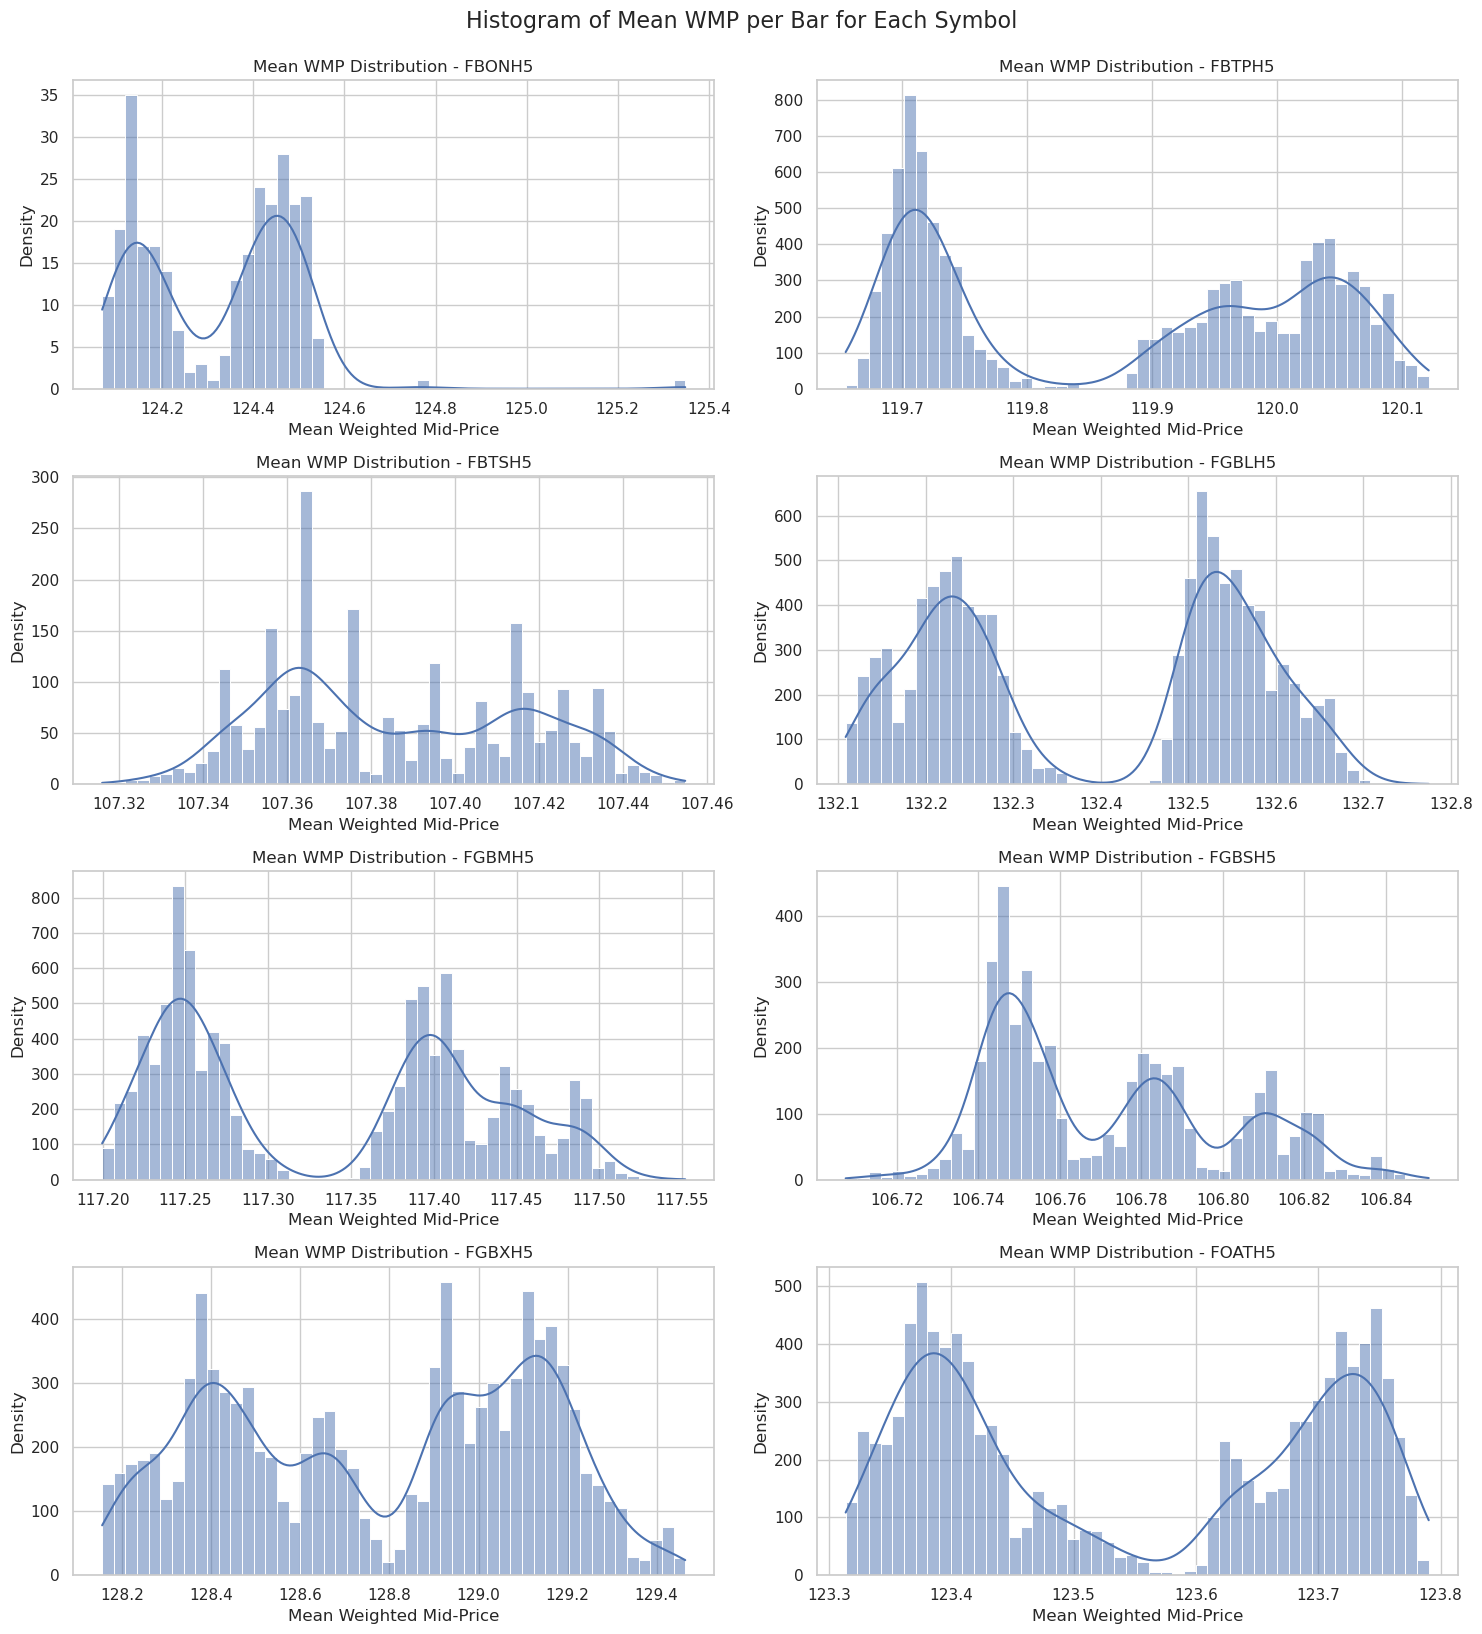

In [77]:
symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False)
axes = axes.flatten()

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol[sym]
    if not bars_df.empty:
        sns.histplot(data=bars_df, x='mean_wmp', bins=50, kde=True, ax=axes[i]) # Added KDE for shape
        axes[i].set_title(f'Mean WMP Distribution - {sym}')
        axes[i].set_xlabel('Mean Weighted Mid-Price')
        axes[i].set_ylabel('Density') # Changed to Density due to KDE
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No data for {sym}')
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram of Mean WMP per Bar for Each Symbol', y=1.02, fontsize=16)
plt.show()

### WMP Return

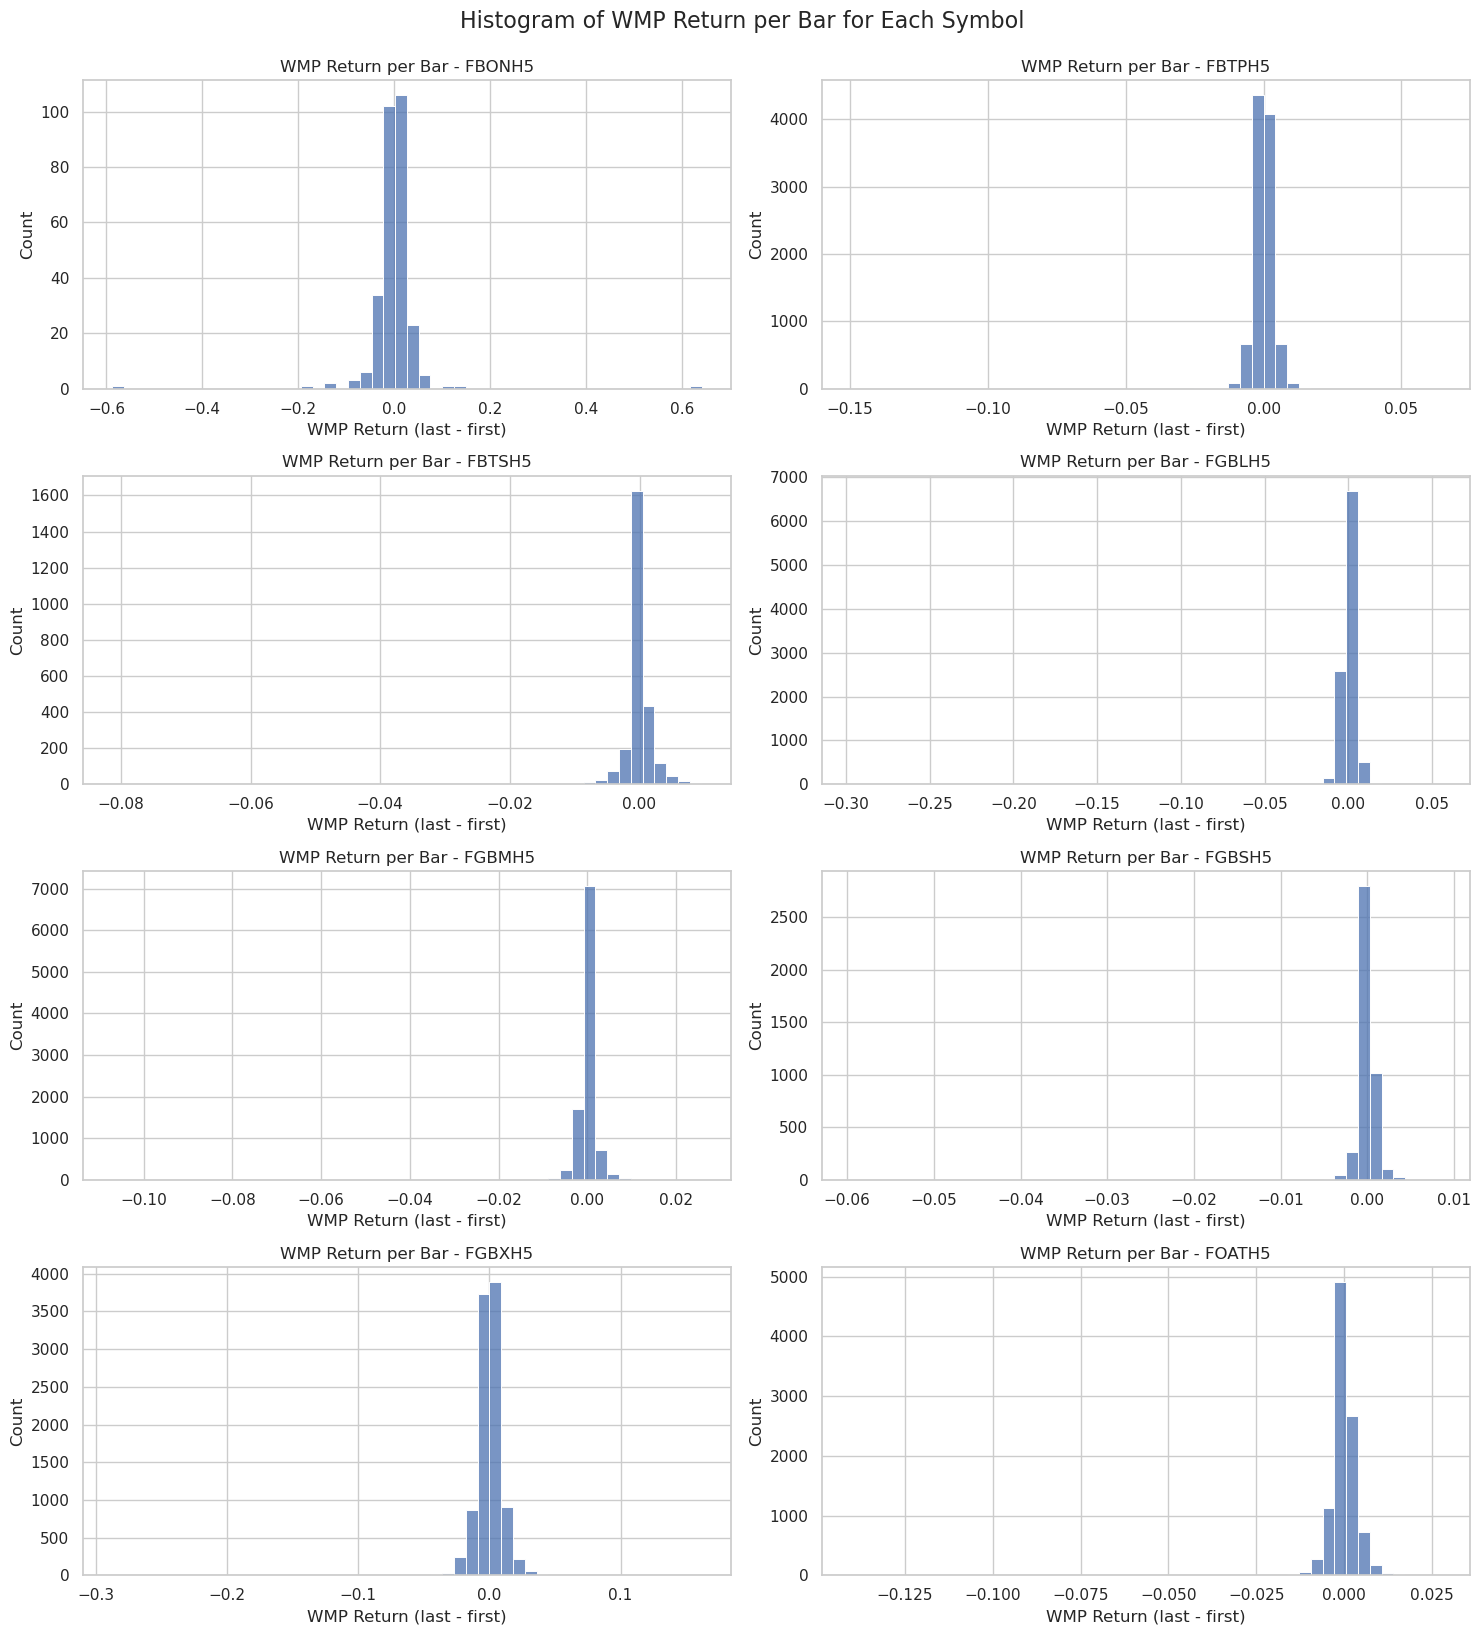

In [78]:
symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False)
axes = axes.flatten()

# Store returns for combined describe later
all_wmp_returns = {}

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol.get(sym) # Use .get() for safer access
    if bars_df is not None and not bars_df.empty:
        # Important: Use .copy() to avoid SettingWithCopyWarning when adding new column
        bars_df = bars_df.copy() 
        bars_df['wmp_return'] = bars_df['last_wmp'] - bars_df['first_wmp']
        all_wmp_returns[sym] = bars_df['wmp_return'] # Store for later
        
        sns.histplot(data=bars_df, x='wmp_return', bins=50, kde=False, ax=axes[i])
        axes[i].set_title(f'WMP Return per Bar - {sym}')
        axes[i].set_xlabel('WMP Return (last - first)')
        axes[i].set_ylabel('Count')
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No data for {sym}')
        axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Histogram of WMP Return per Bar for Each Symbol', y=1.02, fontsize=16)
plt.show()

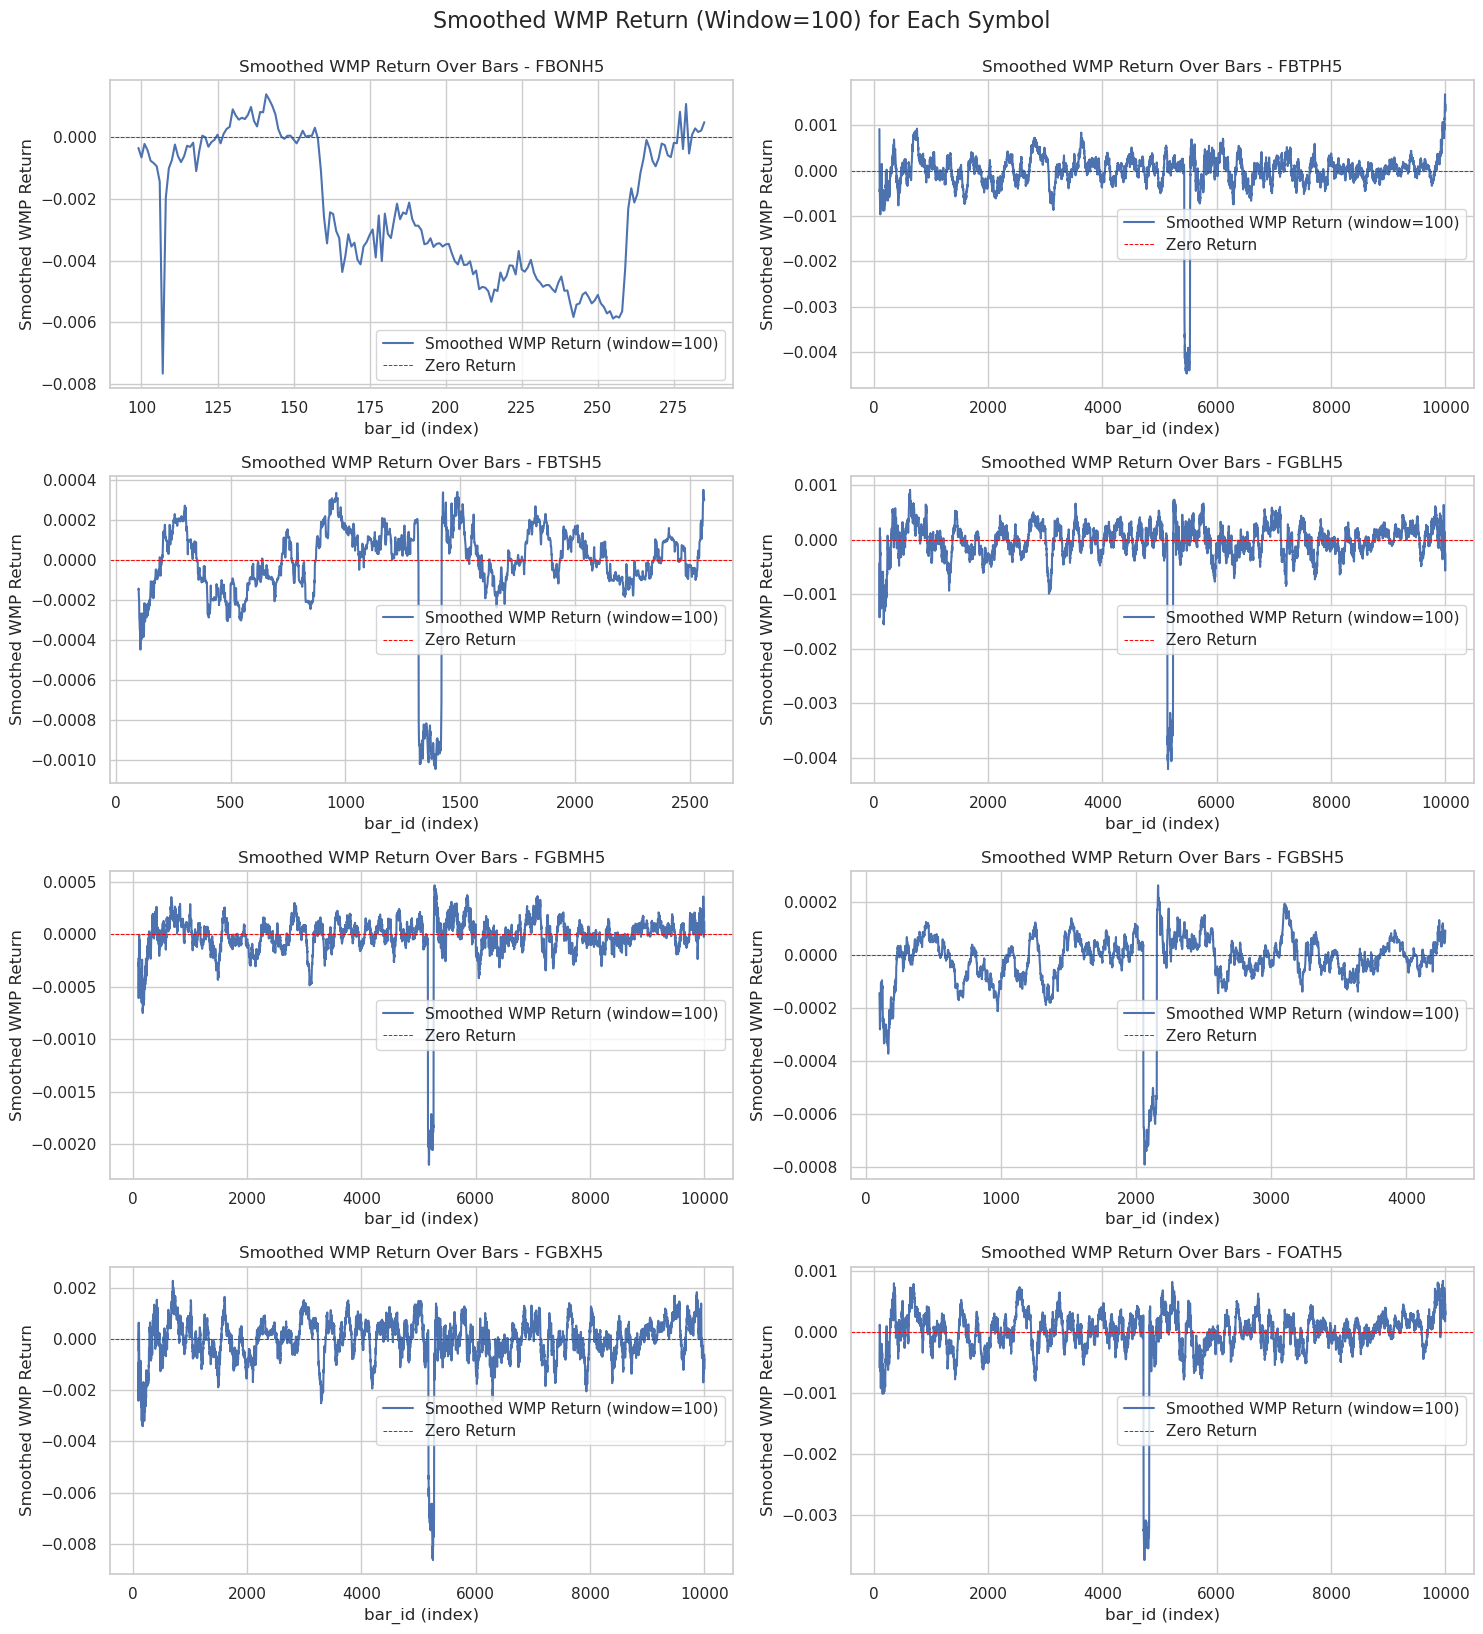

In [79]:
for sym, bars_df_orig in volume_bars_by_symbol.items():
    if bars_df_orig is not None and not bars_df_orig.empty:
        bars_df = bars_df_orig.copy() # Work on a copy
        if 'wmp_return' not in bars_df.columns:
            if 'last_wmp' in bars_df.columns and 'first_wmp' in bars_df.columns:
                bars_df.loc[:, 'wmp_return'] = bars_df['last_wmp'] - bars_df['first_wmp']
                volume_bars_by_symbol[sym] = bars_df # Update the dictionary with the df having the new column
            else:
                print(f"Warning: Cannot calculate 'wmp_return' for {sym} as 'last_wmp' or 'first_wmp' is missing.")
        # If wmp_return was already there, no need to reassign, but the copy is safe.
        elif bars_df is not bars_df_orig : # if a copy was made for other reasons but wmp_return existed
             volume_bars_by_symbol[sym] = bars_df


symbols = list(volume_bars_by_symbol.keys())
num_symbols = len(symbols)
num_rows = (num_symbols + 1) // 2  # Ensure enough rows, 2 plots per row

# Define the rolling window size for smoothing
rolling_window_size = 100

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows), squeeze=False) # Ensure axes is 2D
axes = axes.flatten()

for i, sym in enumerate(symbols):
    bars_df = volume_bars_by_symbol.get(sym) # Use .get() for safer access
    
    if bars_df is not None and not bars_df.empty and 'wmp_return' in bars_df.columns:
        smoothed_returns = bars_df['wmp_return'].rolling(window=rolling_window_size).mean()
        
        axes[i].plot(bars_df.index, smoothed_returns, label=f'Smoothed WMP Return (window={rolling_window_size})')
        axes[i].axhline(0, color='red', linestyle='--', linewidth=0.7, label='Zero Return')
        axes[i].set_title(f'Smoothed WMP Return Over Bars - {sym}')
        axes[i].set_xlabel('bar_id (index)')
        axes[i].set_ylabel('Smoothed WMP Return')
        axes[i].legend()
        axes[i].grid(True)
    else:
        axes[i].set_title(f'No/incomplete data for {sym}')
        axes[i].axis('off') # Turn off empty subplots

# Hide any unused subplots at the end
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f'Smoothed WMP Return (Window={rolling_window_size}) for Each Symbol', y=1.02, fontsize=16)
plt.show()

### Things to consider

* Filter volume bars with large duration. Ex : bar_duration_seconds < 120 ((e.g., > 99th percentile of durations for that symbol, or a fixed cap like 60-120 seconds if they occur during active trading hours))
* Filter snapshots activity. Ex : num_snapshots_in_bar < 768 (use quantile)
* Regarding WMP return, use thresholding for labeling. Ex : threshold = 0.0015; label = +1 if return > threshold, -1 if < -threshold, else 0

In [80]:
# bars_df = bars_df[bars_df['bar_duration_seconds'] < 120]

# def label_wmp_return(row, threshold=0.0015):
#     if row['wmp_return'] > threshold:
#         return 1
#     elif row['wmp_return'] < -threshold:
#         return -1
#     else:
#         return 0
# bars_df['label'] = bars_df.apply(label_wmp_return, axis=1)



In [81]:
def create_volume_bars_with_lob_features(
    df_symbol: pd.DataFrame,    
    nb_bars: int,
    activity_col_name: str = 'activity_volume',
    wmp_col_name: str = 'weighted_mid_price',
    time_col_name: str = 'time'
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generates volume bars and also returns full snapshot data with bar_id assignment.

    Args:
        symbol_df_with_activity (pd.DataFrame): DataFrame for a single symbol with activity.
        volume_threshold (float): Volume threshold to define each bar.
        activity_col_name (str): Column holding volume/activity per snapshot.
        wmp_col_name (str): Column with weighted mid-price.
        time_col_name (str): Datetime column for time ordering.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]:
            - volume_bars_df: Aggregated stats per volume bar.
            - snapshots_with_bars: Original snapshot data with assigned bar_id.
    """
    if df_symbol.empty or not nb_bars > 0:
        return pd.DataFrame(), pd.DataFrame()

    required_cols = [time_col_name, wmp_col_name, activity_col_name]
    if not all(col in df_symbol.columns for col in required_cols):
        print(f"Missing required columns: {required_cols}")
        return pd.DataFrame(), pd.DataFrame()

    # Ensure sorted by time
    data = df_symbol.sort_values(time_col_name).reset_index(drop=True)

    volume_threshold = data['cumulative_activity_volume'].max() // nb_bars
    print(f"Volume threshold: {volume_threshold}")
    
    data['bar_id'] = (data['cumulative_activity_volume'] // volume_threshold).astype(int)

    # Handle edge case: very first bar under threshold
    if data.loc[0, 'cumulative_activity_volume'] < volume_threshold:
        data.loc[data['bar_id'] == data.loc[0, 'bar_id'], 'bar_id'] = 0

    # Exclude partial last bar
    max_possible_bar_id = int(data['cumulative_activity_volume'].max() // volume_threshold) - 1
    if max_possible_bar_id < 0:
        return pd.DataFrame(), pd.DataFrame()

    data_full_bars = data[data['bar_id'] <= max_possible_bar_id].copy()

    if data_full_bars.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Aggregate bar-level statistics
    def aggregate_bar(bar_group):
        return pd.Series({
            'bar_start_time': bar_group[time_col_name].iloc[0],
            'bar_end_time': bar_group[time_col_name].iloc[-1],
            'num_snapshots_in_bar': len(bar_group),
            'actual_volume_in_bar': bar_group[activity_col_name].sum(),
            'mean_wmp': bar_group[wmp_col_name].mean(),
            'first_wmp': bar_group[wmp_col_name].iloc[0],
            'last_wmp': bar_group[wmp_col_name].iloc[-1],
            'min_wmp': bar_group[wmp_col_name].min(),
            'max_wmp': bar_group[wmp_col_name].max()
        })

    volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)
    volume_bars_df['bar_duration_seconds'] = (
        volume_bars_df['bar_end_time'] - volume_bars_df['bar_start_time']
    ).dt.total_seconds()

    # Final cleanup and return
    return volume_bars_df.reset_index(), data_full_bars.reset_index(drop=True)

In [82]:
def create_volume_bars_with_lob_features(
    df_symbol: pd.DataFrame,    
    nb_bars: int,
    activity_col_name: str = 'activity_volume',
    wmp_col_name: str = 'weighted_mid_price',
    time_col_name: str = 'time'
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    # Computer volume features
    df_symbol['activity_volume'] = df_symbol['L1_bid_size'] + df_symbol['L1_ask_size']
    df_symbol['activity_volume'] = df_symbol['activity_volume'].fillna(0)
    df_symbol['activity_volume_ma'] = df_symbol['activity_volume'].rolling(window=10000).mean()
    df_symbol['cumulative_activity_volume'] = df_symbol['activity_volume'].cumsum()

    # Check if required columns are present
    required_cols = [time_col_name, wmp_col_name, activity_col_name]
    if not all(col in df_symbol.columns for col in required_cols):
        print(f"Missing required columns: {required_cols}")
        return pd.DataFrame(), pd.DataFrame()
    
    # Ensure sorted by time
    data = df_symbol.sort_values(time_col_name).reset_index(drop=True)

    volume_threshold = data['cumulative_activity_volume'].max() // nb_bars
    print(f"Volume threshold: {volume_threshold}")

    data['bar_id'] = (data['cumulative_activity_volume'] // volume_threshold).astype(int)

    # Handle edge case: very first bar under threshold
    if data.loc[0, 'cumulative_activity_volume'] < volume_threshold:
        data.loc[data['bar_id'] == data.loc[0, 'bar_id'], 'bar_id'] = 0

    # Exclude partial last bar
    max_possible_bar_id = int(data['cumulative_activity_volume'].max() // volume_threshold) - 1
    data_full_bars = data[data['bar_id'] <= max_possible_bar_id].copy()

    # Keep lob features
    level_cols = [col for col in data_full_bars.columns if col.startswith('L')]
    lob_features = ['spread', 'obi_L1', 'cum_bid_vol_10','cum_ask_vol_10', 
                    'depth_imbalance_10', 'liquidity_impact_bid',
                    'liquidity_impact_ask']
    
    total_cols = level_cols + lob_features

    # Drop other columns
    cols_to_drop = ['exch_time', 'exchange', 'first_sequence_number',
        'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
        'first_time', 'first_exch_time', 'event_id']
    
    data_full_bars = data_full_bars.drop(columns=cols_to_drop)

    def aggregate_bar(bar_group):

        results = {
            'bar_start_time': bar_group[time_col_name].iloc[0],
            'bar_end_time': bar_group[time_col_name].iloc[-1],
            'num_snapshots_in_bar': len(bar_group),
            'actual_volume_in_bar': bar_group[activity_col_name].sum(),
            'mean_wmp': bar_group[wmp_col_name].mean(),
            'first_wmp': bar_group[wmp_col_name].iloc[0],
            'last_wmp': bar_group[wmp_col_name].iloc[-1],
            'min_wmp': bar_group[wmp_col_name].min(),
            'max_wmp': bar_group[wmp_col_name].max()
        }

        for col in total_cols:
            results[f"{col}_mean"] = bar_group[col].mean()
            results[f"{col}_sum"] = bar_group[col].sum()
            results[f"{col}_min"] = bar_group[col].min()
            results[f"{col}_max"] = bar_group[col].max()
            results[f"{col}_std"] = bar_group[col].std()
            results[f"{col}_median"] = bar_group[col].median()
            
        return pd.Series(results)
    
    volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)
    volume_bars_df['bar_duration_seconds'] = (
        volume_bars_df['bar_end_time'] - volume_bars_df['bar_start_time']
    ).dt.total_seconds()

    return volume_bars_df.reset_index(), data_full_bars.reset_index(drop=True)

In [83]:
df_symbol = df[df['sym'] == 'FOATH5'].copy()

df_symbol['activity_volume'] = df_symbol['L1_bid_size'] + df_symbol['L1_ask_size']
df_symbol['activity_volume'] = df_symbol['activity_volume'].fillna(0)
# Create moving average of activity volume
df_symbol['activity_volume_ma'] = df_symbol['activity_volume'].rolling(window=10000).mean()
# Create cumulative activity volume
df_symbol['cumulative_activity_volume'] = df_symbol['activity_volume'].cumsum()
# Create volume delta column
df_symbol['volume_delta'] = df_symbol['activity_volume'].diff()

In [84]:
df_symbol[['L1_bid_size', 'L1_ask_size', 'activity_volume', 'activity_volume_ma', 'cumulative_activity_volume', 'volume_delta']].head()

,L1_bid_size,L1_ask_size,activity_volume,activity_volume_ma,cumulative_activity_volume,volume_delta
122,18.0,27.0,45.0,NaN,45.0,NaN
123,18.0,33.0,51.0,NaN,96.0,6.0
124,18.0,33.0,51.0,NaN,147.0,0.0
125,18.0,36.0,54.0,NaN,201.0,3.0
126,18.0,15.0,33.0,NaN,234.0,-21.0


In [85]:
df_symbol.shape

(2700417, 85)

In [86]:
nb_bars = 10000
time_col_name, wmp_col_name, activity_col_name = 'time', 'weighted_mid_price', 'activity_volume'

if df_symbol.empty or not nb_bars > 0:
    raise ValueError("DataFrame is empty or number of bars is not greater than zero.")

required_cols = [time_col_name, wmp_col_name, activity_col_name]
if not all(col in df_symbol.columns for col in required_cols):
    print(f"Missing required columns: {required_cols}")
    raise ValueError("Missing required columns.")

# Ensure sorted by time
data = df_symbol.sort_values(time_col_name).reset_index(drop=True)

volume_threshold = data['cumulative_activity_volume'].max() // nb_bars
print(f"Volume threshold: {volume_threshold}")

data['bar_id'] = (data['cumulative_activity_volume'] // volume_threshold).astype(int)

# Handle edge case: very first bar under threshold
if data.loc[0, 'cumulative_activity_volume'] < volume_threshold:
    data.loc[data['bar_id'] == data.loc[0, 'bar_id'], 'bar_id'] = 0

# Exclude partial last bar
max_possible_bar_id = int(data['cumulative_activity_volume'].max() // volume_threshold) - 1

data_full_bars = data[data['bar_id'] <= max_possible_bar_id].copy()

Volume threshold: 106899.0


In [87]:
data_full_bars.columns

Index(['time', 'sym', 'exch_time', 'exchange', 'first_sequence_number',
       'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
       'first_time', 'first_exch_time', 'event_id', 'L1_bid_price',
       'L1_bid_size', 'L1_bid_no', 'L1_ask_price', 'L1_ask_size', 'L1_ask_no',
       'L2_bid_price', 'L2_bid_size', 'L2_bid_no', 'L2_ask_price',
       'L2_ask_size', 'L2_ask_no', 'L3_bid_price', 'L3_bid_size', 'L3_bid_no',
       'L3_ask_price', 'L3_ask_size', 'L3_ask_no', 'L4_bid_price',
       'L4_bid_size', 'L4_bid_no', 'L4_ask_price', 'L4_ask_size', 'L4_ask_no',
       'L5_bid_price', 'L5_bid_size', 'L5_bid_no', 'L5_ask_price',
       'L5_ask_size', 'L5_ask_no', 'L6_bid_price', 'L6_bid_size', 'L6_bid_no',
       'L6_ask_price', 'L6_ask_size', 'L6_ask_no', 'L7_bid_price',
       'L7_bid_size', 'L7_bid_no', 'L7_ask_price', 'L7_ask_size', 'L7_ask_no',
       'L8_bid_price', 'L8_bid_size', 'L8_bid_no', 'L8_ask_price',
       'L8_ask_size', 'L8_ask_no', 'L9_bid_price', 'L9_b

In [88]:
level_cols = [col for col in data_full_bars.columns if col.startswith('L')]
lob_features = ['spread', 'obi_L1', 'cum_bid_vol_10',
       'cum_ask_vol_10', 'depth_imbalance_10', 'liquidity_impact_bid',
       'liquidity_impact_ask']
total_cols = level_cols + lob_features

In [89]:
cols_to_drop = ['exch_time', 'exchange', 'first_sequence_number',
       'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
       'first_time', 'first_exch_time', 'event_id']

data_full_bars = data_full_bars.drop(columns=cols_to_drop)

In [90]:
data_full_bars.columns

Index(['time', 'sym', 'L1_bid_price', 'L1_bid_size', 'L1_bid_no',
       'L1_ask_price', 'L1_ask_size', 'L1_ask_no', 'L2_bid_price',
       'L2_bid_size', 'L2_bid_no', 'L2_ask_price', 'L2_ask_size', 'L2_ask_no',
       'L3_bid_price', 'L3_bid_size', 'L3_bid_no', 'L3_ask_price',
       'L3_ask_size', 'L3_ask_no', 'L4_bid_price', 'L4_bid_size', 'L4_bid_no',
       'L4_ask_price', 'L4_ask_size', 'L4_ask_no', 'L5_bid_price',
       'L5_bid_size', 'L5_bid_no', 'L5_ask_price', 'L5_ask_size', 'L5_ask_no',
       'L6_bid_price', 'L6_bid_size', 'L6_bid_no', 'L6_ask_price',
       'L6_ask_size', 'L6_ask_no', 'L7_bid_price', 'L7_bid_size', 'L7_bid_no',
       'L7_ask_price', 'L7_ask_size', 'L7_ask_no', 'L8_bid_price',
       'L8_bid_size', 'L8_bid_no', 'L8_ask_price', 'L8_ask_size', 'L8_ask_no',
       'L9_bid_price', 'L9_bid_size', 'L9_bid_no', 'L9_ask_price',
       'L9_ask_size', 'L9_ask_no', 'L10_bid_price', 'L10_bid_size',
       'L10_bid_no', 'L10_ask_price', 'L10_ask_size', 'L10_ask_no', '

In [91]:
def aggregate_bar(bar_group):

    results = {
        'bar_start_time': bar_group[time_col_name].iloc[0],
        'bar_end_time': bar_group[time_col_name].iloc[-1],
        'num_snapshots_in_bar': len(bar_group),
        'actual_volume_in_bar': bar_group[activity_col_name].sum(),
        'mean_wmp': bar_group[wmp_col_name].mean(),
        'first_wmp': bar_group[wmp_col_name].iloc[0],
        'last_wmp': bar_group[wmp_col_name].iloc[-1],
        'min_wmp': bar_group[wmp_col_name].min(),
        'max_wmp': bar_group[wmp_col_name].max()
    }

    for col in total_cols:
        results[f"{col}_mean"] = bar_group[col].mean()
        results[f"{col}_sum"] = bar_group[col].sum()
        results[f"{col}_min"] = bar_group[col].min()
        results[f"{col}_max"] = bar_group[col].max()
        results[f"{col}_std"] = bar_group[col].std()
        results[f"{col}_median"] = bar_group[col].median()
        
    return pd.Series(results)

In [92]:
volume_bars_df = data_full_bars.groupby('bar_id').apply(aggregate_bar)
volume_bars_df['bar_duration_seconds'] = (
    volume_bars_df['bar_end_time'] - volume_bars_df['bar_start_time']
).dt.total_seconds()

KeyboardInterrupt: 

In [162]:
volume_bars_df.reset_index()

,bar_id,bar_start_time,bar_end_time,num_snapshots_in_bar,actual_volume_in_bar,mean_wmp,first_wmp,last_wmp,min_wmp,max_wmp,...,liquidity_impact_bid_max,liquidity_impact_bid_std,liquidity_impact_bid_median,liquidity_impact_ask_mean,liquidity_impact_ask_sum,liquidity_impact_ask_min,liquidity_impact_ask_max,liquidity_impact_ask_std,liquidity_impact_ask_median,bar_duration_seconds
0,0,2025-02-12 00:15:01.084543637,2025-02-12 00:39:33.195868432,1801,106787.0,123.742623,123.764000,123.764174,123.710227,123.770526,...,0.02,2.356368e-04,0.01,0.01,18.01,0.01,0.01,6.411926e-15,0.01,1472.111325
1,1,2025-02-12 00:39:33.344796277,2025-02-12 02:04:14.721097752,2431,106987.0,123.776791,123.764174,123.744167,123.738182,123.806207,...,0.01,6.776129e-15,0.01,0.01,24.31,0.01,0.01,6.574713e-15,0.01,5081.376301
2,2,2025-02-12 02:04:14.723255522,2025-02-12 03:31:40.136179469,2701,106846.0,123.737456,123.744815,123.719872,123.697470,123.759545,...,0.01,7.039383e-15,0.01,0.01,27.01,0.01,0.01,7.001552e-15,0.01,5245.412924
3,3,2025-02-12 03:31:40.136201418,2025-02-12 04:59:13.307641632,2448,106964.0,123.685399,123.719872,123.698148,123.650263,123.727111,...,0.01,6.154738e-15,0.01,0.01,24.48,0.01,0.01,6.512548e-15,0.01,5253.171440
4,4,2025-02-12 04:59:13.308819547,2025-02-12 06:42:12.319527857,2503,106888.0,123.688620,123.698148,123.668125,123.663333,123.709500,...,0.01,7.106229e-15,0.01,0.01,25.03,0.01,0.01,6.782973e-15,0.01,6179.010708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,2025-02-12 19:52:30.100260525,2025-02-12 19:55:24.048363320,606,106850.0,123.543587,123.553034,123.537785,123.535775,123.553034,...,0.01,4.017970e-15,0.01,0.01,6.06,0.01,0.01,7.071528e-15,0.01,173.948103
9996,9996,2025-02-12 19:55:24.048412188,2025-02-12 19:56:43.545509293,511,106840.0,123.547707,123.537532,123.554315,123.537296,123.554315,...,0.01,5.685732e-15,0.01,0.01,5.11,0.01,0.01,7.003684e-15,0.01,79.497097
9997,9997,2025-02-12 19:56:43.545565955,2025-02-12 19:59:48.167816095,635,106976.0,123.547400,123.554315,123.544125,123.537169,123.558525,...,0.01,6.420309e-15,0.01,0.01,6.35,0.01,0.01,6.788749e-15,0.01,184.622250
9998,9998,2025-02-12 19:59:48.167820431,2025-02-12 20:02:44.436288453,711,106937.0,123.542282,123.544125,123.538201,123.536810,123.546265,...,0.01,0.000000e+00,0.01,0.01,7.11,0.01,0.01,6.324115e-15,0.01,176.268468


In [164]:
volume_bars_df.columns.tolist()

['bar_start_time',
 'bar_end_time',
 'num_snapshots_in_bar',
 'actual_volume_in_bar',
 'mean_wmp',
 'first_wmp',
 'last_wmp',
 'min_wmp',
 'max_wmp',
 'L1_bid_price_mean',
 'L1_bid_price_sum',
 'L1_bid_price_min',
 'L1_bid_price_max',
 'L1_bid_price_std',
 'L1_bid_price_median',
 'L1_bid_size_mean',
 'L1_bid_size_sum',
 'L1_bid_size_min',
 'L1_bid_size_max',
 'L1_bid_size_std',
 'L1_bid_size_median',
 'L1_bid_no_mean',
 'L1_bid_no_sum',
 'L1_bid_no_min',
 'L1_bid_no_max',
 'L1_bid_no_std',
 'L1_bid_no_median',
 'L1_ask_price_mean',
 'L1_ask_price_sum',
 'L1_ask_price_min',
 'L1_ask_price_max',
 'L1_ask_price_std',
 'L1_ask_price_median',
 'L1_ask_size_mean',
 'L1_ask_size_sum',
 'L1_ask_size_min',
 'L1_ask_size_max',
 'L1_ask_size_std',
 'L1_ask_size_median',
 'L1_ask_no_mean',
 'L1_ask_no_sum',
 'L1_ask_no_min',
 'L1_ask_no_max',
 'L1_ask_no_std',
 'L1_ask_no_median',
 'L2_bid_price_mean',
 'L2_bid_price_sum',
 'L2_bid_price_min',
 'L2_bid_price_max',
 'L2_bid_price_std',
 'L2_bid_pri

In [98]:
df2['L1_bid_no'][:10]

0     2.0
3     2.0
5     3.0
6     4.0
7     4.0
8     4.0
9     4.0
10    4.0
12    5.0
13    5.0
Name: L1_bid_no, dtype: float64

In [99]:
df2['L1_ask_no']

0            6.0
3            6.0
5            6.0
6            6.0
7            6.0
            ... 
16999995    31.0
16999996    31.0
16999997    31.0
16999998    31.0
16999999    31.0
Name: L1_ask_no, Length: 16990559, dtype: float64

In [88]:
example_symbol = 'FGBLH5' # Choose a symbol you want to analyze
if example_symbol in symbols_data_map:
    df_symbol_specific = symbols_data_map[example_symbol].sort_values('time').reset_index(drop=True)
    print(f"Data for symbol '{example_symbol}':")
    print(df_symbol_specific.head())
    print(f"Shape of data for '{example_symbol}': {df_symbol_specific.shape}")
else:
    print(f"Symbol '{example_symbol}' not found in df_sampled.")
    df_symbol_specific = pd.DataFrame() # Assign empty df to avoid errors later if symbol not found

Data for symbol 'FGBLH5':
                           time     sym            exch_time    exchange  \
0 2025-02-12 00:16:36.973883263  FGBLH5  1739319396973879708  EUREX-EOBI   
1 2025-02-12 00:16:36.993988081  FGBLH5  1739319396993984422  EUREX-EOBI   
2 2025-02-12 00:16:37.024148136  FGBLH5  1739319397024142196  EUREX-EOBI   
3 2025-02-12 00:16:37.044250443  FGBLH5  1739319397044246824  EUREX-EOBI   
4 2025-02-12 00:16:37.064355485  FGBLH5  1739319397064351411  EUREX-EOBI   

   first_sequence_number  last_sequence_number  first_sym_sequence  \
0                      1                     1                   1   
1                      1                     1                   1   
2                      1                     1                   1   
3                      1                     1                   1   
4                      1                     1                   1   

   last_sym_sequence  first_time  first_exch_time  ...   obi_L1  \
0               6188         

In [89]:
df.columns

Index(['time', 'sym', 'exch_time', 'exchange', 'first_sequence_number',
       'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
       'first_time', 'first_exch_time', 'event_id', 'L1_bid_price',
       'L1_bid_size', 'L1_bid_no', 'L1_ask_price', 'L1_ask_size', 'L1_ask_no',
       'L2_bid_price', 'L2_bid_size', 'L2_bid_no', 'L2_ask_price',
       'L2_ask_size', 'L2_ask_no', 'L3_bid_price', 'L3_bid_size', 'L3_bid_no',
       'L3_ask_price', 'L3_ask_size', 'L3_ask_no', 'L4_bid_price',
       'L4_bid_size', 'L4_bid_no', 'L4_ask_price', 'L4_ask_size', 'L4_ask_no',
       'L5_bid_price', 'L5_bid_size', 'L5_bid_no', 'L5_ask_price',
       'L5_ask_size', 'L5_ask_no', 'L6_bid_price', 'L6_bid_size', 'L6_bid_no',
       'L6_ask_price', 'L6_ask_size', 'L6_ask_no', 'L7_bid_price',
       'L7_bid_size', 'L7_bid_no', 'L7_ask_price', 'L7_ask_size', 'L7_ask_no',
       'L8_bid_price', 'L8_bid_size', 'L8_bid_no', 'L8_ask_price',
       'L8_ask_size', 'L8_ask_no', 'L9_bid_price', 'L9_b

In [90]:
example_symbol = 'FGBLH5' # Choose a symbol you want to analyze

if example_symbol in symbols_data_map:
    df_symbol_specific = symbols_data_map[example_symbol].sort_values('time').reset_index(drop=True)
    
    if 'L1_bid_size' in df_symbol_specific.columns and 'L1_ask_size' in df_symbol_specific.columns:
        df_symbol_specific['snapshot_activity_volume'] = df_symbol_specific['L1_bid_size'] + df_symbol_specific['L1_ask_size']
        # Handle potential NaNs in the activity volume if L1 sizes can be NaN
        df_symbol_specific['snapshot_activity_volume'] = df_symbol_specific['snapshot_activity_volume'].fillna(0)
        print(f"Added 'snapshot_activity_volume' column for symbol '{example_symbol}'.")
        print(df_symbol_specific[['time', 'L1_bid_size', 'L1_ask_size', 'snapshot_activity_volume', 'weighted_mid_price']].head())
    else:
        print(f"Error: 'L1_bid_size' or 'L1_ask_size' not found in columns for {example_symbol}. Cannot create volume bars.")
        df_symbol_specific = pd.DataFrame() # Make it empty to skip analysis
else:
    print(f"Symbol '{example_symbol}' not found in df_sampled.")
    df_symbol_specific = pd.DataFrame()

KeyboardInterrupt: 

In [85]:
# --- 2. Function to create Volume Bars ---
def create_volume_bars(symbol_df_with_activity: pd.DataFrame,
                       volume_threshold: float,
                       activity_col_name: str = 'snapshot_activity_volume') -> pd.DataFrame:
    """
    Generates aggregated bars based on accumulated 'activity_volume' reaching a threshold.

    Args:
        symbol_df_with_activity (pd.DataFrame): DataFrame for a single symbol, sorted by 'time'.
                                                Must contain 'time', 'weighted_mid_price',
                                                and the specified 'activity_col_name'.
        volume_threshold (float): The cumulative activity/volume that defines one bar.
        activity_col_name (str): Name of the column holding the activity/volume for each snapshot.

    Returns:
        pd.DataFrame: DataFrame where each row is a volume bar with aggregated info.
    """
    if symbol_df_with_activity.empty or not volume_threshold > 0:
        return pd.DataFrame()
    if activity_col_name not in symbol_df_with_activity.columns:
        print(f"Error: Activity column '{activity_col_name}' not found in DataFrame.")
        return pd.DataFrame()

    # Ensure sorted by time
    data = symbol_df_with_activity.sort_values('time').reset_index(drop=True)
    
    volume_bars_data = []
    current_bar_ticks_indices = []
    cumulative_volume_in_bar = 0.0
    bar_id_counter = 0

    for idx, row in data.iterrows():
        current_bar_ticks_indices.append(idx)
        cumulative_volume_in_bar += row[activity_col_name]

        if cumulative_volume_in_bar >= volume_threshold:
            bar_slice = data.iloc[current_bar_ticks_indices]
            
            bar_start_time = bar_slice['time'].iloc[0]
            bar_end_time = bar_slice['time'].iloc[-1]
            bar_duration = bar_end_time - bar_start_time
            
            mean_wmp = bar_slice['weighted_mid_price'].mean()
            first_wmp = bar_slice['weighted_mid_price'].iloc[0]
            last_wmp = bar_slice['weighted_mid_price'].iloc[-1]
            min_wmp = bar_slice['weighted_mid_price'].min()
            max_wmp = bar_slice['weighted_mid_price'].max()
            
            volume_bars_data.append({
                'bar_id': bar_id_counter,
                'bar_start_time': bar_start_time,
                'bar_end_time': bar_end_time,
                'bar_duration_seconds': bar_duration.total_seconds(),
                'num_snapshots_in_bar': len(bar_slice),
                'actual_volume_in_bar': cumulative_volume_in_bar, # Total accumulated volume for this bar
                'mean_wmp': mean_wmp,
                'first_wmp': first_wmp,
                'last_wmp': last_wmp,
                'min_wmp': min_wmp,
                'max_wmp': max_wmp
            })
            
            bar_id_counter += 1
            current_bar_ticks_indices = []
            cumulative_volume_in_bar = 0.0 # Reset for the next bar

    # Handle any remaining ticks that didn't form a full bar (optional)
    # For simplicity, we'll ignore them here, but you could process them as a partial bar.
    # if current_bar_ticks_indices:
    #     # Process the last partial bar similarly if desired
    #     pass
        
    return pd.DataFrame(volume_bars_data)

In [86]:
# --- 3. Explore Volume Bars for a specific symbol ---
if not df_symbol_specific.empty and 'snapshot_activity_volume' in df_symbol_specific.columns:
    # Estimate a starting point for volume_threshold.
    # For example, aim for roughly N bars per hour of trading.
    # If avg activity per second is X, and a bar is Y seconds, threshold = X*Y.
    # Or, calculate total activity for the symbol and divide by desired number of bars.
    
    total_activity_for_symbol = df_symbol_specific['snapshot_activity_volume'].sum()
    desired_num_bars_approx = 5000 # Adjust this based on your data and desired granularity
    
    if total_activity_for_symbol > 0 and desired_num_bars_approx > 0 :
        estimated_volume_threshold = total_activity_for_symbol / desired_num_bars_approx
        print(f"\nTotal activity for '{example_symbol}': {total_activity_for_symbol:,.0f}")
        print(f"Estimated volume_threshold for ~{desired_num_bars_approx} bars: {estimated_volume_threshold:,.0f}")

        volume_thresholds_to_test = [
            estimated_volume_threshold * 0.5, 
            estimated_volume_threshold, 
            estimated_volume_threshold * 2.0
        ]
        # Ensure thresholds are somewhat reasonable (e.g., not too small compared to individual snapshot volumes)
        min_reasonable_threshold = df_symbol_specific['snapshot_activity_volume'].quantile(0.75) * 10 # e.g. 10 times a typical snapshot's activity
        volume_thresholds_to_test = [max(vt, min_reasonable_threshold) for vt in volume_thresholds_to_test]
        volume_thresholds_to_test = sorted(list(set(vt for vt in volume_thresholds_to_test if vt > 0))) # Unique, positive
        
        print(f"Will test volume_thresholds: {[f'{vt:,.0f}' for vt in volume_thresholds_to_test]}")

    else:
        print("Could not estimate volume thresholds due to zero total activity or zero desired bars.")
        volume_thresholds_to_test = [100000, 500000] # Fallback, adjust based on your data's scale


    for vol_thresh in volume_thresholds_to_test:
        print(f"\n--- Analyzing for Symbol '{example_symbol}' with Volume Threshold: {vol_thresh:,.0f} ---")
        
        volume_bars_df = create_volume_bars(df_symbol_specific, volume_threshold=vol_thresh)

        print(f"volume_bars_df.shape: {volume_bars_df.shape}")
        
        if volume_bars_df.empty:
            print(f"No volume bars generated for threshold {vol_thresh:,.0f}.")
            continue
            
        print(f"Generated {len(volume_bars_df)} volume bars.")
        print(volume_bars_df.head())

        # A. Calculate Statistics
        print("\nStatistics for Bar Durations (seconds):")
        print(volume_bars_df['bar_duration_seconds'].describe())
        
        print("\nStatistics for Number of Snapshots in Bar:")
        print(volume_bars_df['num_snapshots_in_bar'].describe())
        
        print("\nStatistics for Actual Volume in Bar:")
        print(volume_bars_df['actual_volume_in_bar'].describe())


        # B. Visualizations
        plt.figure(figsize=(10, 6))
        sns.histplot(volume_bars_df['bar_duration_seconds'], bins=50, kde=False)
        plt.title(f'Histogram of Bar Durations (Symbol: {example_symbol}, Vol Thresh: {vol_thresh:,.0f})')
        plt.xlabel('Bar Duration (seconds)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.7)
        plt.show()

        plt.figure(figsize=(15, 7))
        plt.plot(volume_bars_df['bar_end_time'], volume_bars_df['mean_wmp'], marker='.', linestyle='-', label=f'Mean WMP (Vol Thresh: {vol_thresh:,.0f})')
        plt.title(f'Mean WMP in Volume Bars (Symbol: {example_symbol}, Vol Thresh: {vol_thresh:,.0f})')
        plt.xlabel('Time')
        plt.ylabel('Mean WMP')
        plt.legend()
        plt.grid(True)
        plt.show()

        volume_bars_df['wmp_return'] = volume_bars_df['mean_wmp'].pct_change()
        plt.figure(figsize=(10, 6))
        sns.histplot(volume_bars_df['wmp_return'].dropna(), bins=100, kde=True)
        plt.title(f'Histogram of WMP Returns between Volume Bars (Symbol: {example_symbol}, Vol Thresh: {vol_thresh:,.0f})')
        plt.xlabel('WMP Return')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.7)
        plt.show()
        
        print("\nStatistics for WMP Returns between Bars:")
        print(volume_bars_df['wmp_return'].describe())
else:
    print(f"Skipping volume bar analysis as data for '{example_symbol}' is empty or 'snapshot_activity_volume' column is missing.")


Total activity for 'FGBLH5': 4,208,091,783
Estimated volume_threshold for ~5000 bars: 841,618
Will test volume_thresholds: ['420,809', '841,618', '1,683,237']

--- Analyzing for Symbol 'FGBLH5' with Volume Threshold: 420,809 ---


KeyboardInterrupt: 

## Machine Learning

In [ ]:
def prepare_initial_dataframe(df: pd.DataFrame, n_rows: int = None) -> pd.DataFrame:
    """
    Copy and optionally subset the original dataframe, then drop unused columns.
    """
    df_clean = df.copy()
    if n_rows:
        df_clean = df_clean.head(n_rows)

    columns_to_remove = [
        'exch_time', 'exchange', 'first_sequence_number',
        'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence',
        'first_time', 'first_exch_time', 'event_id'
    ]

    df_clean.drop(columns=columns_to_remove, inplace=True, errors='ignore')
    return df_clean


def compute_temporal_features(df: pd.DataFrame, resample_freq='1s') -> pd.DataFrame:
    """
    Compute temporal features such as rolling mean, std, price deltas, etc.
    Grouped per symbol and resampled to uniform frequency.
    """
    features_to_compute = [
        'L1_bid_price', 'L1_ask_price', 'spread', 'obi_L1',
        'depth_imbalance_10', 'weighted_mid_price'
    ]

    df_temp = []
    for sym, group in df.groupby('sym'):
        group = group.set_index('time').sort_index()
        group = group.resample(resample_freq).ffill().dropna()

        for col in features_to_compute:
            # Rolling stats
            group[f'{col}_mean_10'] = group[col].rolling(window=10).mean()
            group[f'{col}_std_10'] = group[col].rolling(window=10).std()
            group[f'{col}_zscore_10'] = (group[col] - group[f'{col}_mean_10']) / group[f'{col}_std_10']
            group[f'{col}_delta_1'] = group[col].diff(1)
            group[f'{col}_delta_5'] = group[col].diff(5)

        group['sym'] = sym
        df_temp.append(group)

    df_result = pd.concat(df_temp)
    df_result = df_result.dropna()
    return df_result.reset_index()


def resample_lob_features(df: pd.DataFrame, resample_freq='1s') -> pd.DataFrame:
    """
    Resample LOB features and engineered features at a uniform frequency per symbol.
    """
    df_resampled = []

    for sym, group in df.groupby('sym'):
        group = group.set_index('time').sort_index()

        # Define all non-categorical columns except 'sym'
        cols_to_resample = [col for col in group.columns if col != 'sym']

        # Use mean for all columns except 'weighted_mid_price' which uses last
        agg_dict = {col: ('last' if col == 'weighted_mid_price' else 'mean') for col in cols_to_resample}

        group_resampled = group.resample(resample_freq).agg(agg_dict)
        group_resampled['sym'] = sym
        df_resampled.append(group_resampled)

    df_final = pd.concat(df_resampled).sort_index()
    df_final = df_final.dropna()
    return df_final.reset_index()


def generate_windowed_features(df: pd.DataFrame, input_window: int = 100) -> pd.DataFrame:
    """
    Generate windowed statistical features per symbol for model training,
    and keep the weighted mid price for label generation.

    Parameters:
    - df: resampled LOB dataframe with time, sym, weighted_mid_price
    - input_window: number of seconds in window

    Returns:
    - X: design matrix with features and auxiliary columns: time, sym, wmp_last
    """
    feature_cols = [
        col for col in df.columns 
        if col not in ['weighted_mid_price', 'sym', 'time']
        and not np.issubdtype(df[col].dtype, np.datetime64)
    ]

    X_rows = []
    X_index = []
    symbols = []
    wmps = []

    for sym, group in tqdm(df.groupby('sym')):
        group = group.sort_values('time')

        for i in range(input_window, len(group)):
            window = group.iloc[i - input_window:i]
            feature_vector = []

            for col in feature_cols:
                vals = window[col].values
                feature_vector += [
                    np.mean(vals),
                    np.std(vals),
                    np.min(vals),
                    np.max(vals),
                    vals[-1]
                ]

            X_rows.append(feature_vector)
            X_index.append(group.iloc[i]['time'])
            symbols.append(sym)

            # ➕ Ajouter WMP dernière valeur de la fenêtre
            wmps.append(window['weighted_mid_price'].values[-1])

    # Construction du DataFrame final
    X = pd.DataFrame(X_rows)
    X.columns = [f"{col}_{stat}" for col in feature_cols for stat in ['mean', 'std', 'min', 'max', 'last']]
    X['time'] = X_index
    X['sym'] = symbols
    X['weighted_mid_price'] = wmps  # pour la génération des labels

    return X


def generate_classification_labels_deeplob(X: pd.DataFrame, df_final: pd.DataFrame, k: int = 10, alpha: float = 0.00001):
    """
    Generate classification labels using the DeepLOB-style method.
    
    Parameters:
    - X: windowed features DataFrame
    - df_final: full resampled DataFrame containing weighted_mid_price and sym
    - k: prediction horizon in seconds
    - alpha: threshold to ignore small price changes

    Returns:
    - X: updated DataFrame with 'label_deeplob'
    - y: classification target as integer
    - X_features: final matrix without time, sym, label
    """
   # Extract the relevant columns
    wmp_all = df_final[['weighted_mid_price', 'sym']].copy()

    # Ensure 'time' is in the columns (rename index if necessary)
    if wmp_all.index.name != 'time':
        wmp_all = wmp_all.reset_index().rename(columns={'index': 'time'})

    # Set MultiIndex (sym, time)
    wmp_all = wmp_all.set_index(['sym', 'time'])

    labels = []

    for i in tqdm(range(len(X))):
        row = X.iloc[i]
        t = row['time']
        sym = row['sym']

        try:
            current_price = wmp_all.loc[(sym, t), 'weighted_mid_price']
        except KeyError:
            labels.append(np.nan)
            continue

        future_times = [t + pd.Timedelta(seconds=s) for s in range(k)]
        try:
            future_prices = [wmp_all.loc[(sym, ft), 'weighted_mid_price'] for ft in future_times]
            if any(pd.isna(future_prices)):
                labels.append(np.nan)
                continue
        except KeyError:
            labels.append(np.nan)
            continue

        mean_future = np.mean(future_prices)
        rel_change = (mean_future - current_price) / current_price

        if rel_change > alpha:
            label = 1
        elif rel_change < -alpha:
            label = -1
        else:
            label = 0

        labels.append(label)

    X = X.copy()
    X['label_deeplob'] = labels
    X = X.dropna(subset=['label_deeplob'])

    y = X['label_deeplob'].astype(int)
    X_features = X.drop(columns=['time', 'sym', 'label_deeplob'] + [col for col in X.columns if col.startswith('label_t+')])

    print("\nDistribution des labels DeepLOB:")
    print(y.value_counts(normalize=True).sort_index())

    return X, y, X_features

In [ ]:
df_small = prepare_initial_dataframe(df_sampled)
df_temp = compute_temporal_features(df_small)
df_resampled = resample_lob_features(df_temp)
X = generate_windowed_features(df_resampled, input_window=100)

### Under-sampling

In [39]:
ratio = 10
df_sampled = df.iloc[::ratio].copy()

In [42]:
df.shape, df_sampled.shape

((47404067, 81), (4740407, 81))

In [43]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import List, Dict, Tuple

def resample_lob_data(df: pd.DataFrame, resample_freq: str = '1s') -> pd.DataFrame:
    """
    Resamples the LOB data to a uniform frequency per symbol.

    Aggregates features using 'mean' for all numeric columns, including
    'weighted_mid_price'.

    Args:
        df: Input DataFrame containing LOB data and calculated features like WMP.
            Must include 'time', 'sym', 'weighted_mid_price', and other feature columns.
        resample_freq: The resampling frequency (e.g., '1s', '100ms').

    Returns:
        Resampled DataFrame with 'time' and 'sym' as columns, sorted by time.
    """
    print(f"Resampling data to {resample_freq} frequency using 'mean' aggregation...")
    df_resampled_list = []
    required_cols = ['time', 'sym', 'weighted_mid_price']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"Input DataFrame must contain columns: {required_cols}")

    # Ensure time is datetime
    df['time'] = pd.to_datetime(df['time'])

    # Identify all numeric feature columns for aggregation
    numeric_cols_to_agg = df.select_dtypes(include=np.number).columns.tolist()

    # Define aggregation dictionary using 'mean' for all identified numeric columns
    agg_dict = {col: 'mean' for col in numeric_cols_to_agg}

    grouped = df.groupby('sym')
    total_syms = len(grouped)

    for sym, group in tqdm(grouped, total=total_syms, desc="Resampling symbols"):
        if group.empty or group.index.duplicated().any():
             print(f"Warning: Skipping symbol {sym} due to empty group or duplicate index.")
             continue

        group = group.set_index('time').sort_index()

        # Select only columns present in this group for aggregation
        current_agg_dict = {k: v for k, v in agg_dict.items() if k in group.columns}

        if not current_agg_dict:
             print(f"Warning: No numeric columns found for symbol {sym} to aggregate.")
             continue

        try:
            # Resample and aggregate
            group_resampled = group.resample(resample_freq).agg(current_agg_dict)
            group_resampled['sym'] = sym # Add symbol back
            df_resampled_list.append(group_resampled)
        except Exception as e:
            print(f"Error resampling symbol {sym}: {e}")


    if not df_resampled_list:
        print("Warning: No data could be resampled.")
        return pd.DataFrame()

    df_final = pd.concat(df_resampled_list).sort_index() # Sort by time index globally

    # Drop rows where *all* aggregated values are NaN (often occurs at start/end of resampling)
    # Keep rows even if *some* columns are NaN if WMP is present
    df_final = df_final.dropna(subset=['weighted_mid_price'])


    # Reset index to have 'time' as a column
    df_final = df_final.reset_index()

    # Reorder columns for clarity (optional)
    cols_order = ['time', 'sym'] + [col for col in df_final.columns if col not in ['time', 'sym']]
    df_final = df_final[cols_order]

    print(f"Resampling complete. Resulting shape: {df_final.shape}")
    return df_final

In [44]:
df_resampled = resample_lob_data(df_sampled.copy(), resample_freq='1s') # Use .copy() to avoid modifying original df

Resampling data to 1s frequency using 'mean' aggregation...


Resampling symbols: 100%|██████████| 8/8 [01:01<00:00,  7.65s/it]


Resampling complete. Resulting shape: (509699, 79)


In [45]:
df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509699 entries, 0 to 509698
Data columns (total 79 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   time                   509699 non-null  datetime64[ns]
 1   sym                    509699 non-null  object        
 2   exch_time              509699 non-null  float64       
 3   first_sequence_number  509699 non-null  float64       
 4   last_sequence_number   509699 non-null  float64       
 5   first_sym_sequence     509699 non-null  float64       
 6   last_sym_sequence      509699 non-null  float64       
 7   first_time             509699 non-null  float64       
 8   first_exch_time        509699 non-null  float64       
 9   event_id               509699 non-null  float64       
 10  L1_bid_price           509699 non-null  float64       
 11  L1_bid_size            509699 non-null  float64       
 12  L1_bid_no              509699 non-null  floa

In [1]:
df_resampled.columns.tolist()

NameError: name 'df_resampled' is not defined

In [48]:
example_sym = df_resampled['sym'].unique()[1]
print(f"\\nData for symbol: {example_sym}")
val = 20000
df_resampled[df_resampled['sym'] == example_sym][val:val+20]

\nData for symbol: FOATH5


,time,sym,exch_time,first_sequence_number,last_sequence_number,first_sym_sequence,last_sym_sequence,first_time,first_exch_time,event_id,...,L10_ask_no,mid_price,spread,weighted_mid_price,obi_L1,cum_bid_vol_10,cum_ask_vol_10,depth_imbalance_10,liquidity_impact_bid,liquidity_impact_ask
127761,2025-02-12 14:52:19,FOATH5,1.739372e+18,1.0,2.151463e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.371506,-0.698864,3119.333333,4367.666667,-0.166734,0.01,0.01
127766,2025-02-12 14:52:20,FOATH5,1.739372e+18,1.0,2.151534e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.371632,-0.673609,3126.000000,4365.100000,-0.165411,0.01,0.01
127777,2025-02-12 14:52:21,FOATH5,1.739372e+18,1.0,2.151596e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.371437,-0.712665,3113.000000,4344.000000,-0.165080,0.01,0.01
127779,2025-02-12 14:52:22,FOATH5,1.739372e+18,1.0,2.151628e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.371884,-0.623244,3142.000000,4343.000000,-0.160455,0.01,0.01
127785,2025-02-12 14:52:23,FOATH5,1.739372e+18,1.0,2.151655e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.372042,-0.591549,3153.000000,4343.000000,-0.158751,0.01,0.01
127788,2025-02-12 14:52:24,FOATH5,1.739372e+18,1.0,2.151988e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.374180,0.011639,123.370859,-0.678129,3093.508197,4354.672131,-0.169528,0.01,0.01
127798,2025-02-12 14:52:25,FOATH5,1.739372e+18,1.0,2.152343e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.371888,-0.622474,3137.000000,4349.500000,-0.161958,0.01,0.01
127800,2025-02-12 14:52:26,FOATH5,1.739372e+18,1.0,2.152370e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.372429,-0.514129,3187.400000,4319.600000,-0.150822,0.01,0.01
127811,2025-02-12 14:52:27,FOATH5,1.739372e+18,1.0,2.152461e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.372275,-0.544945,3179.900000,4342.500000,-0.154583,0.01,0.01
127814,2025-02-12 14:52:28,FOATH5,1.739372e+18,1.0,2.152526e+06,1.0,20.0,0.0,0.0,1.0,...,51.000000,123.375000,0.010000,123.373191,-0.361714,3224.000000,4264.333333,-0.138927,0.01,0.01


In [49]:
print(df_resampled.isnull().sum())

time                     0
sym                      0
exch_time                0
first_sequence_number    0
last_sequence_number     0
                        ..
cum_bid_vol_10           0
cum_ask_vol_10           0
depth_imbalance_10       0
liquidity_impact_bid     0
liquidity_impact_ask     0
Length: 79, dtype: int64


In [50]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from joblib import Parallel, delayed
from typing import List, Tuple, Dict

def generate_sequential_windows(df_resampled: pd.DataFrame,
                                window_length: int = 100,
                                n_jobs: int = -1 # Use all available CPU cores
                               ) -> Tuple[np.ndarray, pd.DataFrame]:
    """
    Generates sequential, sliding windows from the resampled LOB data.

    Processes each symbol in parallel.

    Args:
        df_resampled: DataFrame output from resample_lob_data, sorted by time.
                      Must contain 'time', 'sym', and numeric feature columns.
        window_length: The number of time steps (seconds) in each window.
        n_jobs: Number of parallel jobs for processing symbols (-1 uses all cores).

    Returns:
        A tuple containing:
        - X_windows (np.ndarray): Array of shape (num_windows, window_length, num_features)
                                  containing the feature sequences.
        - window_info (pd.DataFrame): DataFrame with metadata for each window, including
                                      'window_end_time', 'sym', 'last_wmp_in_window'.
    """
    print(f"Generating sequential windows of length {window_length}...")

    required_cols = ['time', 'sym', 'weighted_mid_price']
    if not all(col in df_resampled.columns for col in required_cols):
        raise ValueError(f"Input DataFrame must contain columns: {required_cols}")

    # Identify feature columns (all numeric cols)
    feature_cols = df_resampled.select_dtypes(include=np.number).columns.tolist()
    num_features = len(feature_cols)
    print(f"Identified {num_features} features: {feature_cols}")

    grouped = df_resampled.groupby('sym')
    all_sym_names = list(grouped.groups.keys())

    def process_symbol(sym_name: str, group_df: pd.DataFrame) -> Tuple[List[np.ndarray], List[Dict]]:
        """Processes a single symbol to create windows."""
        group_df = group_df.sort_values('time')
        symbol_windows = []
        symbol_info = []

        # Ensure we have enough data for at least one window
        if len(group_df) < window_length:
            return [], []

        # Extract feature data and metadata once
        feature_data = group_df[feature_cols].values
        times = group_df['time'].values
        wmps = group_df['weighted_mid_price'].values # Needed for window_info

        # Create windows using array slicing for efficiency
        for i in range(len(group_df) - window_length + 1):
            window_slice = feature_data[i : i + window_length]
            symbol_windows.append(window_slice)

            window_end_index = i + window_length - 1
            info = {
                'window_end_time': times[window_end_index],
                'sym': sym_name,
                'last_wmp_in_window': wmps[window_end_index] # WMP at the end of the window T
            }
            symbol_info.append(info)

        return symbol_windows, symbol_info

    # Run processing in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_symbol)(sym_name, group.copy())
        for sym_name, group in tqdm(grouped, total=len(all_sym_names), desc="Processing symbols")
    )

    # Combine results
    all_X_windows_list = []
    all_window_info_list = []
    for windows, info in results:
        if windows: # Only add if windows were generated
            all_X_windows_list.extend(windows)
            all_window_info_list.extend(info)

    if not all_X_windows_list:
        print("Warning: No windows were generated.")
        return np.array([]).reshape(0, window_length, num_features), pd.DataFrame(columns=['window_end_time', 'sym', 'last_wmp_in_window'])

    # Convert lists to final formats
    X_windows = np.stack(all_X_windows_list, axis=0)
    window_info = pd.DataFrame(all_window_info_list)

    # Sort window_info by time just in case parallel processing disordered it
    window_info = window_info.sort_values('window_end_time').reset_index(drop=True)

    print(f"Window generation complete.")
    print(f"Shape of X_windows: {X_windows.shape}")
    print(f"Shape of window_info: {window_info.shape}")

    return X_windows, window_info


In [51]:
window_len = 100
n_jobs = -1

X_windows, window_info = generate_sequential_windows(df_resampled,
                                                         window_length=window_len,
                                                         n_jobs=n_jobs)


Generating sequential windows of length 100...
Identified 77 features: ['exch_time', 'first_sequence_number', 'last_sequence_number', 'first_sym_sequence', 'last_sym_sequence', 'first_time', 'first_exch_time', 'event_id', 'L1_bid_price', 'L1_bid_size', 'L1_bid_no', 'L1_ask_price', 'L1_ask_size', 'L1_ask_no', 'L2_bid_price', 'L2_bid_size', 'L2_bid_no', 'L2_ask_price', 'L2_ask_size', 'L2_ask_no', 'L3_bid_price', 'L3_bid_size', 'L3_bid_no', 'L3_ask_price', 'L3_ask_size', 'L3_ask_no', 'L4_bid_price', 'L4_bid_size', 'L4_bid_no', 'L4_ask_price', 'L4_ask_size', 'L4_ask_no', 'L5_bid_price', 'L5_bid_size', 'L5_bid_no', 'L5_ask_price', 'L5_ask_size', 'L5_ask_no', 'L6_bid_price', 'L6_bid_size', 'L6_bid_no', 'L6_ask_price', 'L6_ask_size', 'L6_ask_no', 'L7_bid_price', 'L7_bid_size', 'L7_bid_no', 'L7_ask_price', 'L7_ask_size', 'L7_ask_no', 'L8_bid_price', 'L8_bid_size', 'L8_bid_no', 'L8_ask_price', 'L8_ask_size', 'L8_ask_no', 'L9_bid_price', 'L9_bid_size', 'L9_bid_no', 'L9_ask_price', 'L9_ask_size',

Processing symbols: 100%|██████████| 8/8 [00:02<00:00,  3.65it/s]


: 